# Connect Forest Management Model with Forest Carbon Budget Model

In [1]:
import numpy as np
import math
import matplotlib.pyplot as plt
import pandas as pd
import ipywidgets as widgets
from IPython.display import display
import ws3.forest
import time
import gurobipy as grb
import pickle
import libcbm
import os
from util_opt import compile_events, cbm_report, compile_scenario_maxstock, plot_scenario_maxstock, run_cbm_emissionstock, run_scenario, plugin_c_curves, plugin_c_curves_both, cbm_report_both, compare_ws3_cbm, compare_ws3_cbm_both, track_system_stock, track_system_emission, compile_scenario_minemission, plot_scenario_minemission, kpi_age, kpi_species, cmp_c_ss, cmp_c_se, results_scenarios, bootstrap_ogi, compare_kpi_age

In [2]:
base_year = 2020
horizon = 10
period_length = 10
max_age = 1000
n_steps = 100
tvy_name = 'totvol'
max_harvest = 1.0

In [3]:
# Define scenario options based on case study
scenario_options = {
    'redchris': ['no_cons','evenflow_cons', 'redchrs_AAC_90%', 'redchrs_AAC_80%', 'redchrs_AAC_70%', 'redchrs_AAC_60%', 'redchrs_AAC_50%', 'redchrs_AAC_40%', 'redchrs_AAC_30%', 'redchrs_AAC_20%', 'redchrs_AAC_10%' ],
    'goldenbear': ['no_cons', 'evenflow_cons', 'gldbr_AAC_90%', 'gldbr_AAC_80%', 'gldbr_AAC_70%', 'gldbr_AAC_60%', 'gldbr_AAC_50%', 'gldbr_AAC_40%', 'gldbr_AAC_30%', 'gldbr_AAC_20%', 'gldbr_AAC_10%'],
    'equitysilver': [ 'no_cons','evenflow_cons', 'eqtslvr_AAC_90%', 'eqtslvr_AAC_80%', 'eqtslvr_AAC_70%', 'eqtslvr_AAC_60%', 'eqtslvr_AAC_50%', 'eqtslvr_AAC_40%', 'eqtslvr_AAC_30%', 'eqtslvr_AAC_20%', 'eqtslvr_AAC_10%'],
    'test': ['no_cons', 'evenflow_cons', 'bau_redchrs']
}

# Function to handle case study selection and update scenario dropdown
def select_case_study(case_study):
    print(f"Selected case study: {case_study}")
    # Update the scenario dropdown based on the selected case study
    scenario_dropdown.options = scenario_options.get(case_study, [])
    scenario_dropdown.value = scenario_options[case_study][0]  # Set a default value

# Case study dropdown
case_study_dropdown = widgets.Dropdown(
    options=['redchris', 'goldenbear', 'equitysilver', 'test'],
    value='goldenbear',
    description='Case Study:'
)
case_study_dropdown.observe(lambda change: select_case_study(change['new']), names='value')
display(case_study_dropdown)

# Function to handle scenario selection
def select_scenario(scenario_name):
    print(f"Selected scenario: {scenario_name}")

# Scenario dropdown
scenario_dropdown = widgets.Dropdown(
    options=scenario_options['redchris'],  # Set initial options based on default case study
    value=scenario_options['redchris'][1],  # Set initial value
    description='Scenario:'
)
scenario_dropdown.observe(lambda change: select_scenario(change['new']), names='value')
display(scenario_dropdown)

# Function to handle objective functon
def select_obj(obj_mode):
    print(f"Selected objective: {obj_mode}")
obj_dropdown = widgets.Dropdown(
    options=['max_hv', 'min_ha', 'max_st', 'min_em'],
    value='max_st',
    description='Objective:'
)
display(obj_dropdown)
obj_dropdown.observe(lambda change: select_obj(change['new']), names='value')

Dropdown(description='Case Study:', index=1, options=('redchris', 'goldenbear', 'equitysilver', 'test'), value…

Dropdown(description='Scenario:', index=1, options=('no_cons', 'evenflow_cons', 'bau_redchrs', 'redchrs_AAC_90…

Dropdown(description='Objective:', index=2, options=('max_hv', 'min_ha', 'max_st', 'min_em'), value='max_st')

In [4]:
# Initialize main widget components 
hwp_pool_effect = widgets.FloatSlider(min=0, max=1, step=1, description='HWP_effect', value=1, layout=widgets.Layout(margin='10px 0'))
release_immediately = widgets.FloatSlider(min=0, max=1, step=1, description='Release immediately', value=1, layout=widgets.Layout(margin='10px 0'))
displacement_effect = widgets.FloatSlider(min=0, max=1, step=1, description='Displacement', value=1, layout=widgets.Layout(margin='10px 0'))
clt_percentage = widgets.FloatSlider(min=0, max=1, step=0.1, description='CLT_percent:', value=0.5, layout=widgets.Layout(margin='10px 0'))
credibility = widgets.FloatSlider(min=0, max=1, step=0.1, description='Credibility:', value=1, layout=widgets.Layout(margin='10px 0'))
# max_harvest = widgets.FloatSlider(min=0, max=1, step=0.05, description='Max_harvest:', value=1.0, layout=widgets.Layout(margin='10px 0'))
budget_input = widgets.FloatText(value=10000000, description='Budget:', layout=widgets.Layout(margin='10px 0'))

release_immediately.layout.display = 'none' if hwp_pool_effect.value != 0 else 'block'
displacement_effect.layout.display = 'block' if hwp_pool_effect.value != 0 else 'none'
clt_percentage.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'
credibility.layout.display = 'block' if hwp_pool_effect.value != 0 and displacement_effect.value != 0 else 'none'

container = widgets.VBox([
    hwp_pool_effect, release_immediately, displacement_effect, clt_percentage, credibility, budget_input  
    # ,max_harvest
])

display(container)

def update_widgets(change):
    hwp_pool_effect_value = hwp_pool_effect.value
    displacement_effect_value = displacement_effect.value

    release_immediately.layout.display = 'block' if hwp_pool_effect_value == 0 else 'none'
    displacement_effect.layout.display = 'block' if hwp_pool_effect_value != 0 else 'none'

    clt_percentage.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'
    credibility.layout.display = 'block' if hwp_pool_effect_value != 0 and displacement_effect_value != 0 else 'none'

hwp_pool_effect.observe(update_widgets, names='value')
displacement_effect.observe(update_widgets, names='value')

In [5]:
#Start Calculating the Running Time
Start = time.time()

In [6]:
case_study = case_study_dropdown.value
scenario_name = scenario_dropdown.value
obj_mode = obj_dropdown.value
hwp_pool_effect_value = hwp_pool_effect.value
release_immediately_value = release_immediately.value if hwp_pool_effect_value == 0 else 0
displacement_effect = displacement_effect.value if hwp_pool_effect_value != 0 else 0
clt_percentage = clt_percentage.value if displacement_effect != 0 else 0
credibility = credibility.value if displacement_effect != 0 else 0
# max_harvest = max_harvest.value
budget_input = budget_input.value

In [7]:
# Define case study mappings and retrieve model details based on case study
case_study_options = {
    'redchris': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris'
    },
    'goldenbear': {
        'model_name': 'goldenbear',
        'model_path': './data/woodstock_model_files_goldenbear'
    },
    'equitysilver': {
        'model_name': 'equitysilver',
        'model_path': './data/woodstock_model_files_equitysilver'
    },
    'test': {
        'model_name': 'redchris',
        'model_path': './data/woodstock_model_files_redchris_test'
    }
}

model_info = case_study_options.get(case_study)

if model_info:
    model_name = model_info['model_name']
    model_path = model_info['model_path']
else:
    print('The case study name is not valid')


In [8]:
# Create and Run `ForestModel` instance
fm = ws3.forest.ForestModel(model_name=model_name,
                            model_path=model_path,
                            base_year=base_year,
                            horizon=horizon,
                            period_length=period_length,
                            max_age=max_age)
fm.import_landscape_section()
fm.import_areas_section()
fm.import_yields_section()
fm.import_actions_section()
fm.import_transitions_section()
fm.initialize_areas()
fm.add_null_action()
fm.reset_actions()
fm.grow()

In [9]:
# Flag 'harvest' as a harvesting action in the ws3 model
harvest_acode='harvest'
fm.actions[harvest_acode].is_harvest = True

In [10]:
# Read curves
file_directory = "./inputs/curves"
file_names = [f"{case_study}_c_curves_p.pkl", f"{case_study}_c_curves_f.pkl"]
loaded_data = {}

for filename in file_names:
    file_path = os.path.join(file_directory, filename)
    with open(file_path, 'rb') as file:
        loaded_data[filename] = pickle.load(file)
    print(f"Loaded data from {file_path}")

c_curves_p = loaded_data.get(f"{case_study}_c_curves_p.pkl")
c_curves_f = loaded_data.get(f"{case_study}_c_curves_f.pkl")

Loaded data from ./inputs/curves/goldenbear_c_curves_p.pkl
Loaded data from ./inputs/curves/goldenbear_c_curves_f.pkl


In [11]:
# Plug carbon and old groth yield curves into forest model
plugin_c_curves_both(fm, c_curves_p, c_curves_f)
bootstrap_ogi(fm)

Running for goldenbear_max_st_no_cons...
running no_cons scenario
Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-09
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3905 rows, 36130 columns and 36130 nonzeros
Model fingerprint: 0xf1571228
Coefficient statistics:
  Matrix range     [1e+00, 1e+00]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 3905 rows and 36130 columns
Presolve time: 0.03s
Presolve: All rows and columns removed
Iteration    Objective       Primal Inf.    Dual Inf.      Time
       0    2.9893459e+08   0.000000e+00   0.000000e+00      0s

Solved in 0 iterations and 0.04 seconds (0.01 work units)
Optimal objective  2.989345945e+08


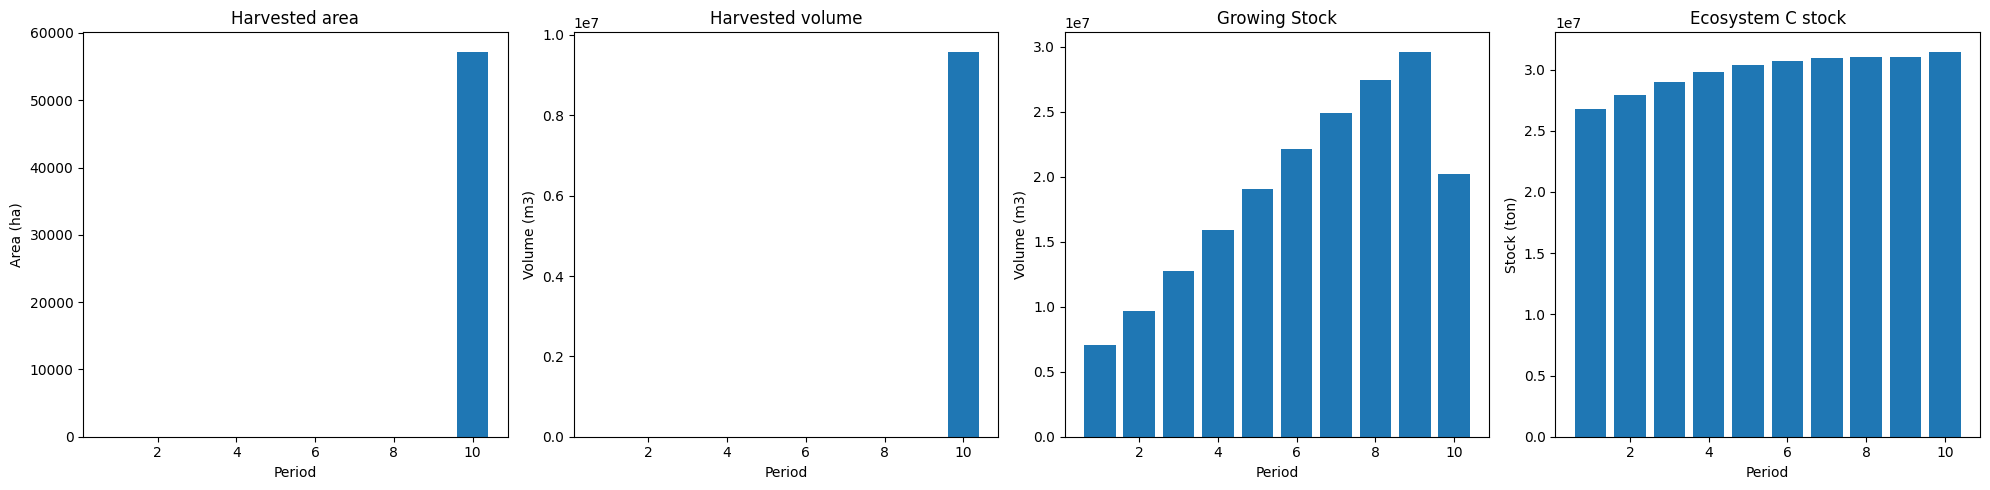

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_no_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  10134
The economic indicator (the provincial government revenues) is:  345617
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


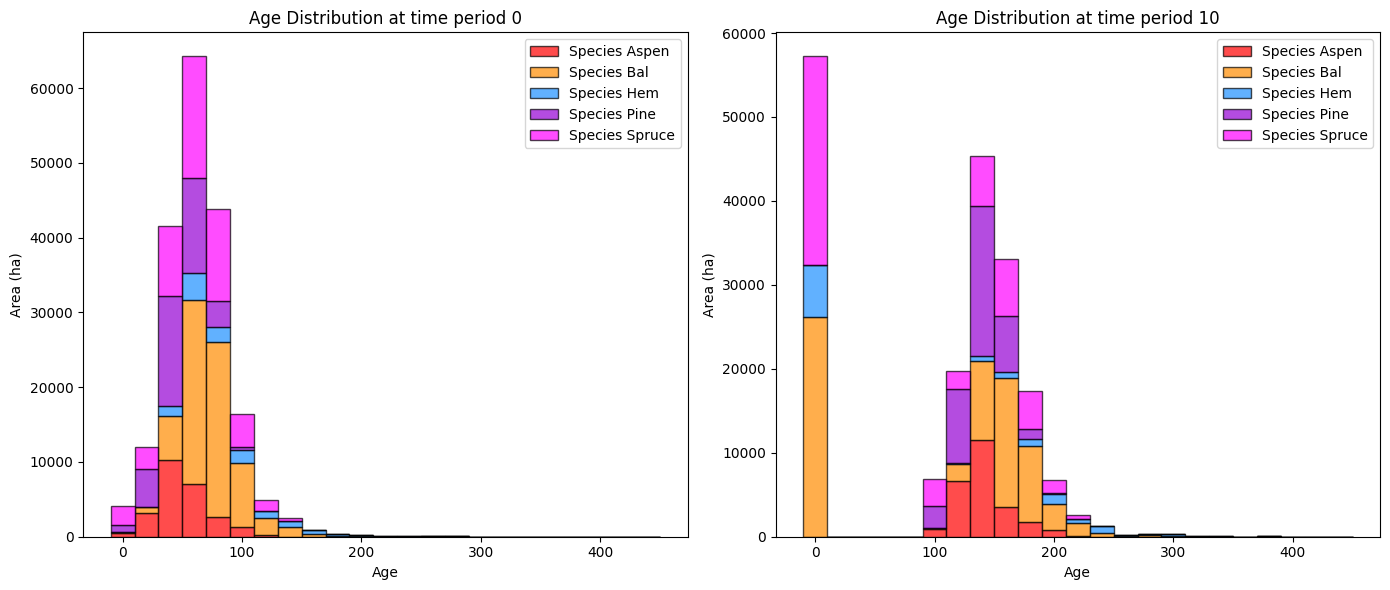

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_no_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   4723.751363   4721.042829
Bal     278.565372  10794.009800  10515.444428
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   2798.685352   2378.986021

Overall diversity has **increased** by 38165.49 hectares from time period 0 to time period 10.


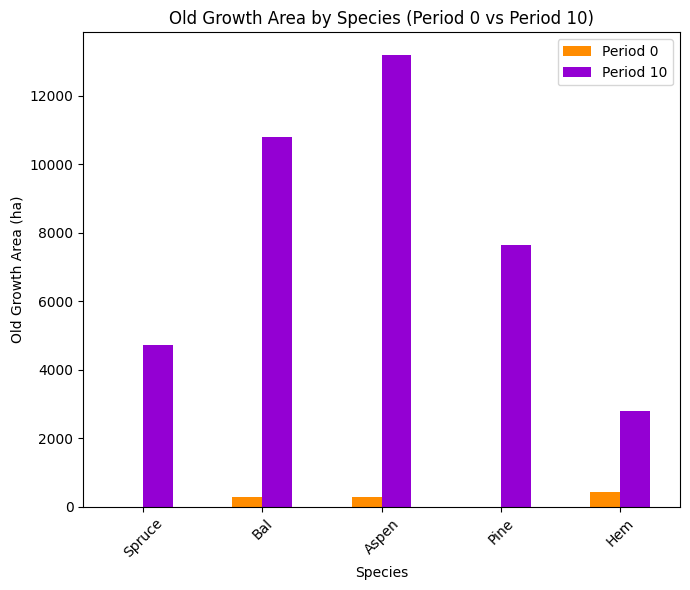

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_no_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9237

Diversity has **decreased** by 2.18% from time 0 to time 10.


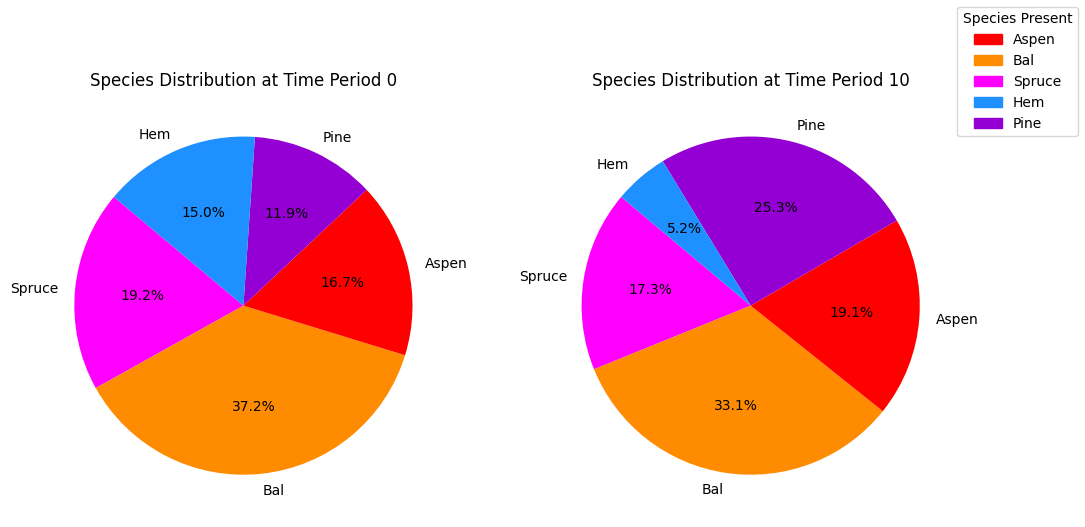

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_no_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.23s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.00

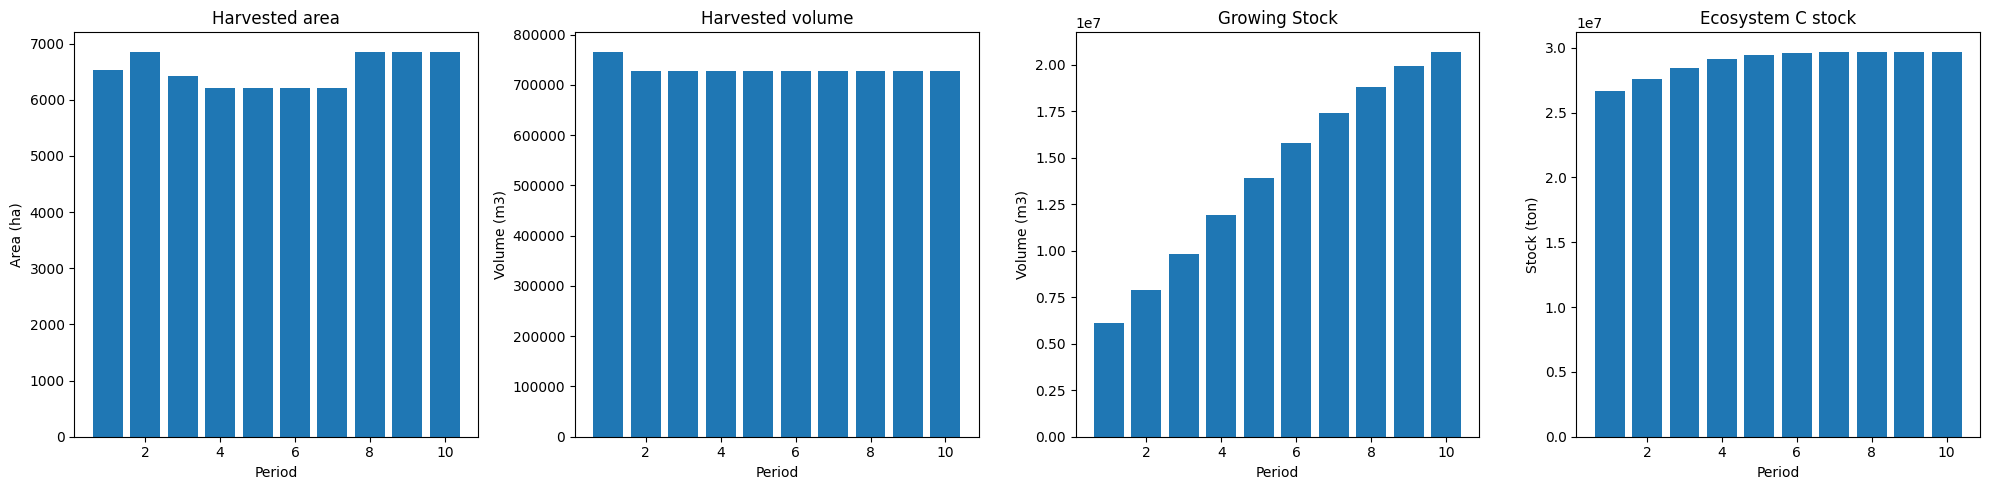

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


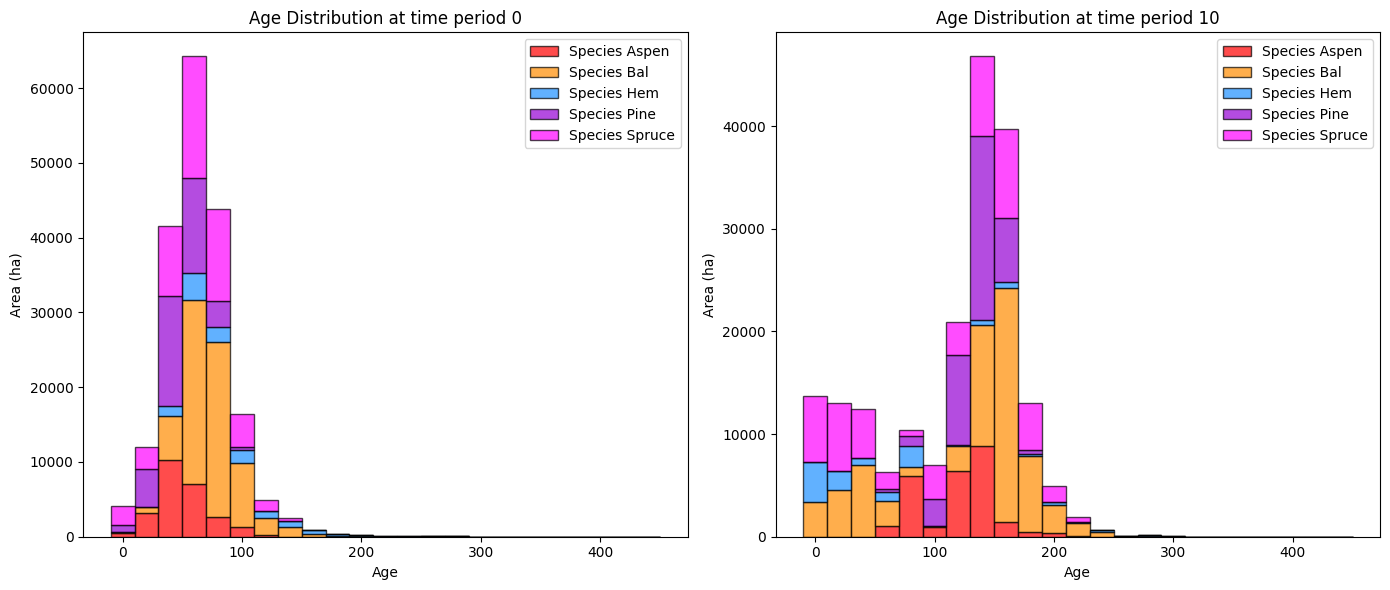

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


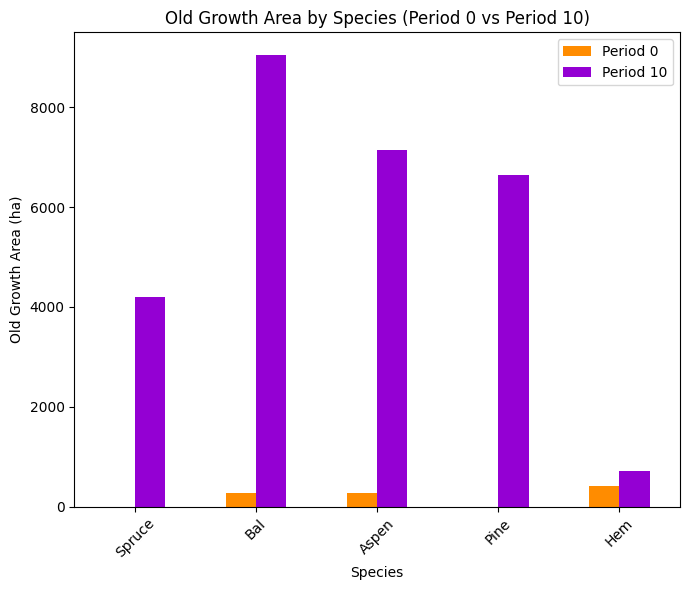

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


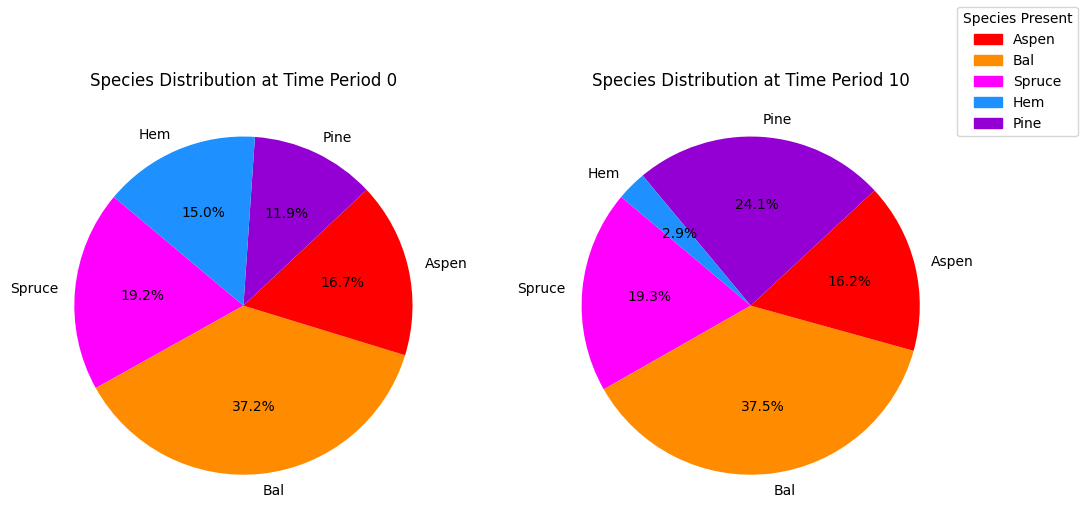

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


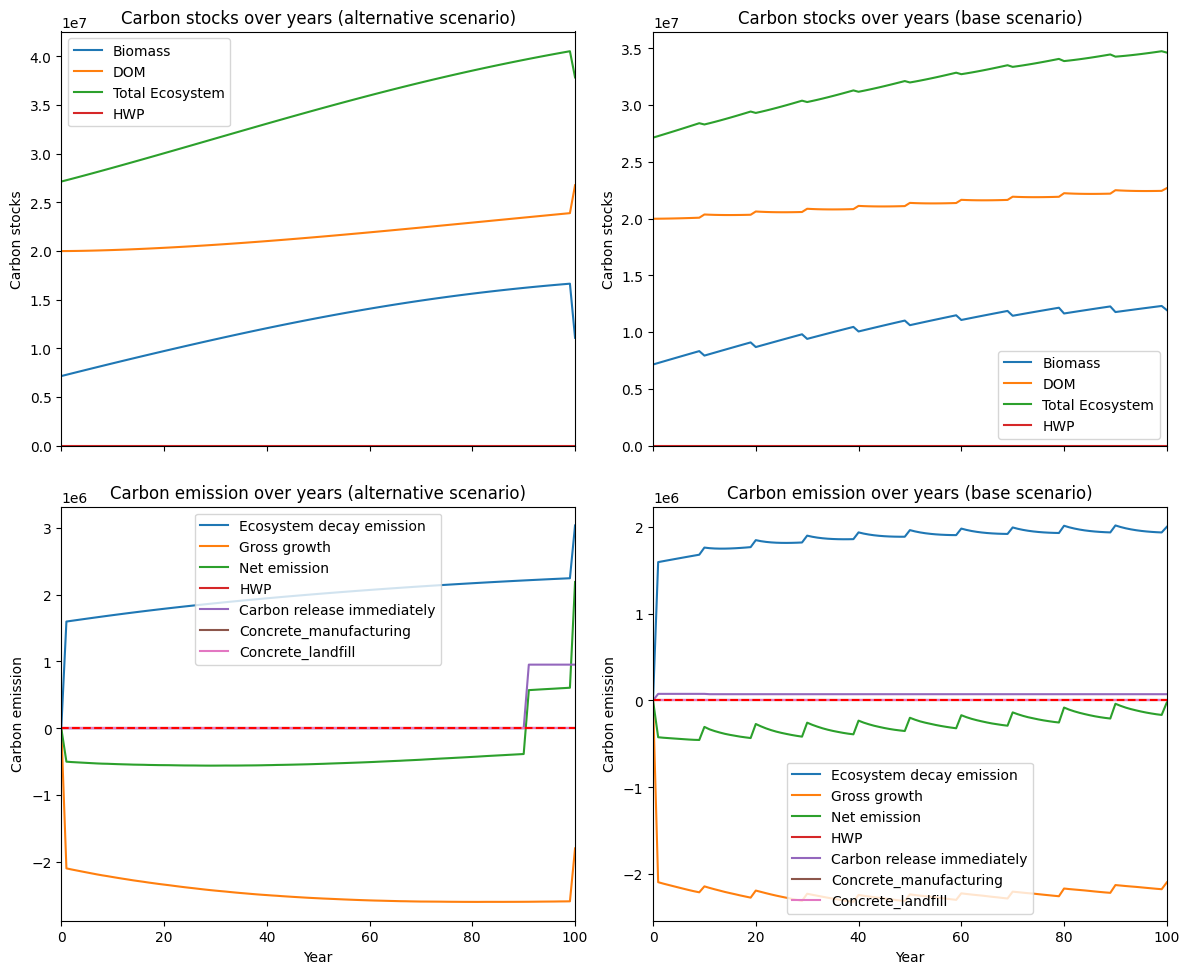

---------------------------------------------------------------------------------------
Net emission difference -3475475.5319963032
Net emission base scenario -12873402.697854219
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  2.877304100672528
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   530.667542   530.667542
Bal     0.0  1748.061829  1748.061829
Aspen   0.0  6040.508011  6040.508011
Pine    0.0   981.431263   981.431263
Hem     0.0  2087.781939  2087.781939

Overall, the old growth area has **increased** by 11388.45 hectares in the alternative scenario compared to the base scenario.


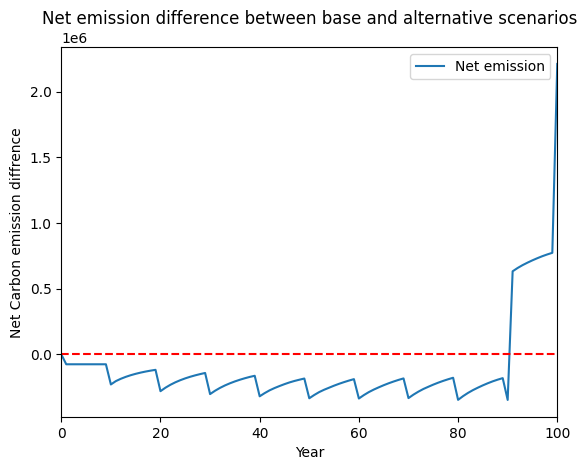

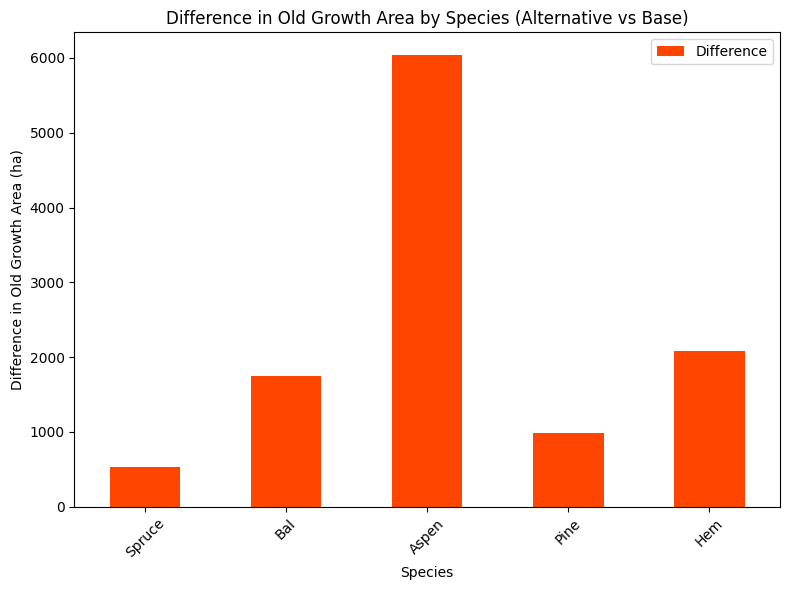

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


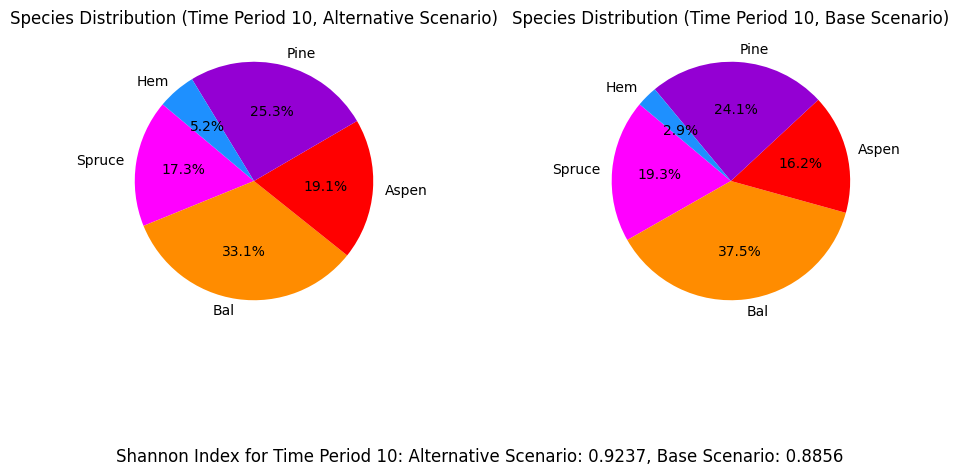

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_evenflow_cons...
running even flow constraints scenario
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3945 rows, 36130 columns and 430076 nonzeros
Model fingerprint: 0x7be4f36b
Coefficient statistics:
  Matrix range     [1e-02, 9e+04]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 1e+00]
Presolve removed 2035 rows and 2031 columns
Presolve time: 0.12s
Presolved: 1910 rows, 34099 columns, 402875 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering ti

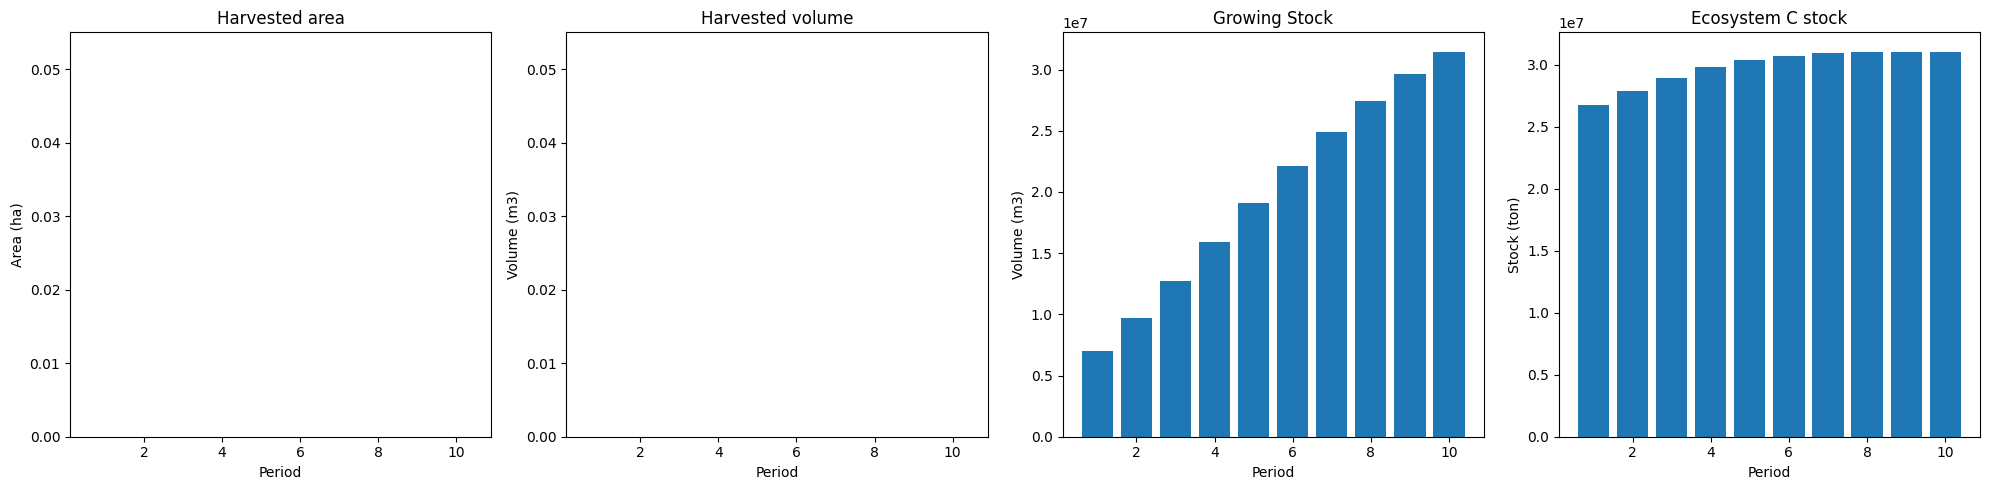

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_evenflow_cons_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  0
The economic indicator (the provincial government revenues) is:  0
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


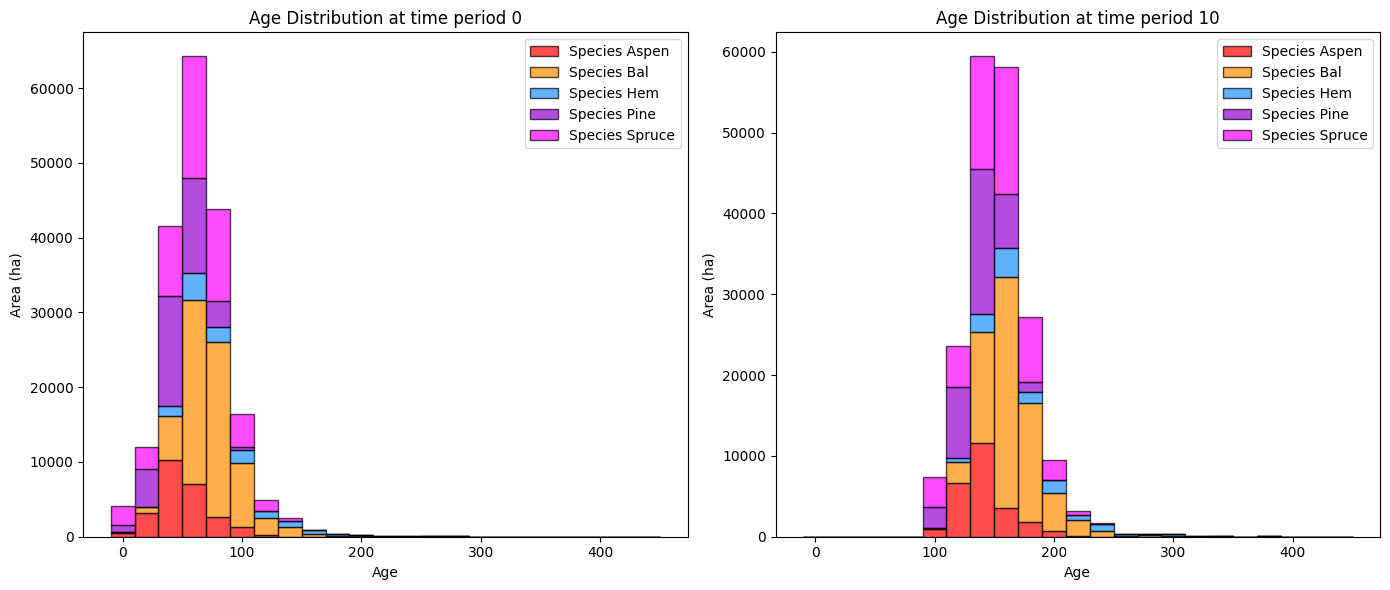

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_evenflow_cons_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   8040.264040   8037.555506
Bal     278.565372  15963.007735  15684.442363
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   3929.593538   3509.894208

Overall diversity has **increased** by 47781.91 hectares from time period 0 to time period 10.


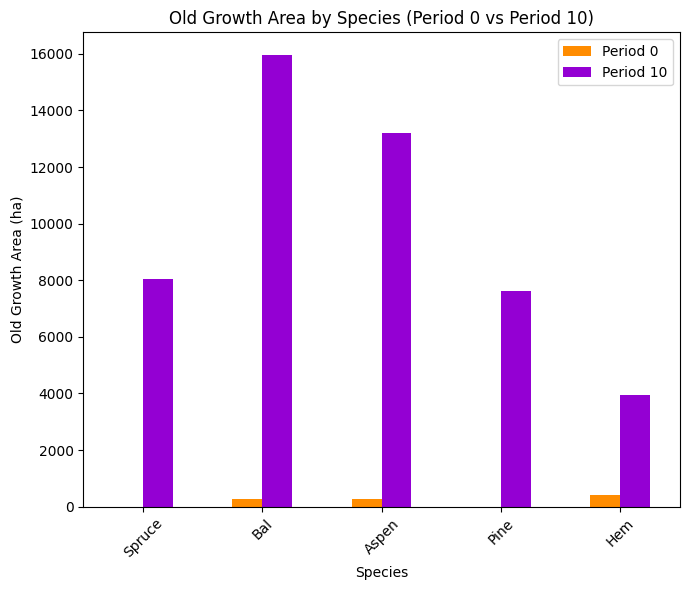

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_evenflow_cons_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9285

Diversity has **decreased** by 1.71% from time 0 to time 10.


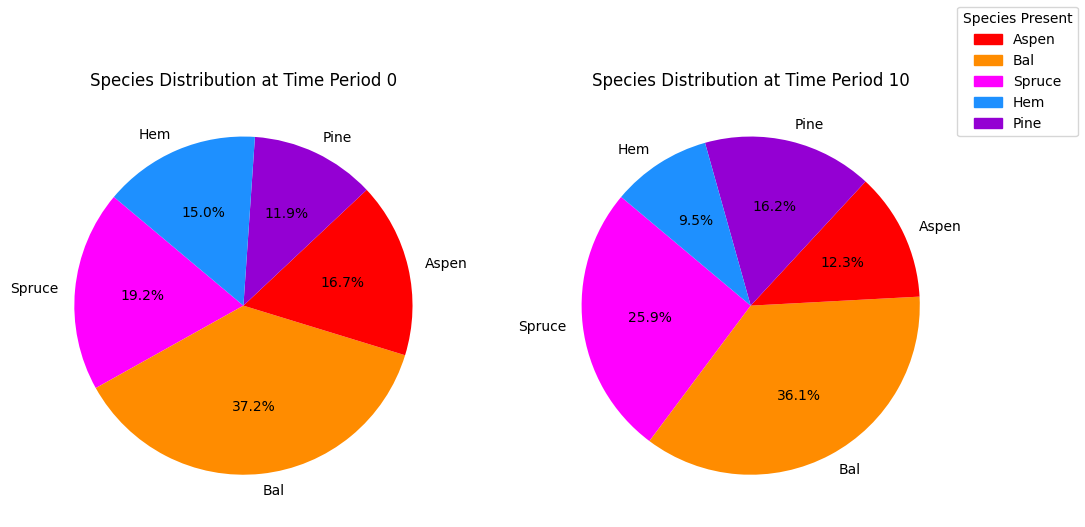

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_evenflow_cons_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

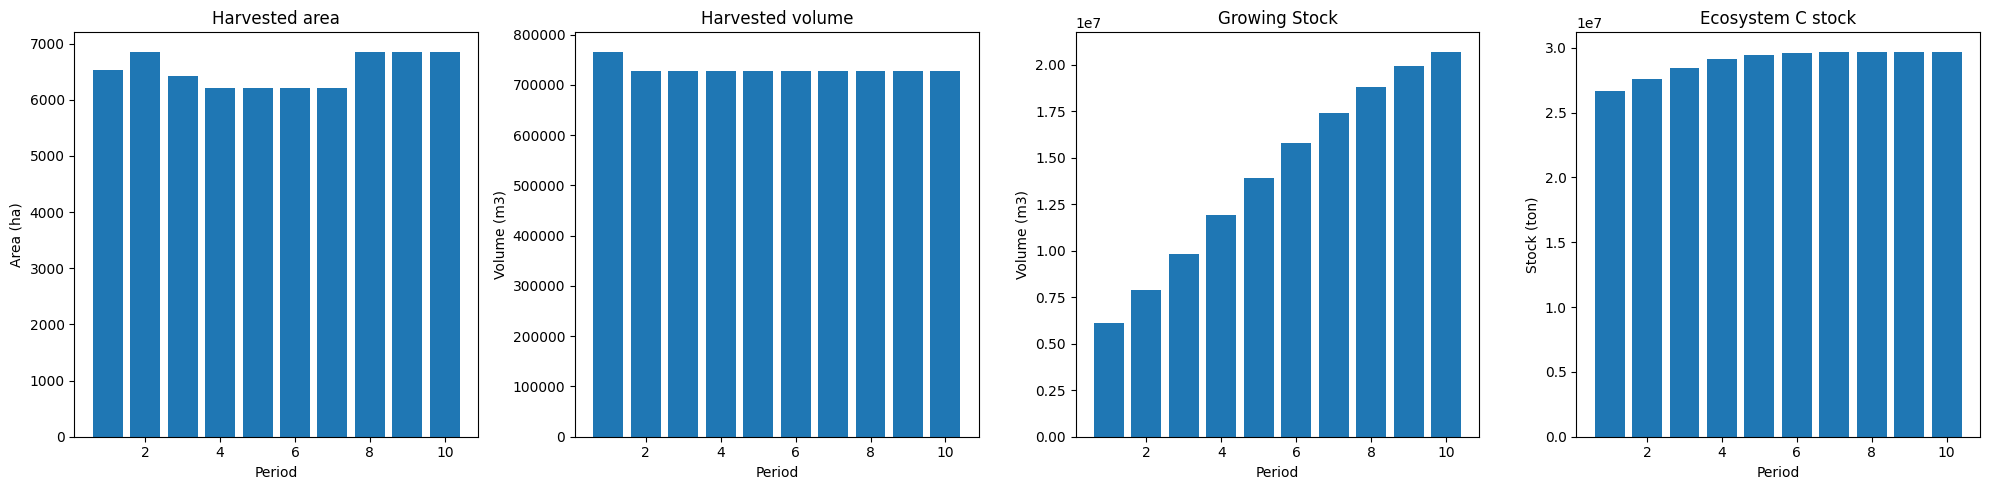

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


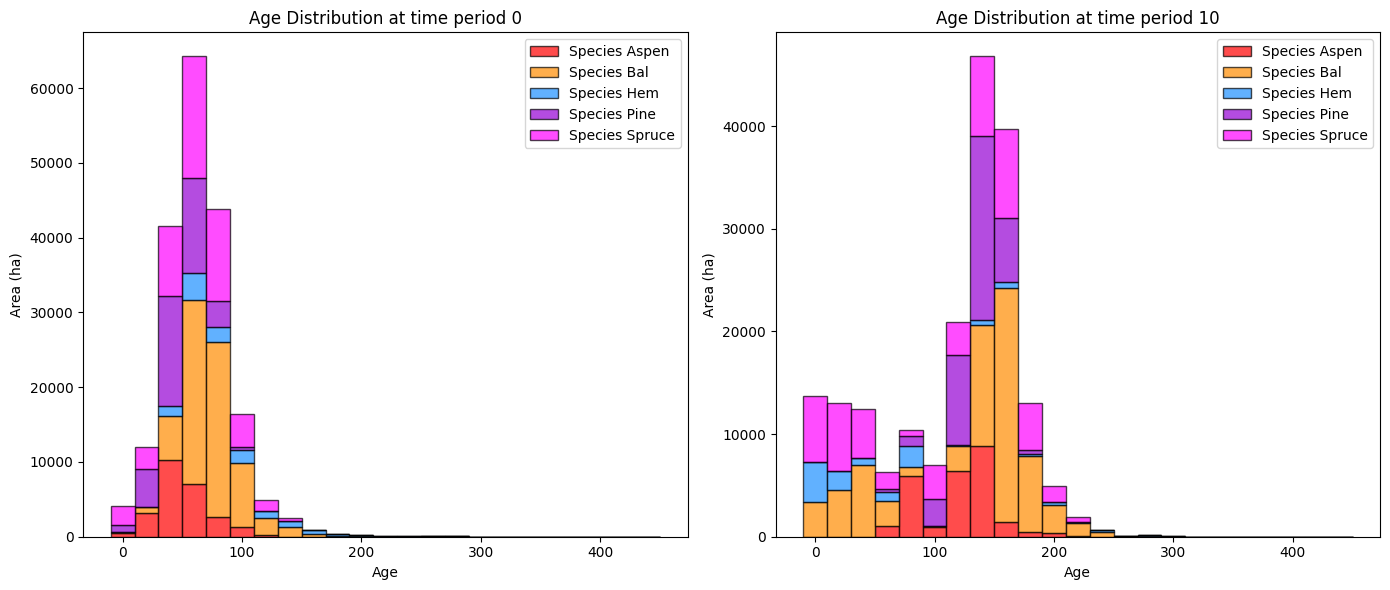

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


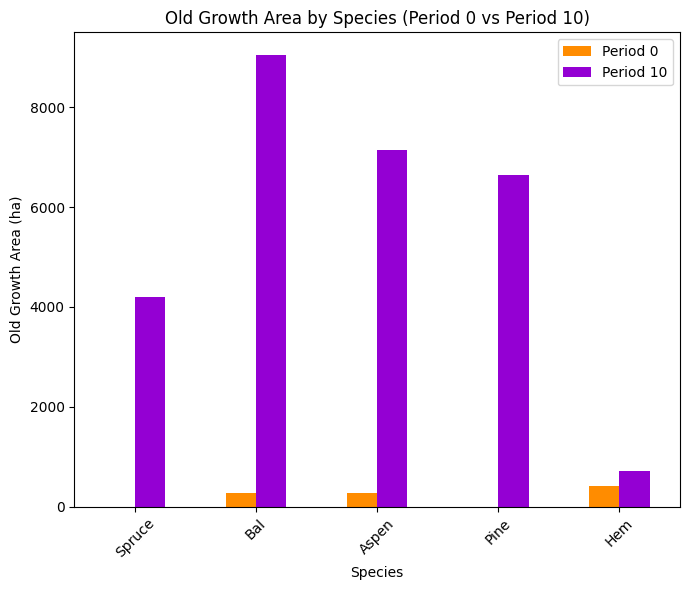

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


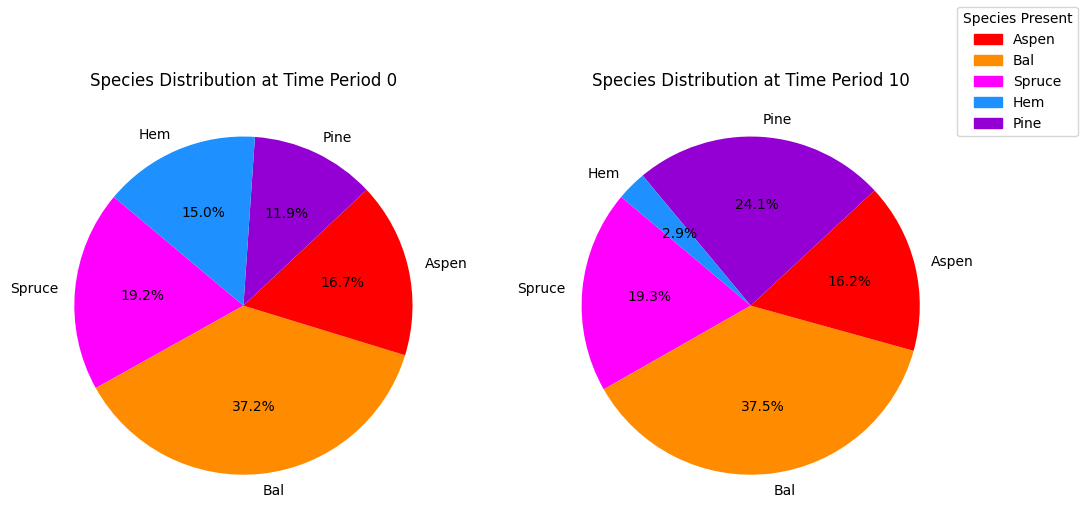

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


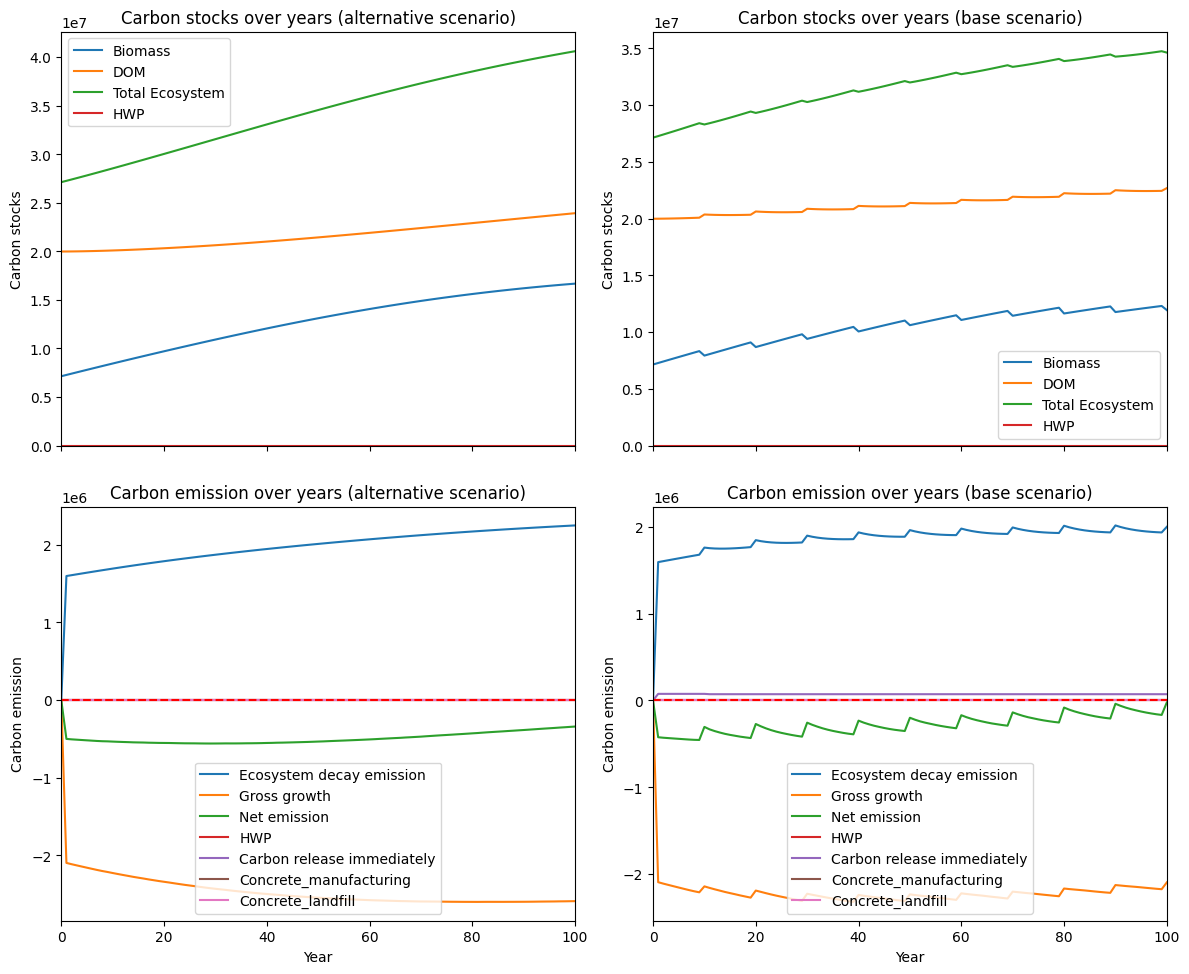

---------------------------------------------------------------------------------------
Net emission difference -3475475.5319963032
Net emission base scenario -12873402.697854219
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  2.877304100672528
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3847.180219  3847.180219
Bal     0.0  6917.059764  6917.059764
Aspen   0.0  6040.508011  6040.508011
Pine    0.0   981.431263   981.431263
Hem     0.0  3218.690125  3218.690125

Overall, the old growth area has **increased** by 21004.87 hectares in the alternative scenario compared to the base scenario.


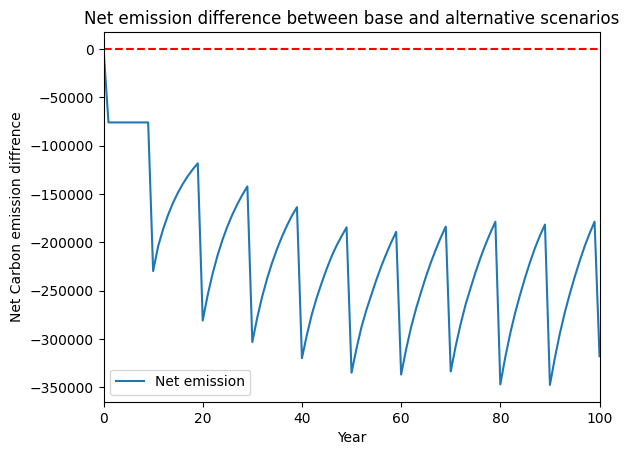

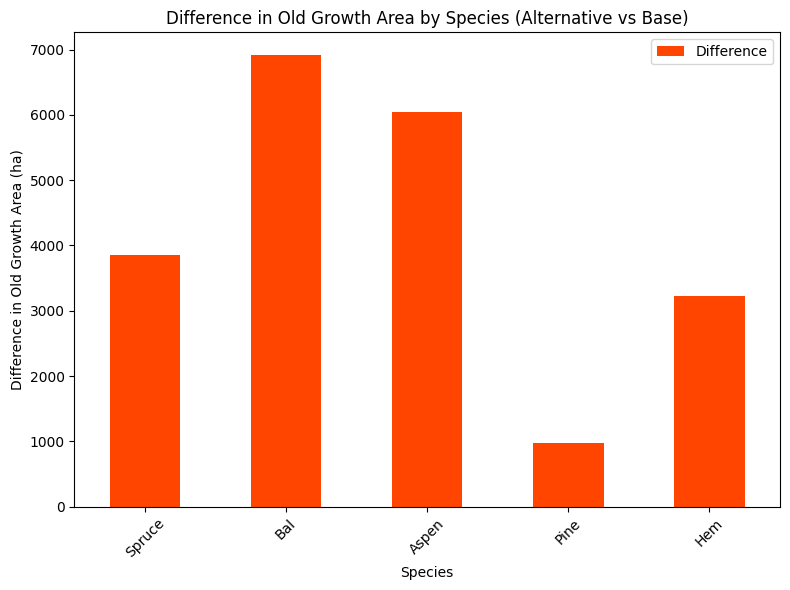

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


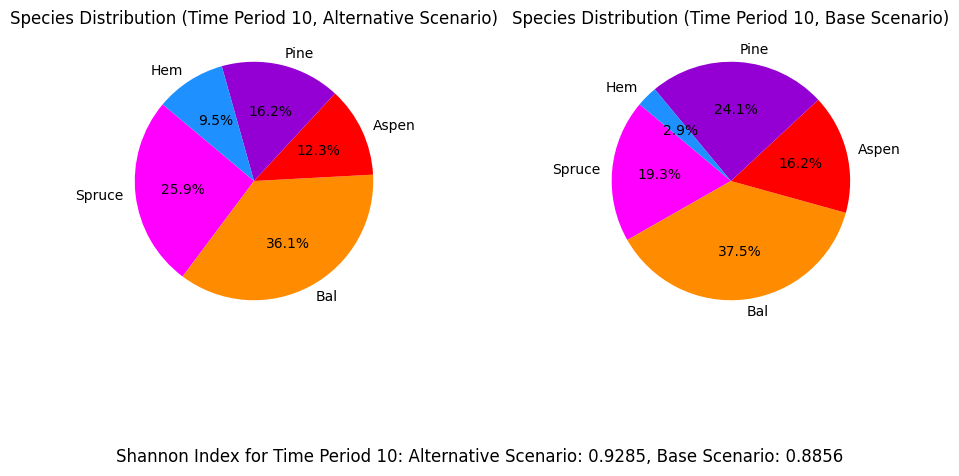

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_bau_gldbr...
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.20s
Presolved: 1911 rows, 34099 col

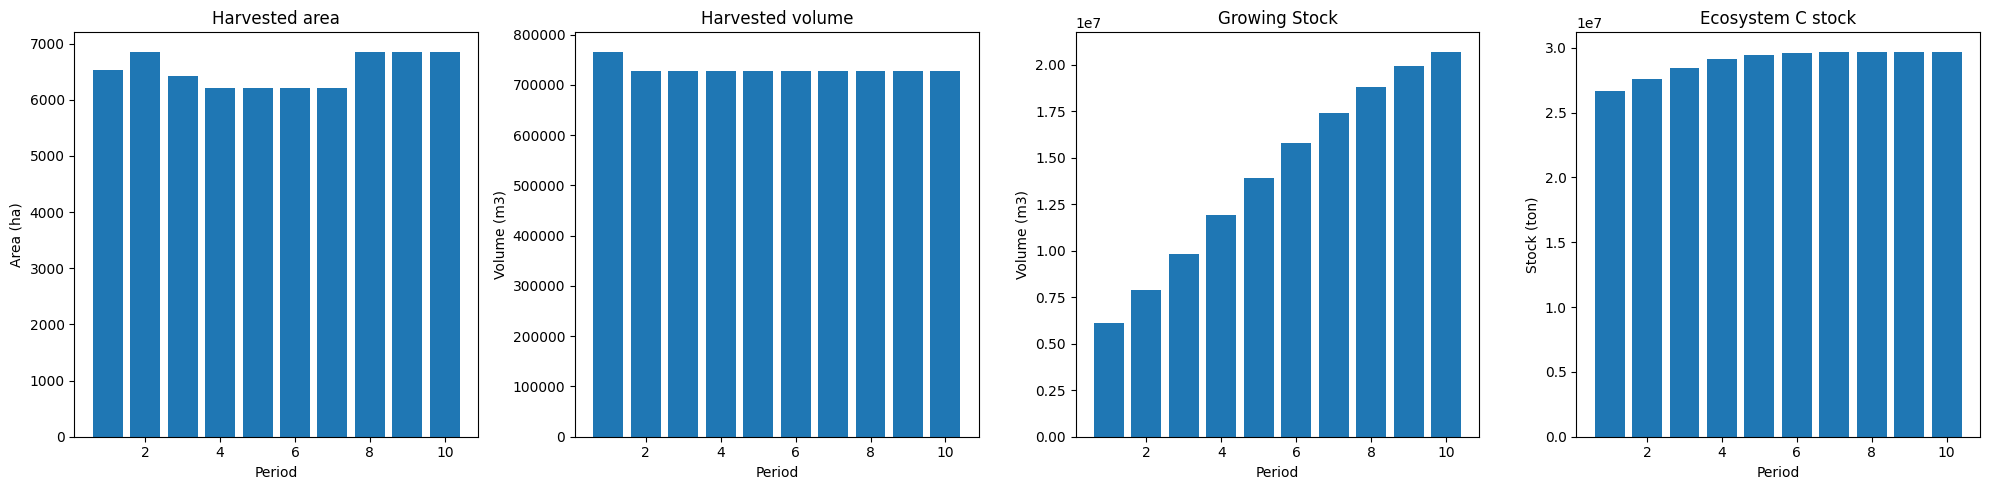

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


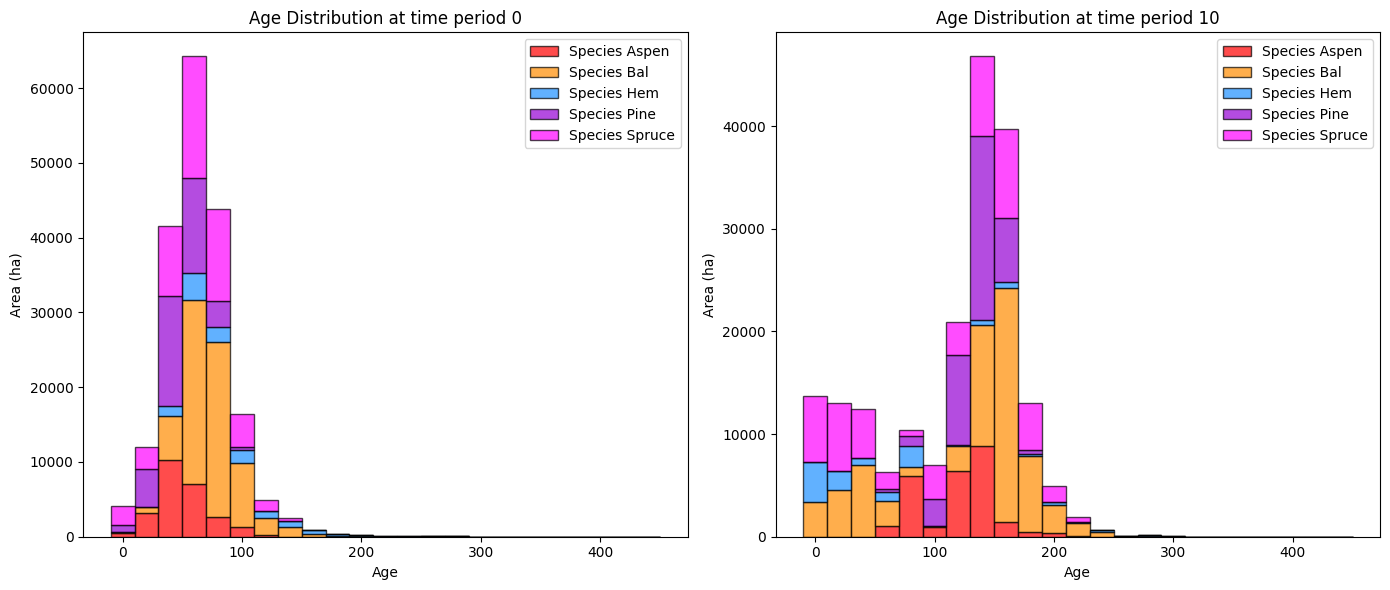

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


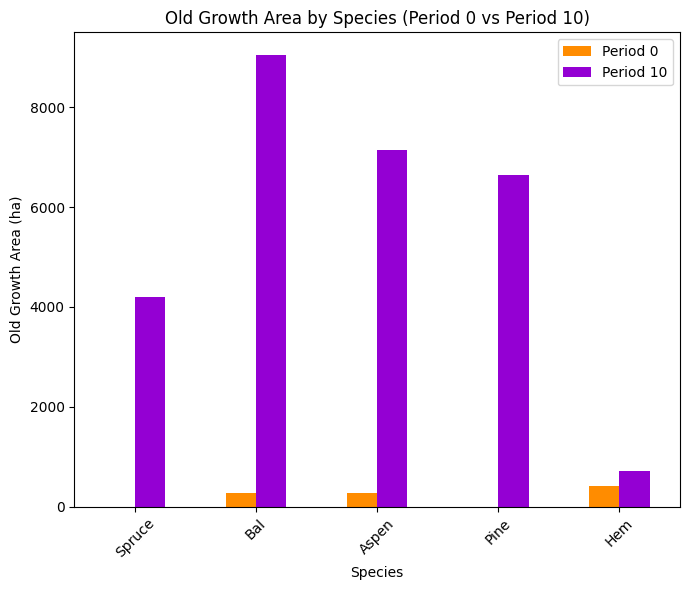

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


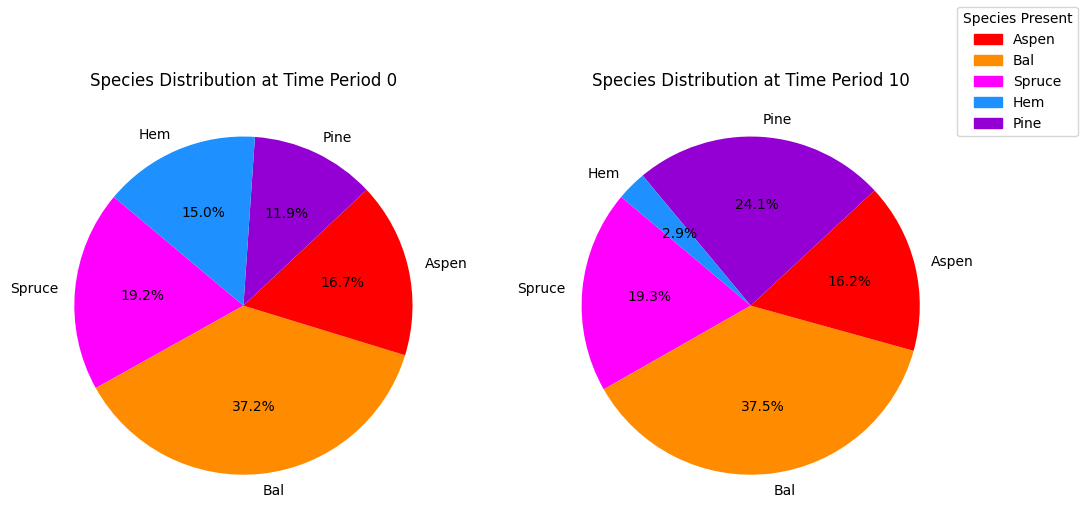

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.16s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.

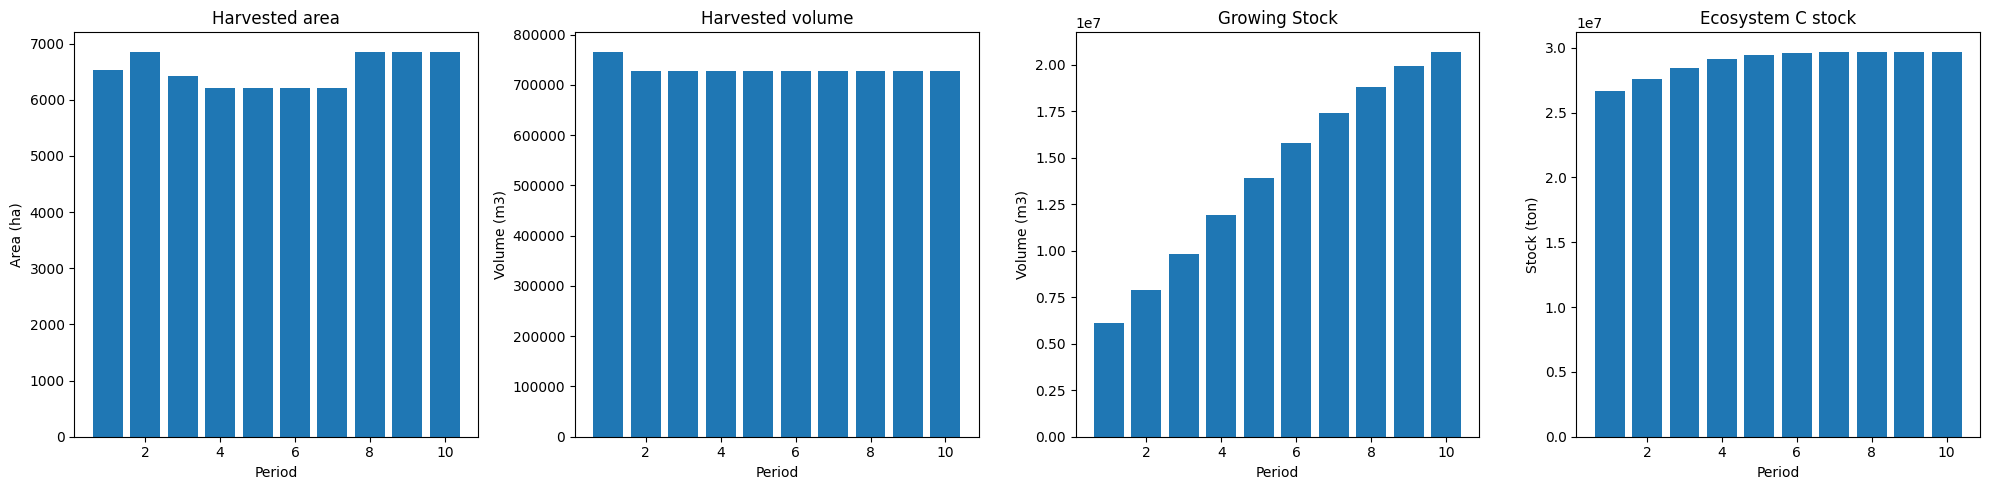

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


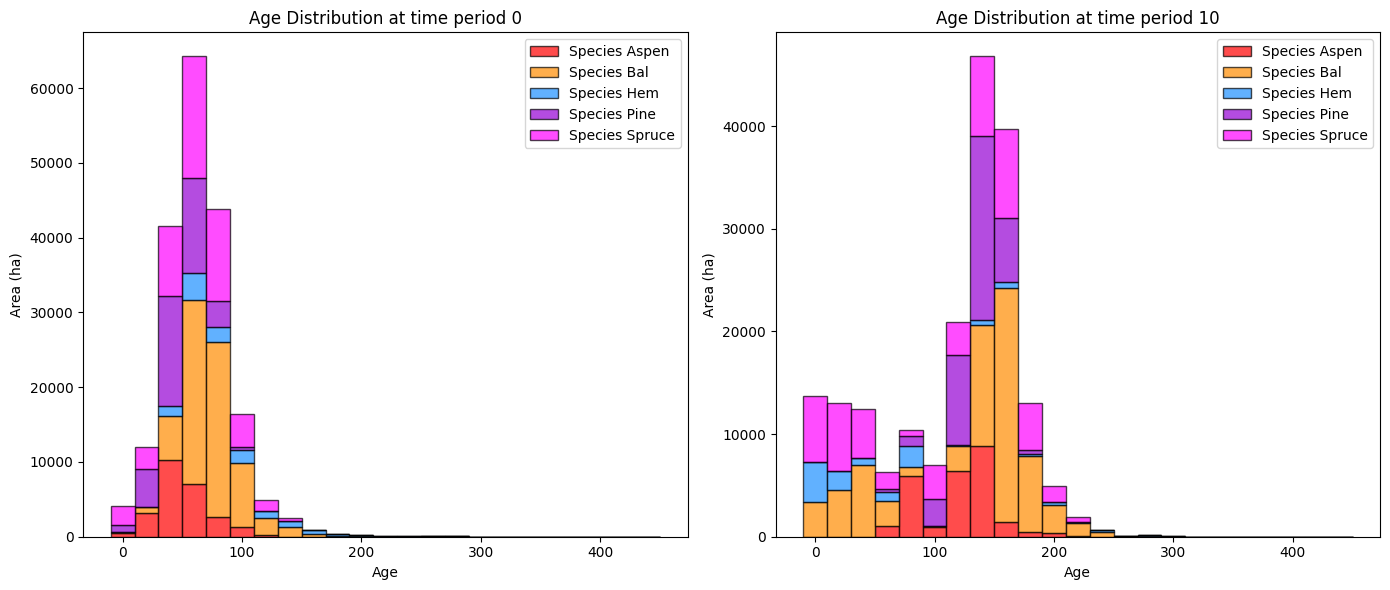

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


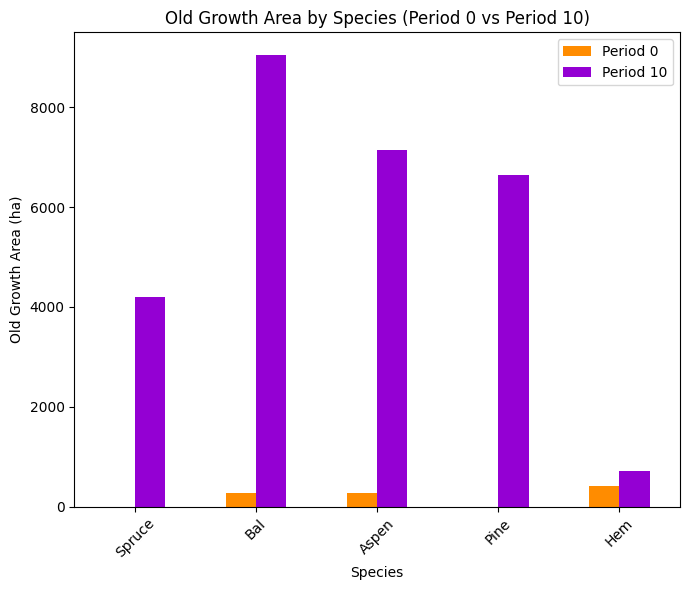

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


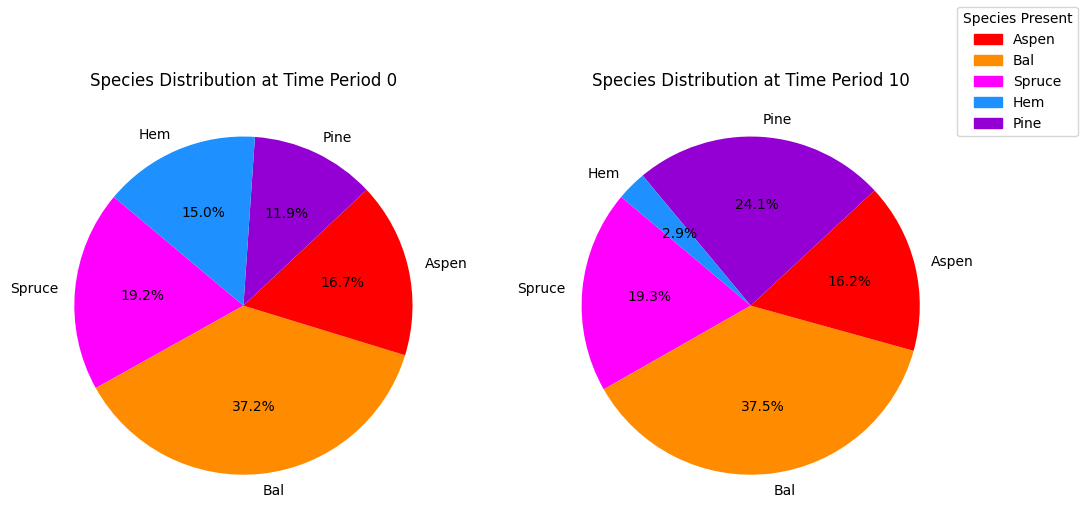

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


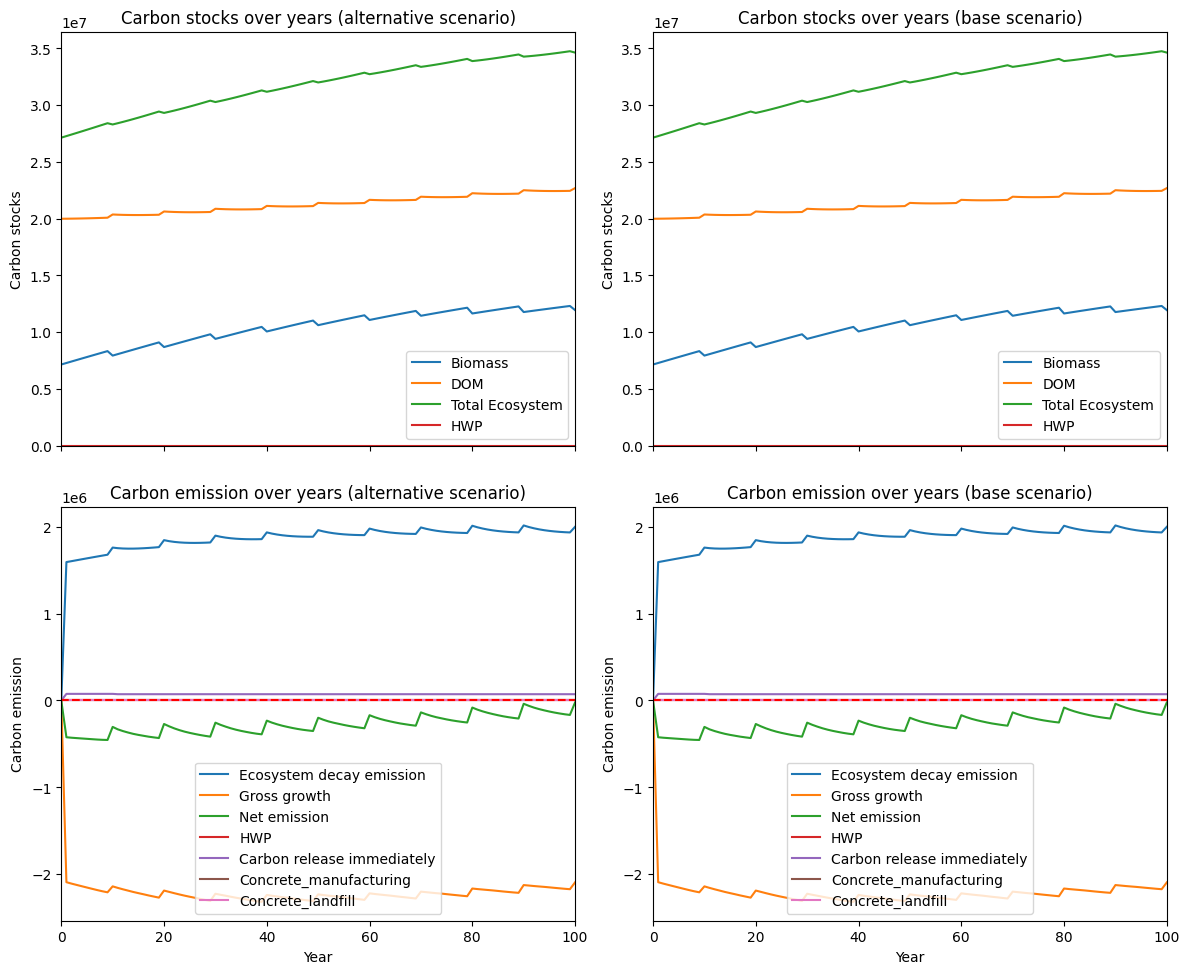

---------------------------------------------------------------------------------------
Net emission difference 0.0
Net emission base scenario -9397927.165857917
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  inf
Comparison of Old Growth Areas (Alternative - Base)
          0   10  Difference
Spruce  0.0  0.0         0.0
Bal     0.0  0.0         0.0
Aspen   0.0  0.0         0.0
Pine    0.0  0.0         0.0
Hem     0.0  0.0         0.0

Overall, the old growth area has **increased** by 0.00 hectares in the alternative scenario compared to the base scenario.


/media/data/project/eghasemi/nbds_mining/util_opt.py:1211: RuntimeWarning: divide by zero encountered in scalar divide
  dollar_per_ton = abs(budget_input / dif_scenario.iloc[:25]['Net emission'].sum())


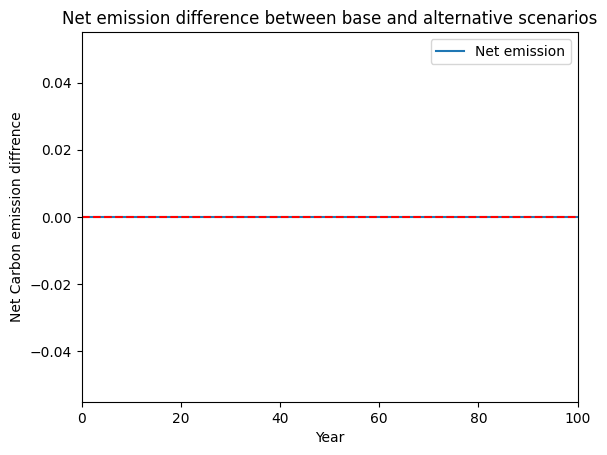

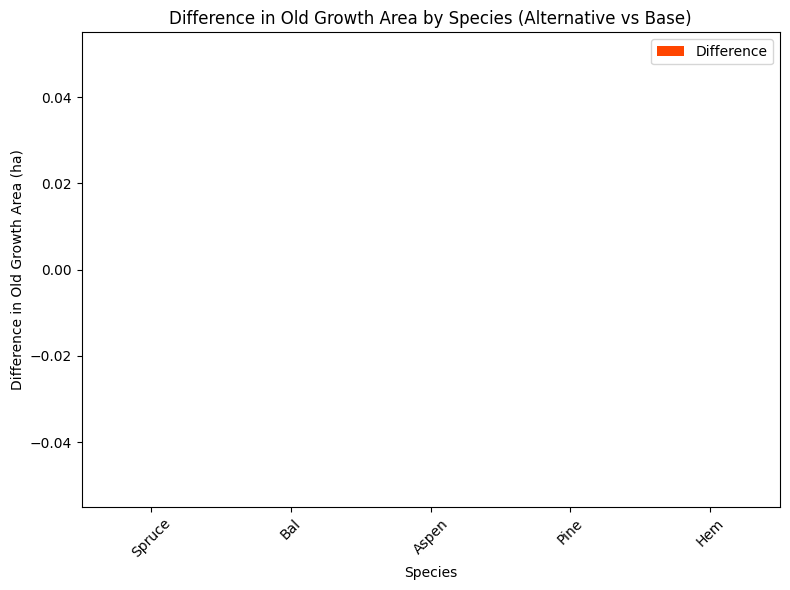

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


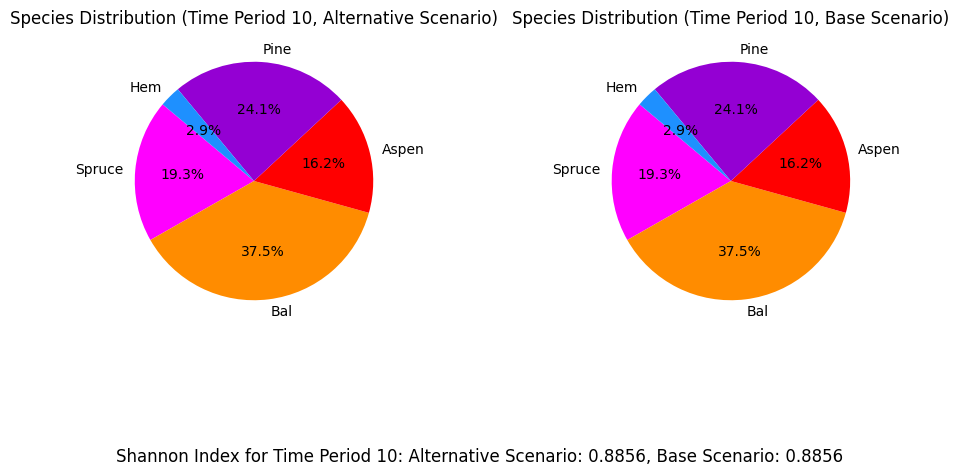

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_90%...
running the scenario for the Golden Bear mining site (90%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xdacbb76b
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.16s
Presolved: 1911 rows, 34100 

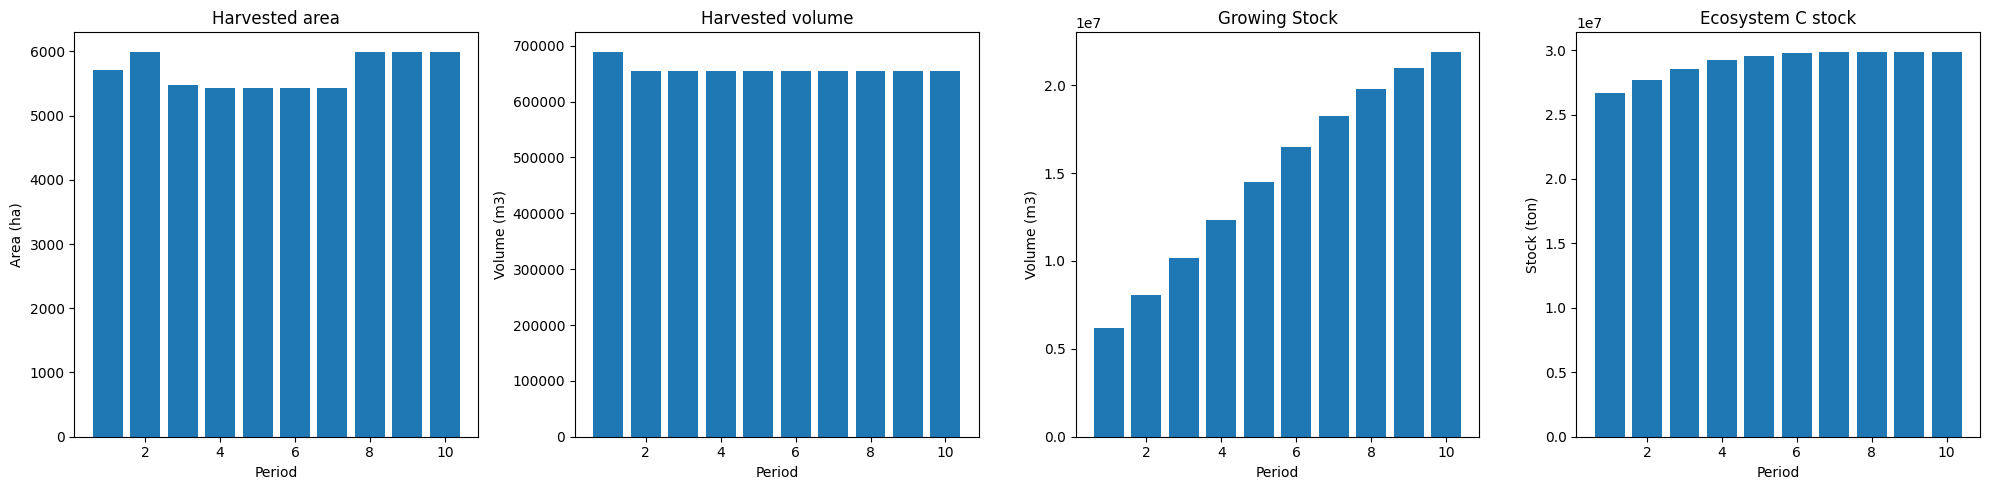

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_90%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6961
The economic indicator (the provincial government revenues) is:  237385
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


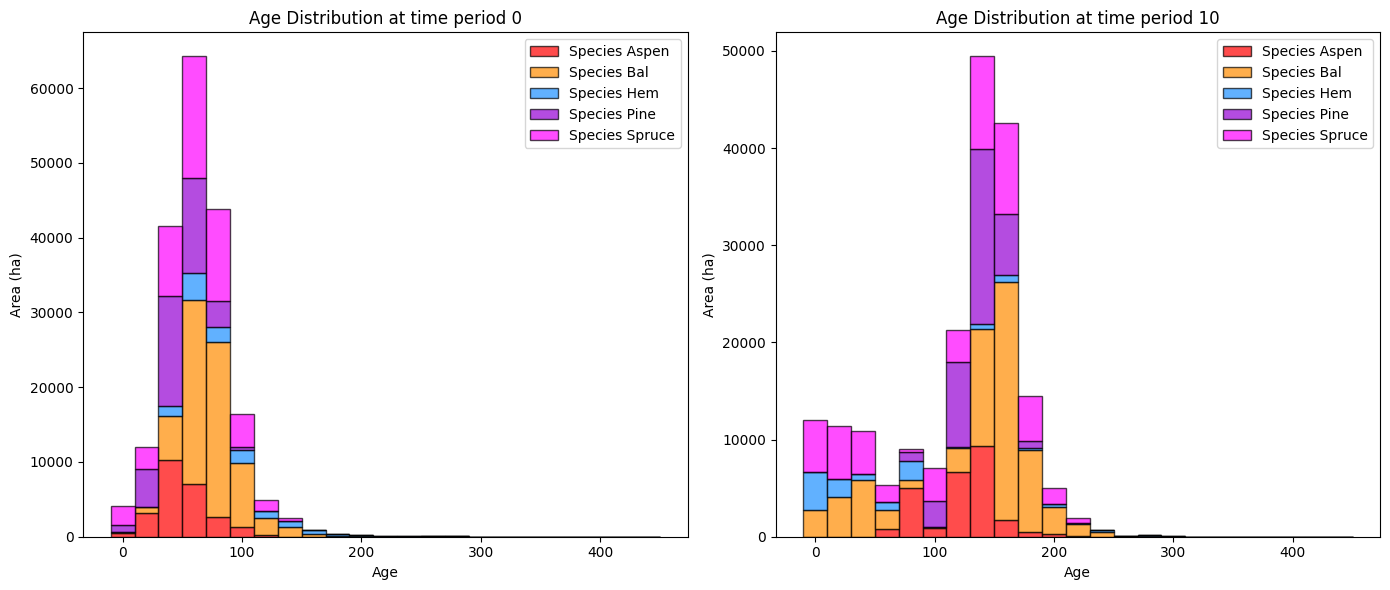

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_90%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4539.410166  4536.701632
Bal     278.565372  9830.942711  9552.377339
Aspen   273.490478  7911.613185  7638.122707
Pine      0.000000  6902.802138  6902.802138
Hem     419.699331   731.925091   312.225760

Overall diversity has **increased** by 28942.23 hectares from time period 0 to time period 10.


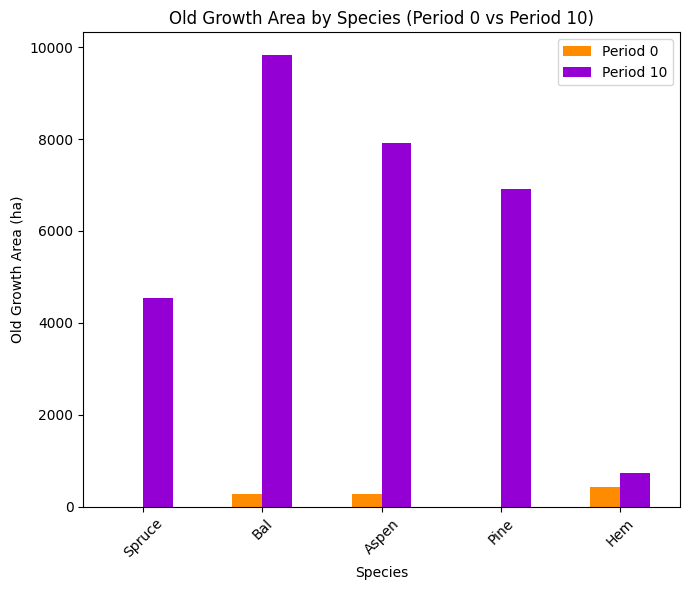

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_90%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8840

Diversity has **decreased** by 6.16% from time 0 to time 10.


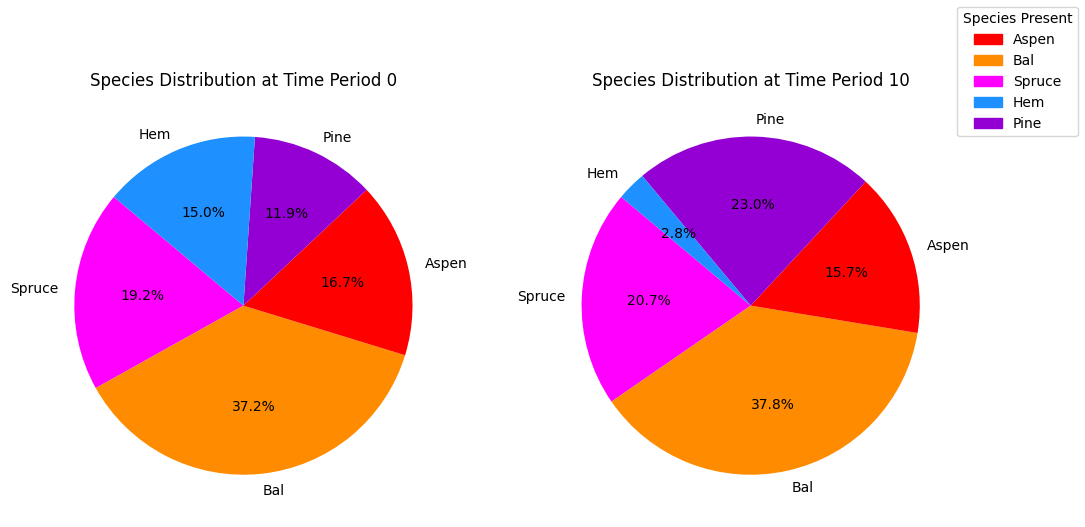

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_90%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.24s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

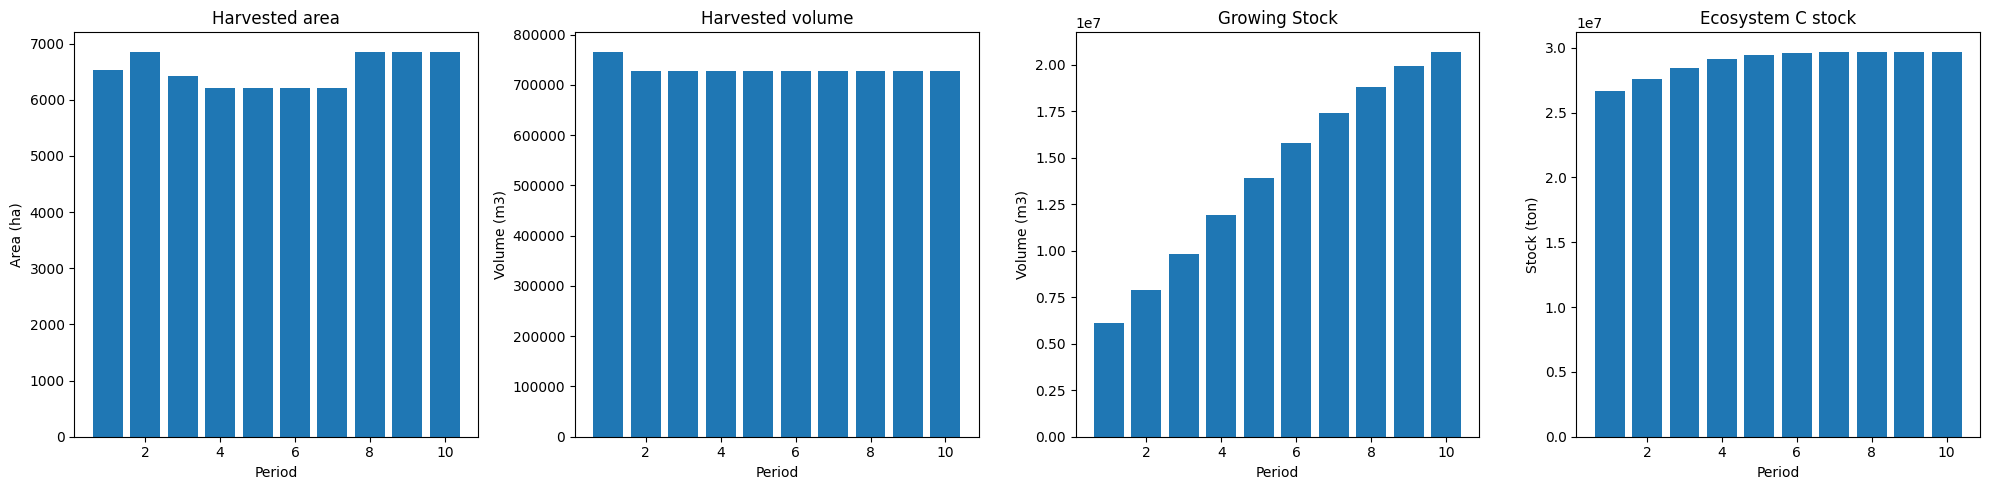

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


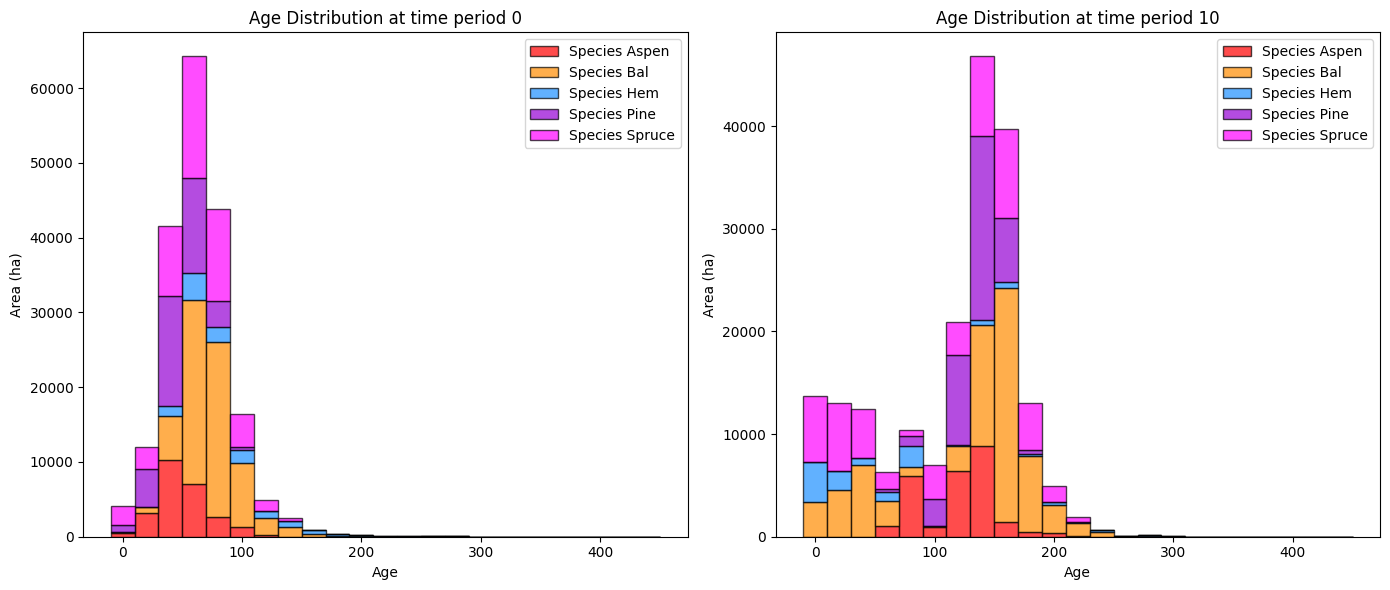

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


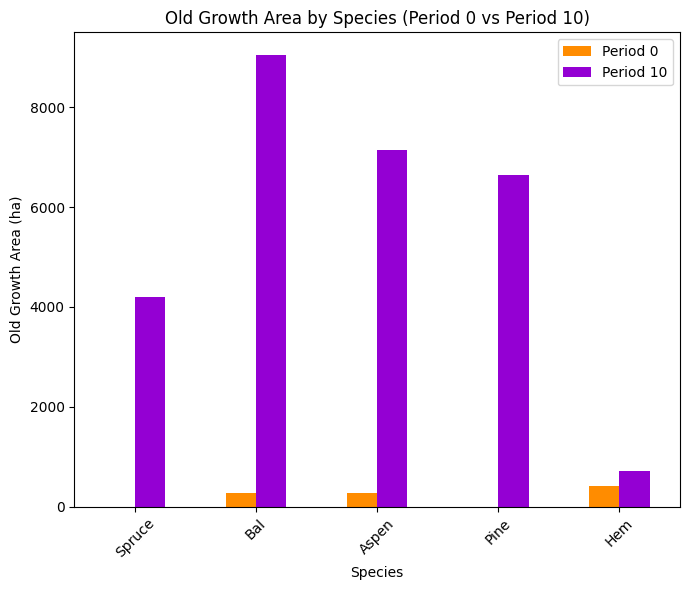

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


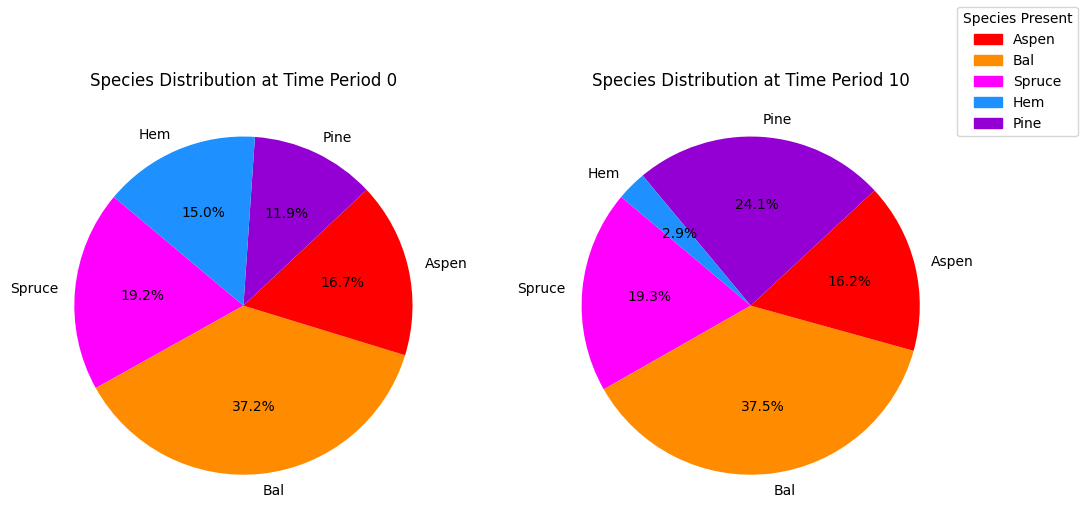

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


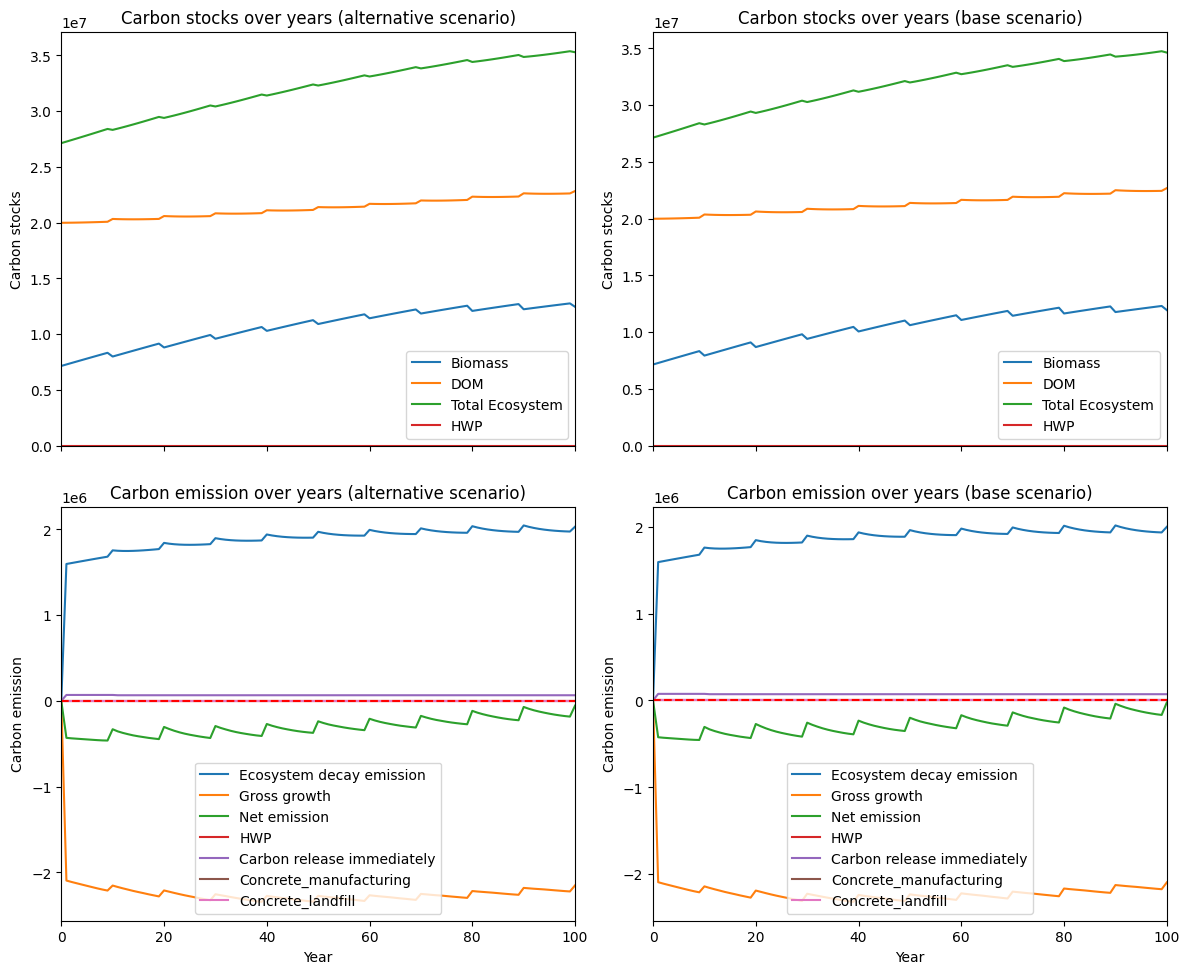

---------------------------------------------------------------------------------------
Net emission difference -389560.0245813974
Net emission base scenario -9787487.190439314
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  25.66998503182025
Comparison of Old Growth Areas (Alternative - Base)
          0          10  Difference
Spruce  0.0  346.326345  346.326345
Bal     0.0  784.994740  784.994740
Aspen   0.0  760.502923  760.502923
Pine    0.0  252.346200  252.346200
Hem     0.0   21.021677   21.021677

Overall, the old growth area has **increased** by 2165.19 hectares in the alternative scenario compared to the base scenario.


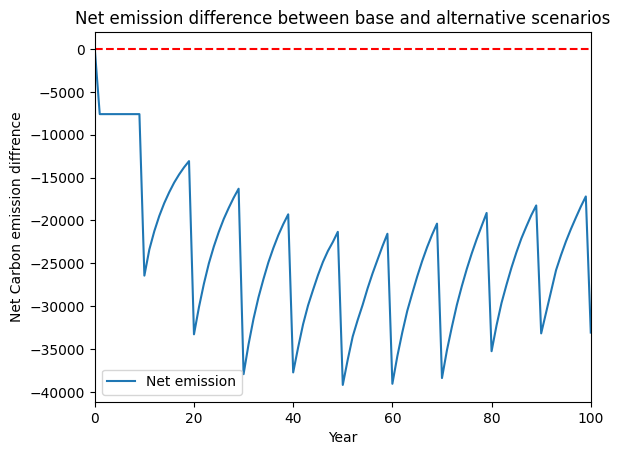

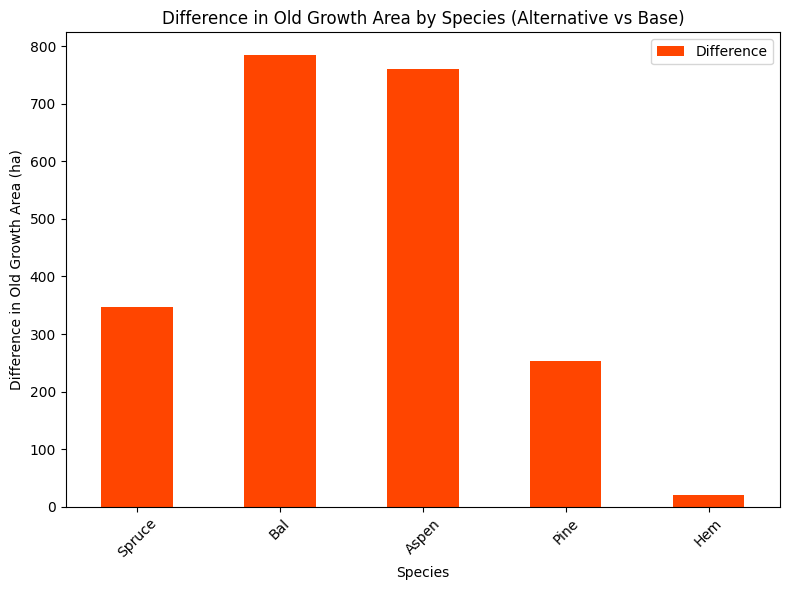

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


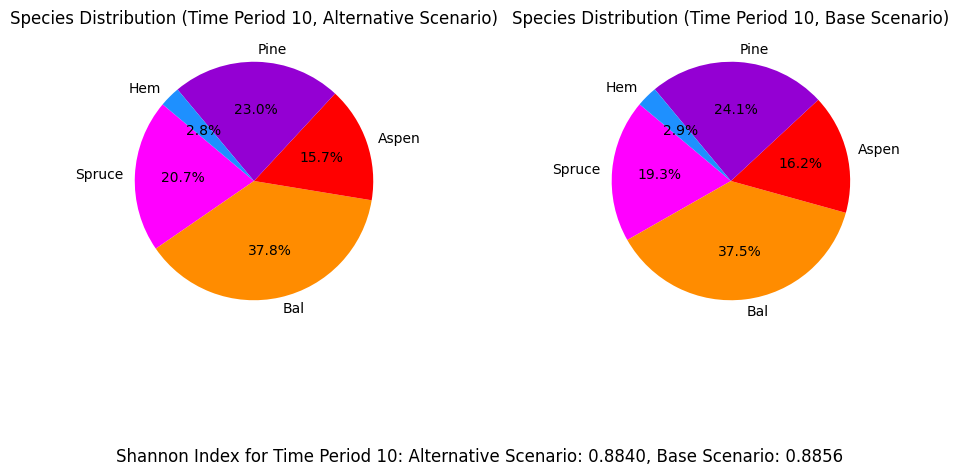

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_80%...
running the scenario for the Golden Bear mining site (80%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xde47b7a7
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.16s
Presolved: 1911 rows, 34100 

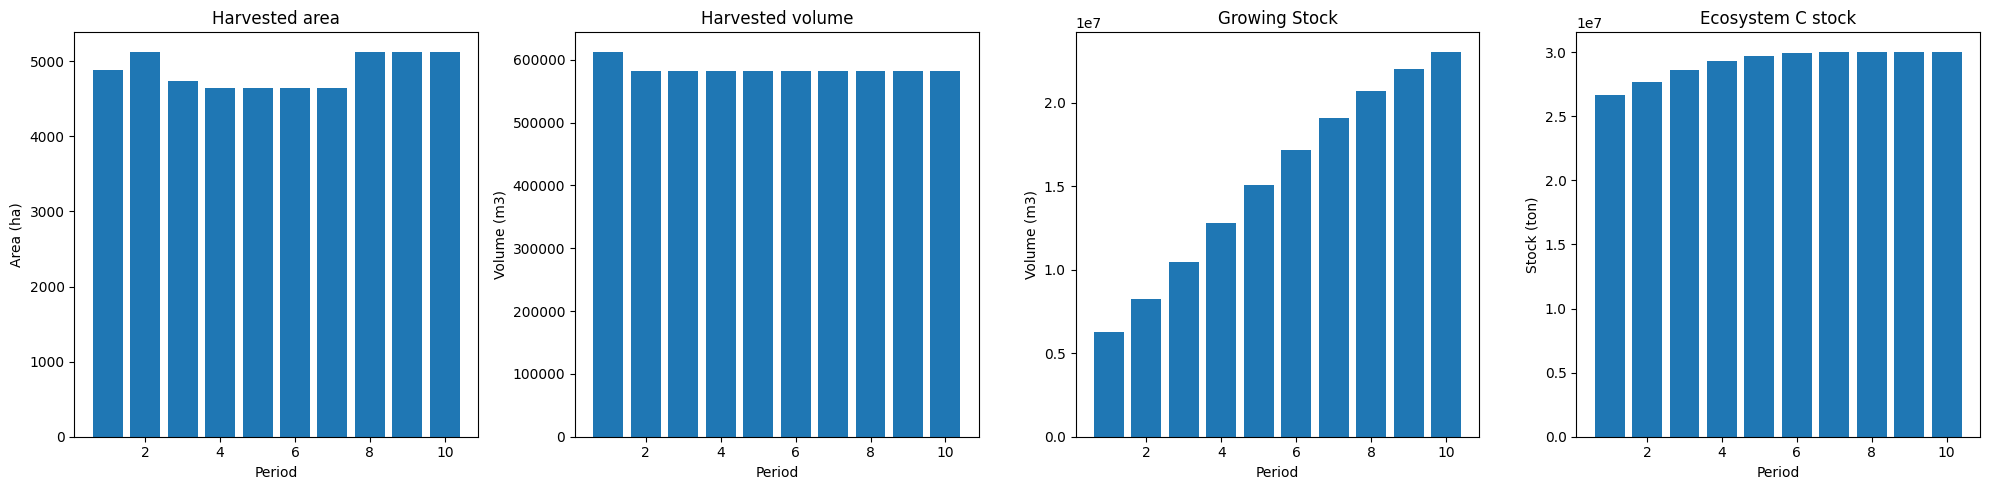

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_80%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  6187
The economic indicator (the provincial government revenues) is:  211009
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


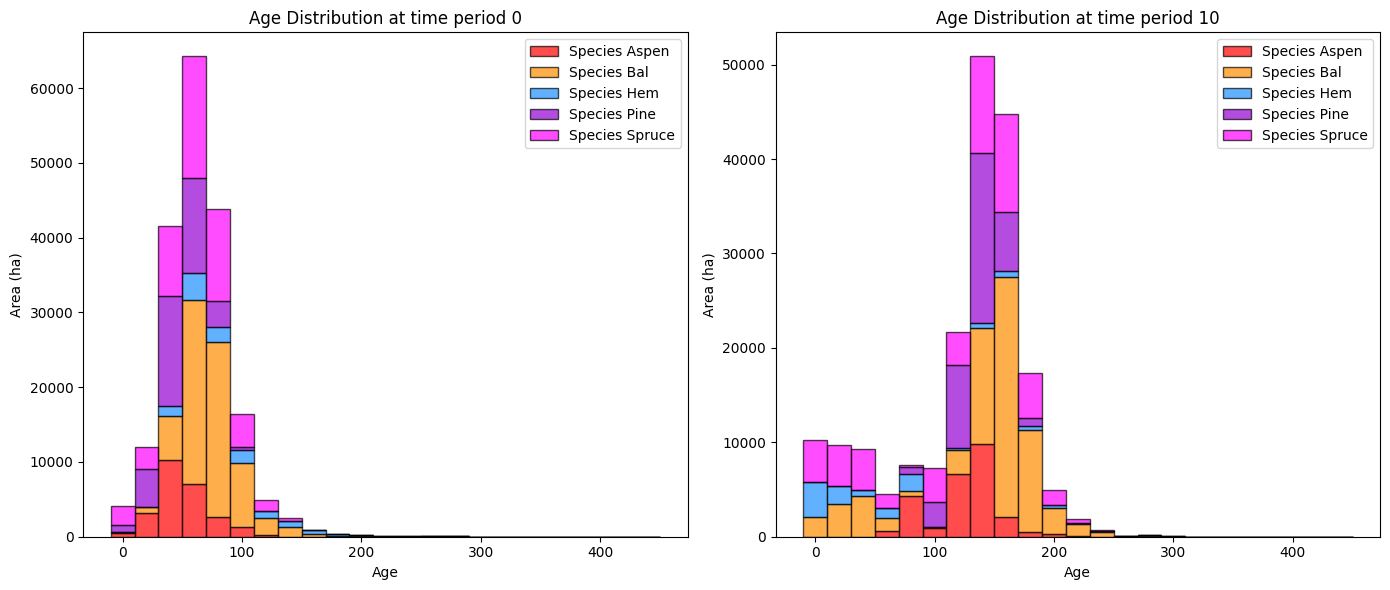

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_80%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   4792.069013   4789.360480
Bal     278.565372  10830.775920  10552.210548
Aspen   273.490478   8707.134876   8433.644398
Pine      0.000000   6997.377784   6997.377784
Hem     419.699331    759.720458    340.021127

Overall diversity has **increased** by 31112.61 hectares from time period 0 to time period 10.


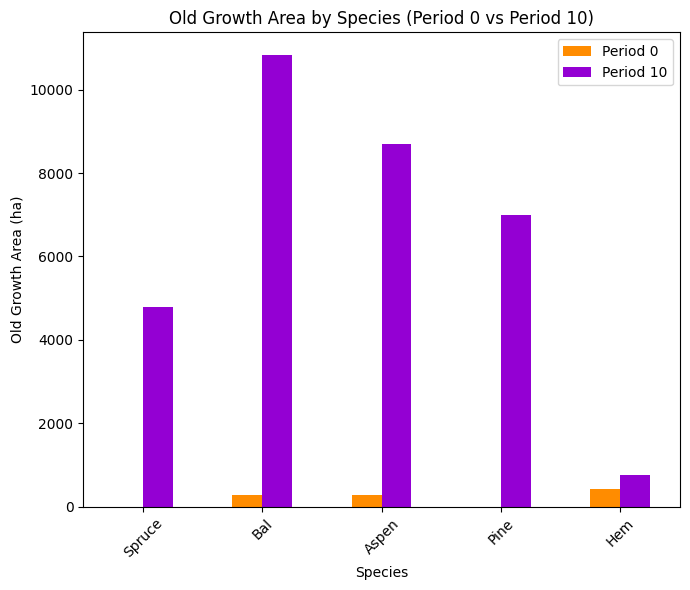

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_80%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8798

Diversity has **decreased** by 6.57% from time 0 to time 10.


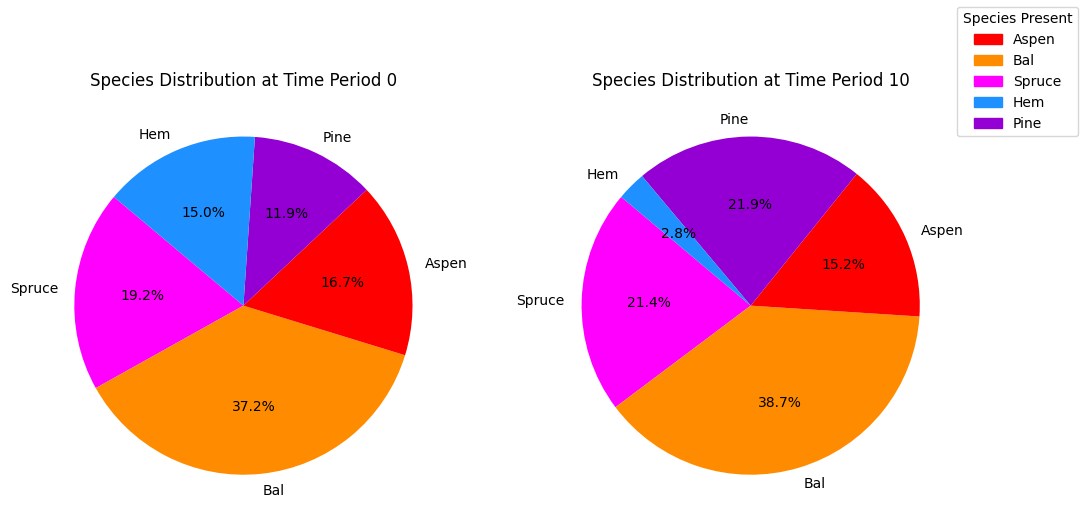

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_80%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

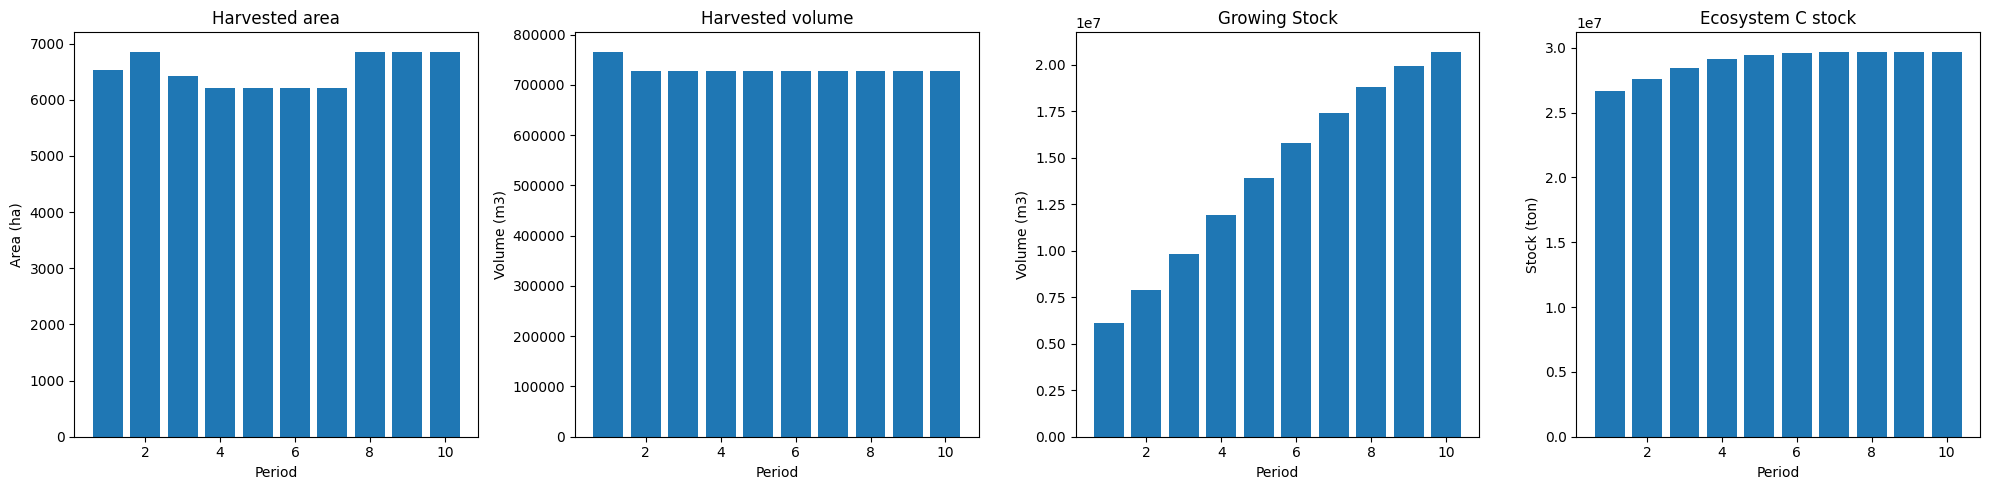

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


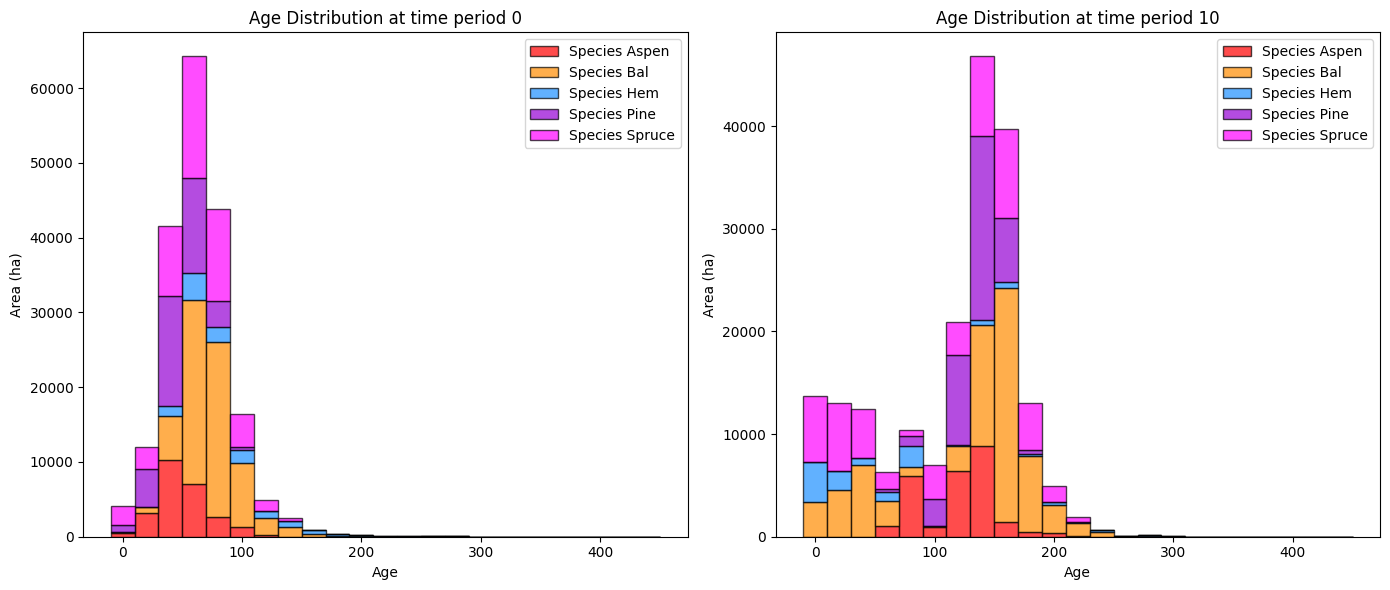

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


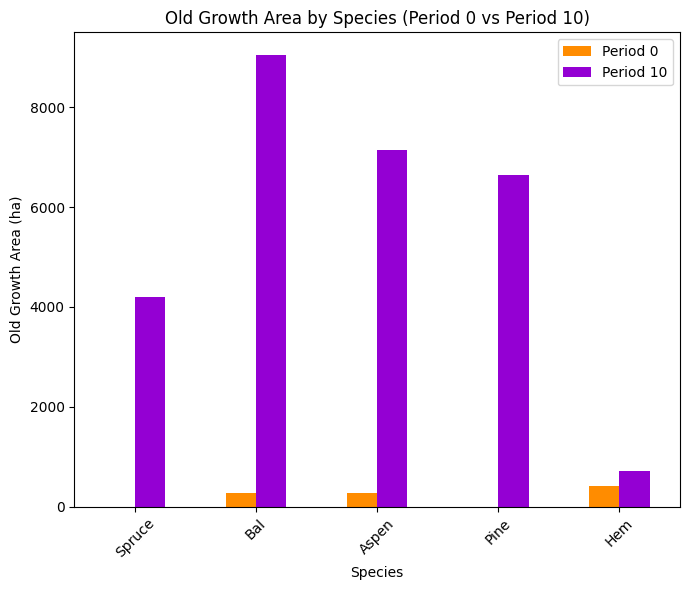

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


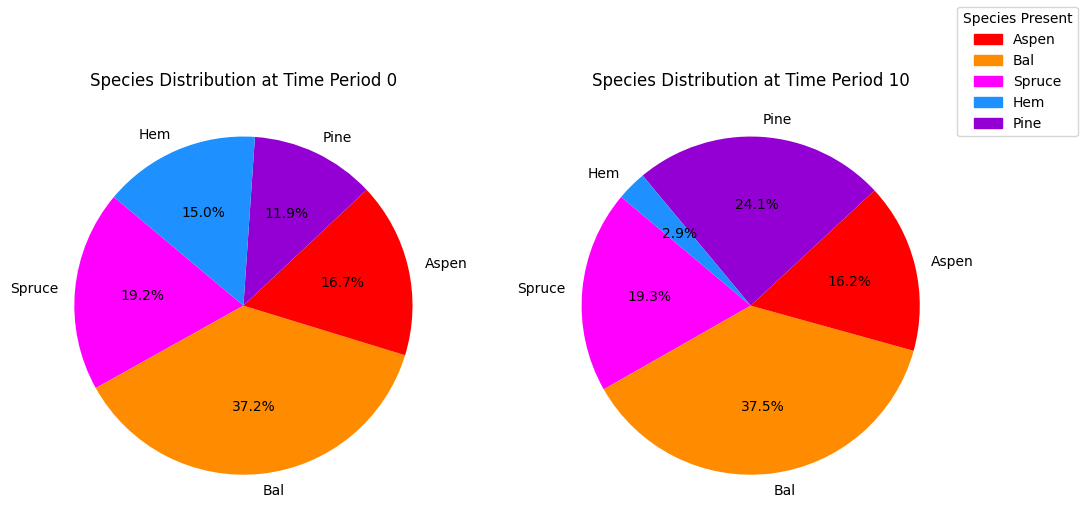

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


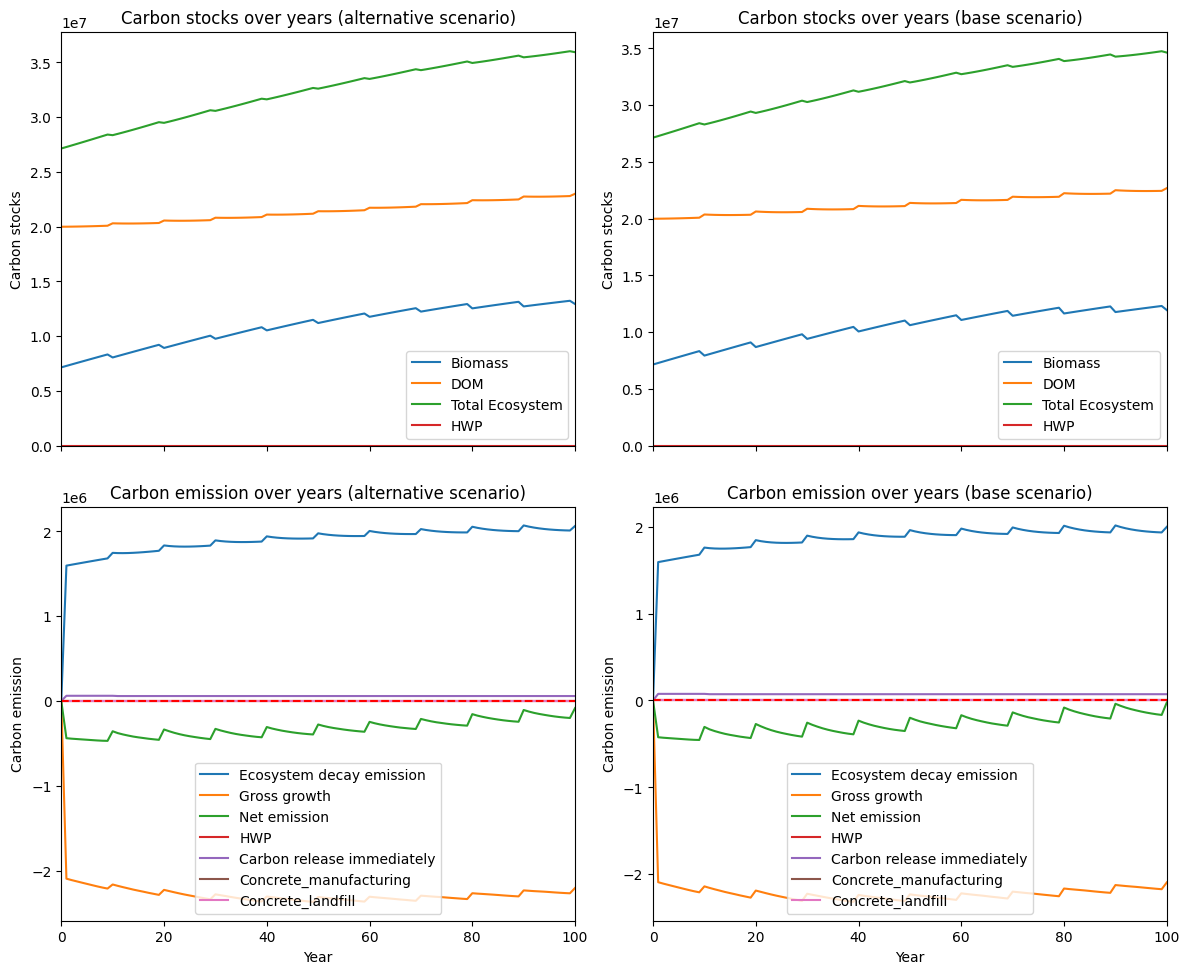

---------------------------------------------------------------------------------------
Net emission difference -766334.9040364607
Net emission base scenario -10164262.069894377
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  13.049125059197642
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   598.985192   598.985192
Bal     0.0  1784.827949  1784.827949
Aspen   0.0  1556.024615  1556.024615
Pine    0.0   346.921846   346.921846
Hem     0.0    48.817044    48.817044

Overall, the old growth area has **increased** by 4335.58 hectares in the alternative scenario compared to the base scenario.


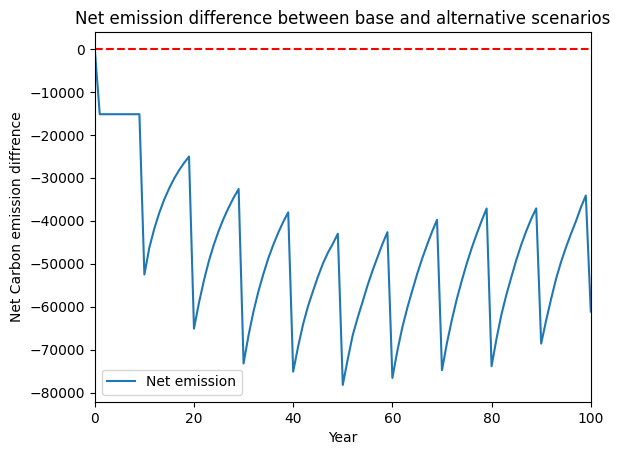

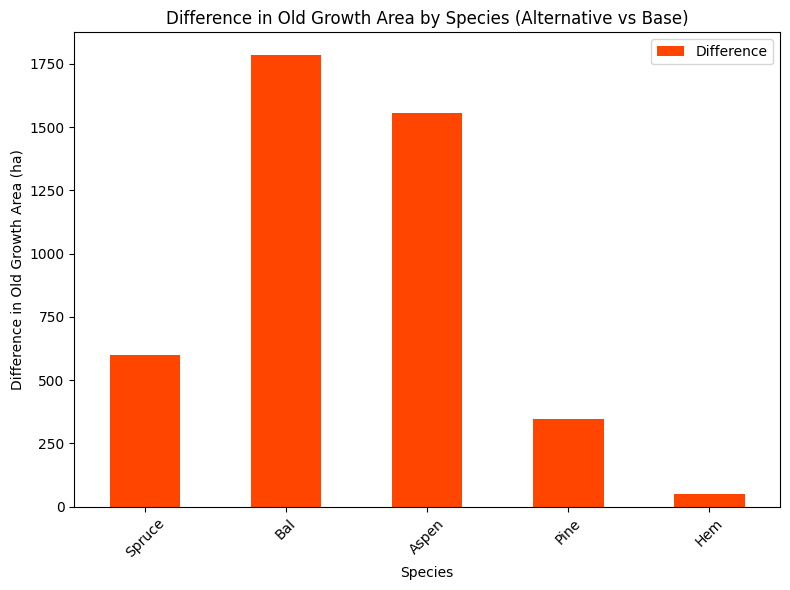

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


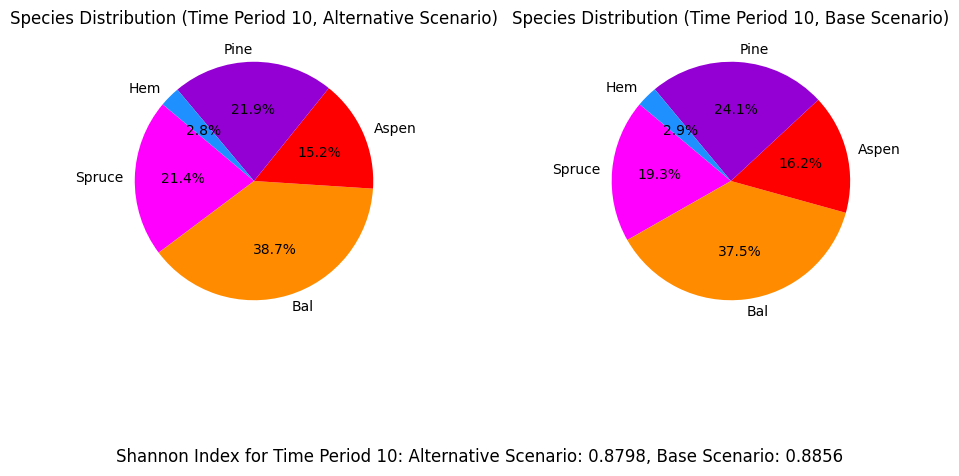

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_70%...
running the scenario for the Golden Bear mining site (70%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x65726460
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

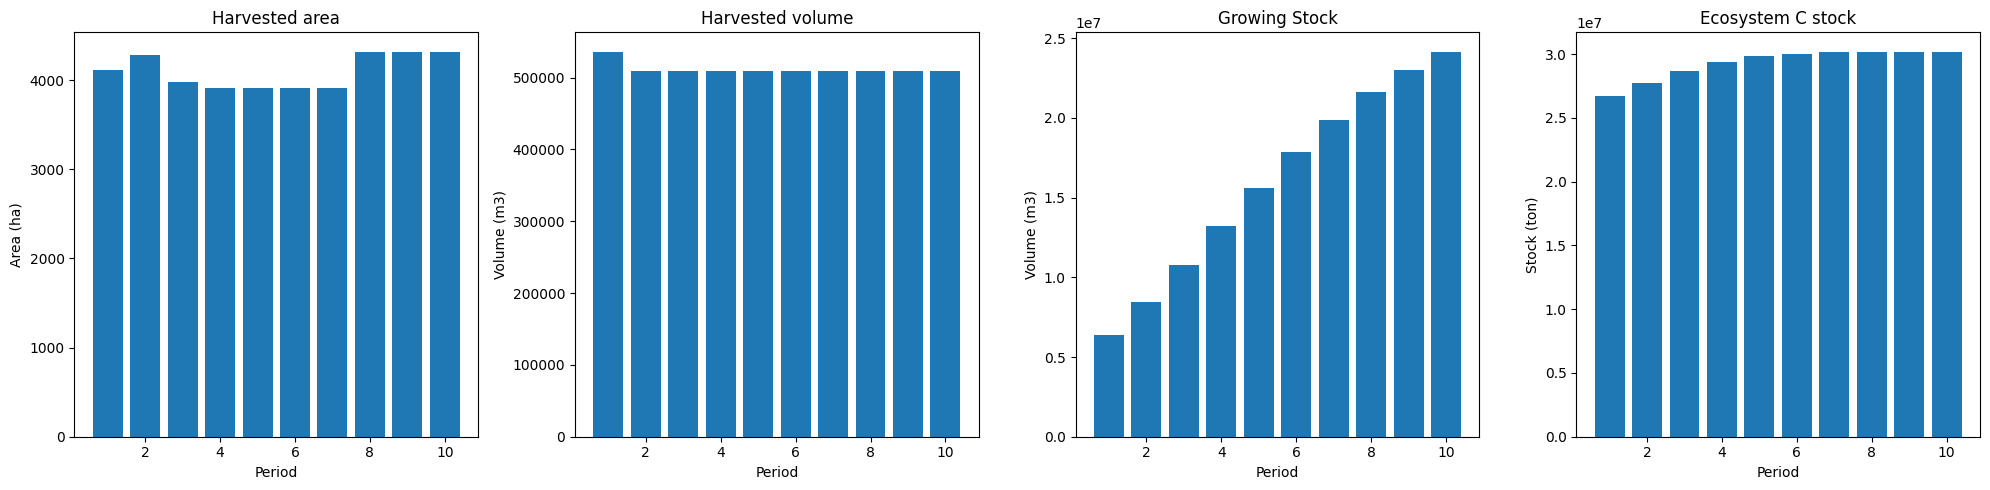

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_70%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  5414
The economic indicator (the provincial government revenues) is:  184633
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


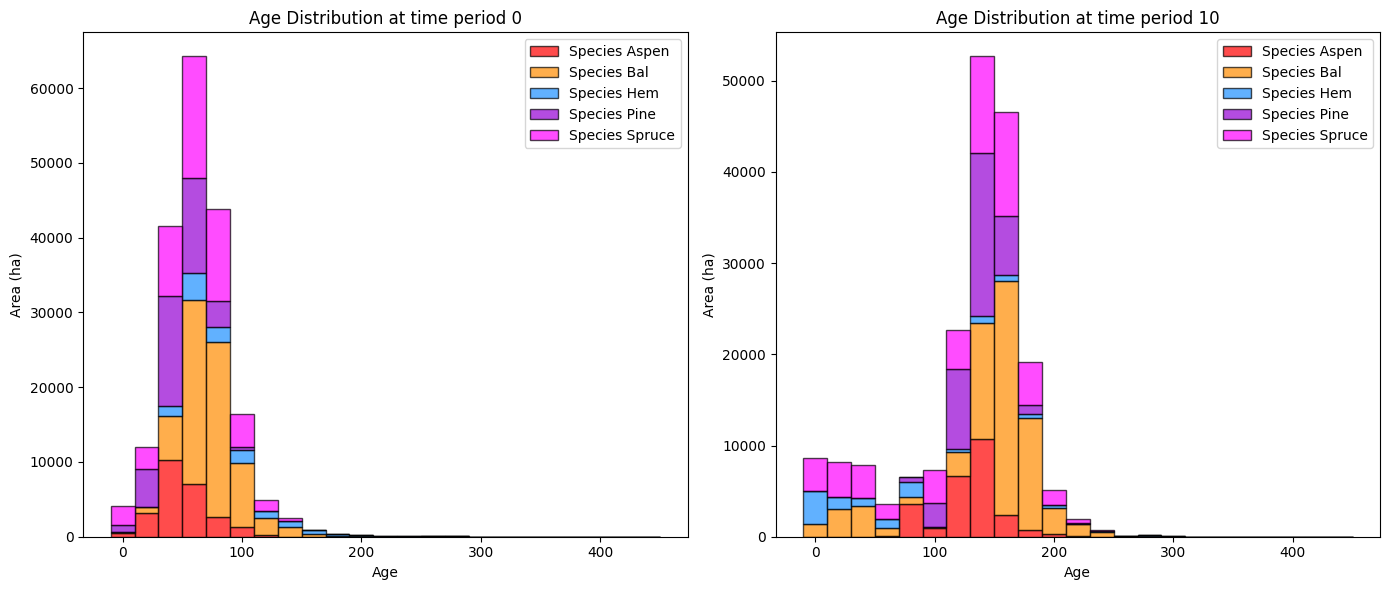

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_70%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   4884.930908   4882.222375
Bal     278.565372  11540.723666  11262.158295
Aspen   273.490478   9701.199345   9427.708867
Pine      0.000000   7229.843115   7229.843115
Hem     419.699331    779.239284    359.539953

Overall diversity has **increased** by 33161.47 hectares from time period 0 to time period 10.


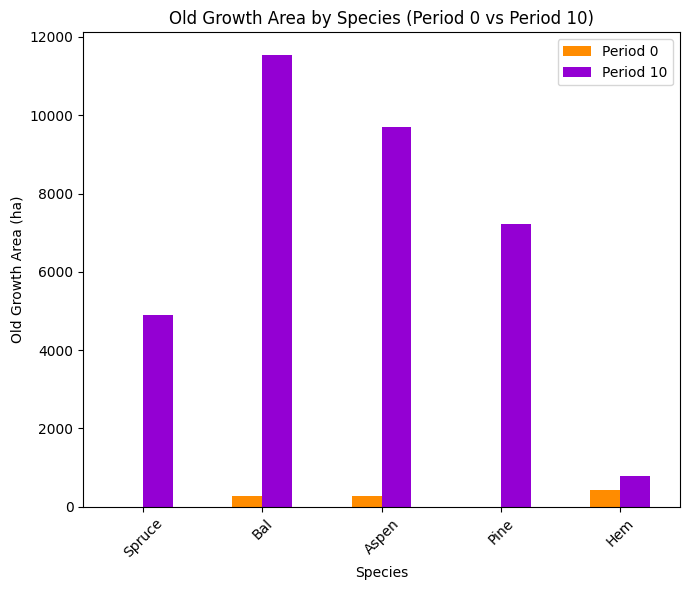

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_70%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8832

Diversity has **decreased** by 6.24% from time 0 to time 10.


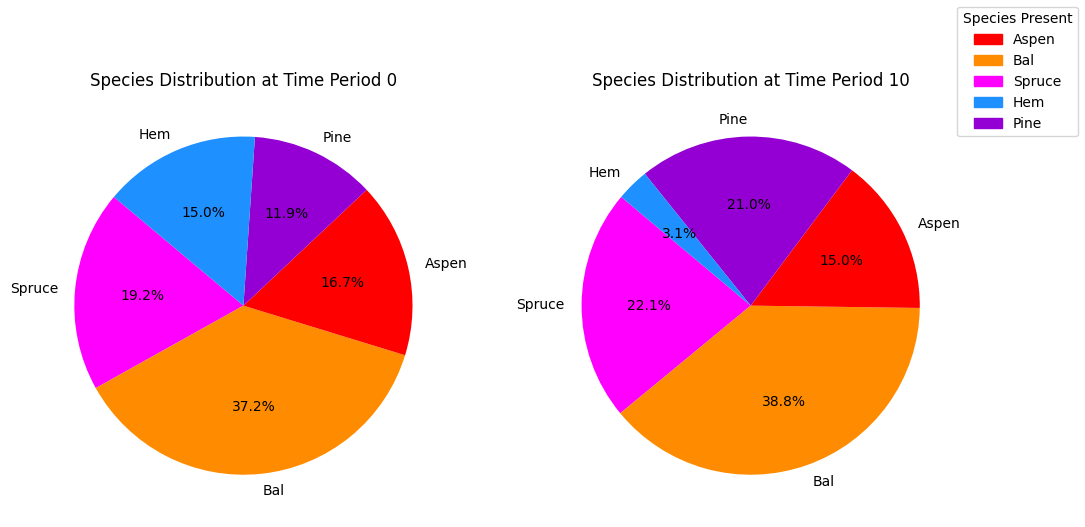

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_70%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.17s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

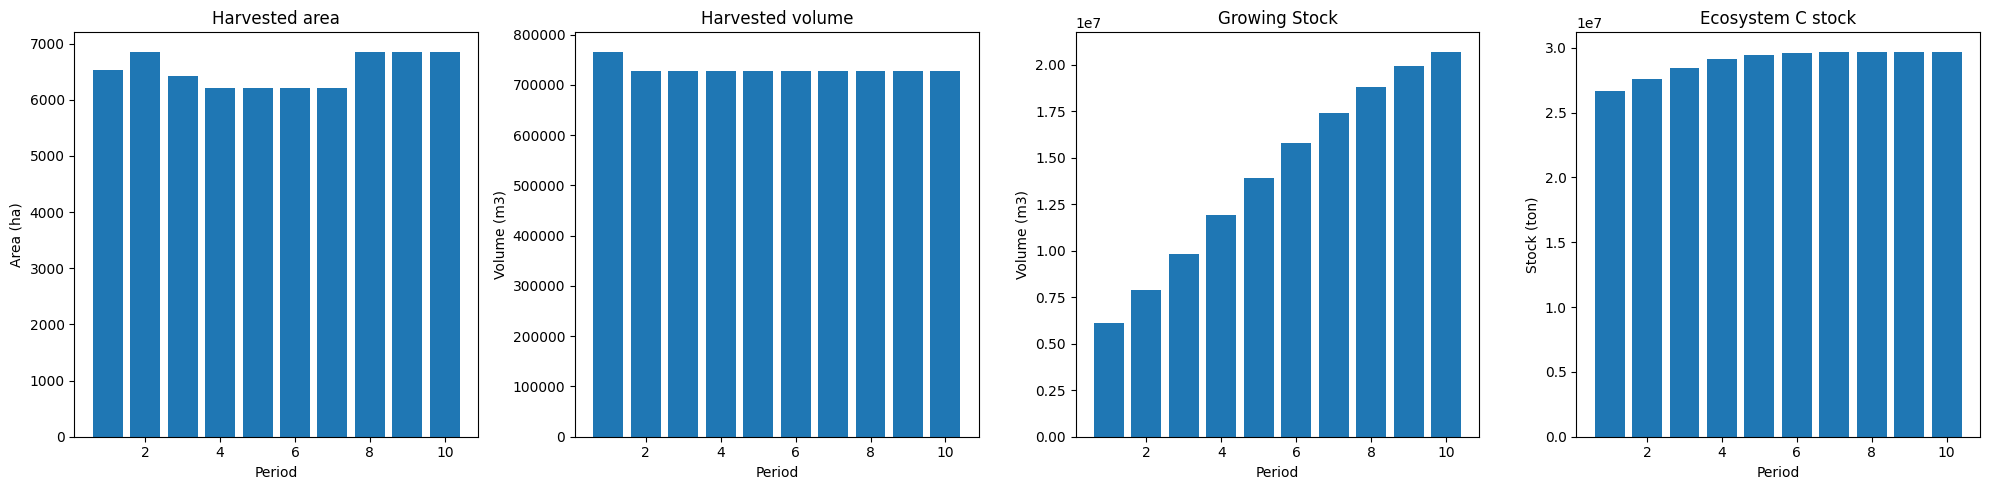

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


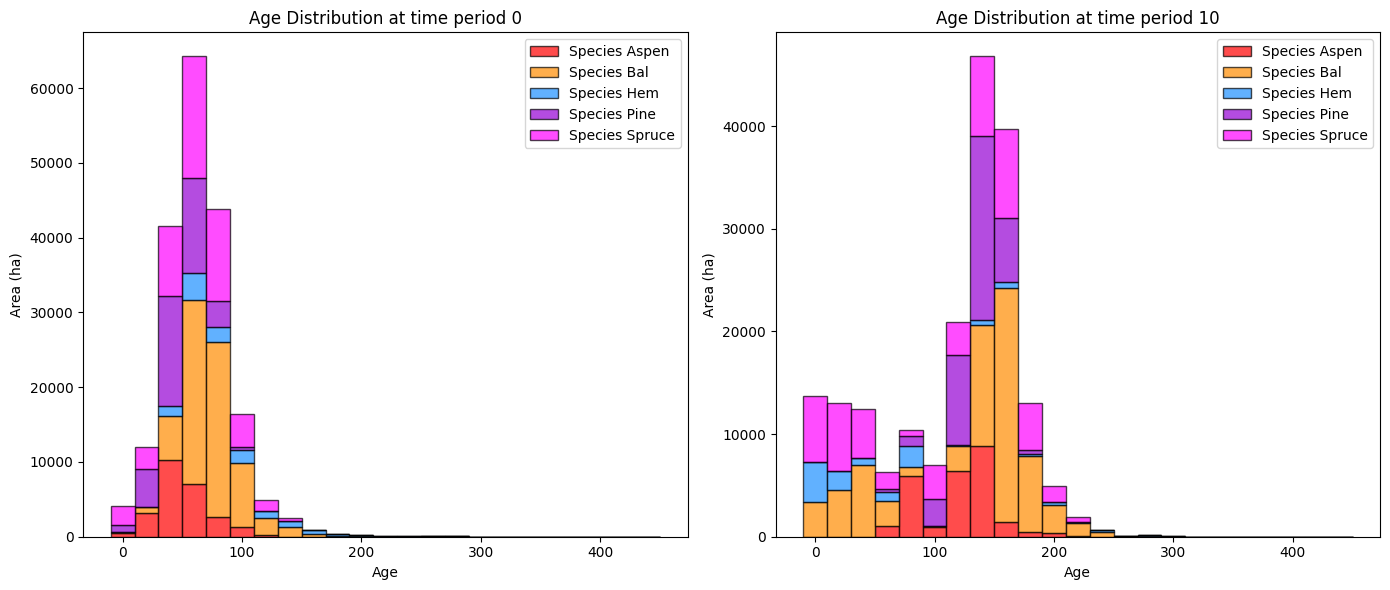

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


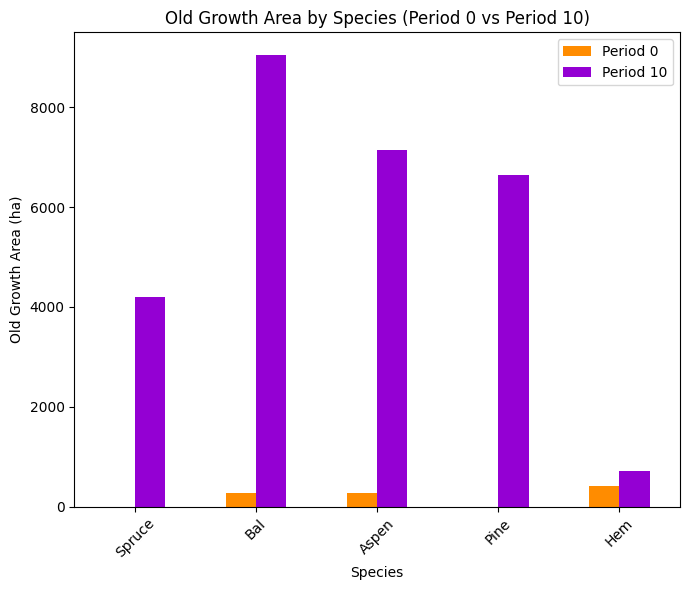

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


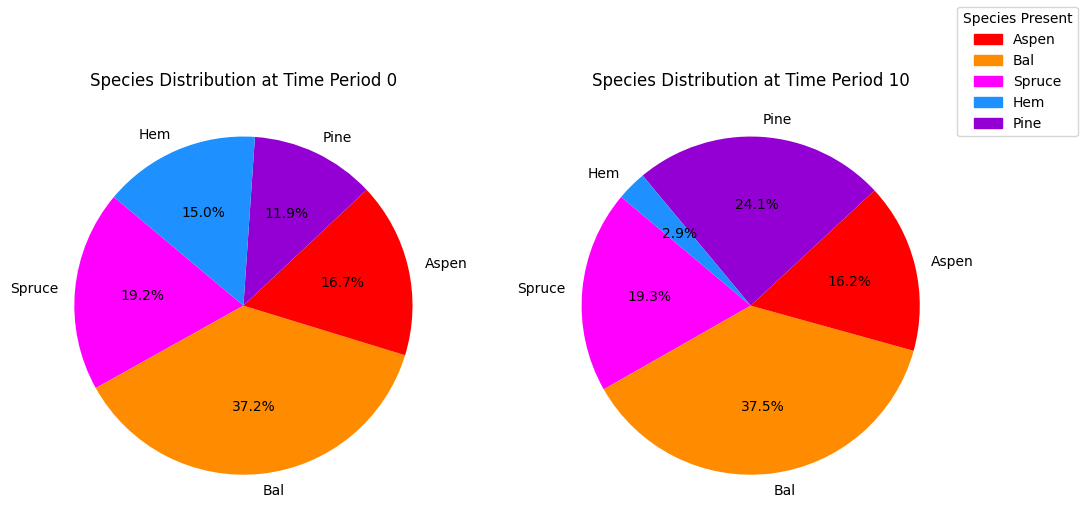

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


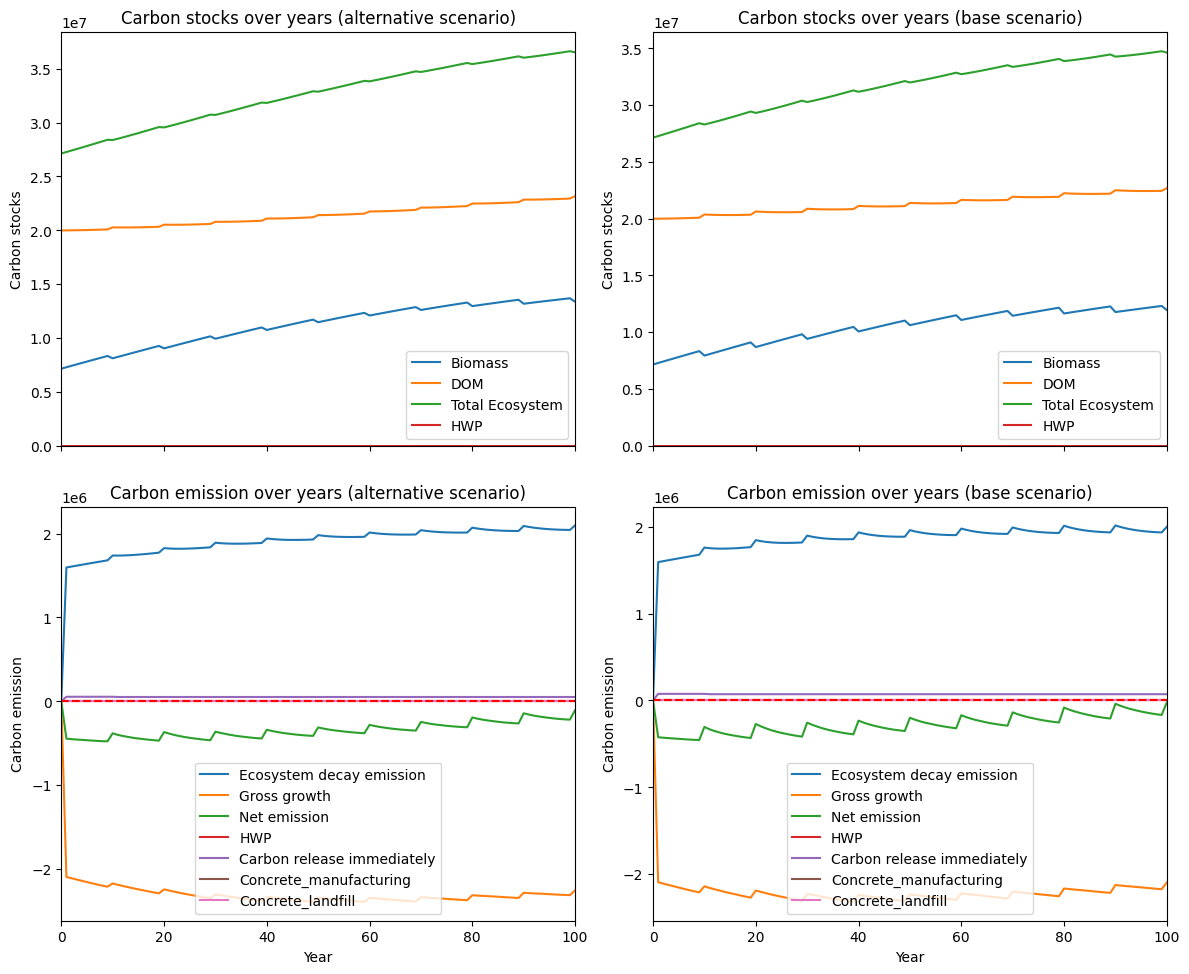

---------------------------------------------------------------------------------------
Net emission difference -1135934.85122332
Net emission base scenario -10533862.017081236
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  8.803321765531466
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0   691.847087   691.847087
Bal     0.0  2494.775696  2494.775696
Aspen   0.0  2550.089083  2550.089083
Pine    0.0   579.387178   579.387178
Hem     0.0    68.335871    68.335871

Overall, the old growth area has **increased** by 6384.43 hectares in the alternative scenario compared to the base scenario.


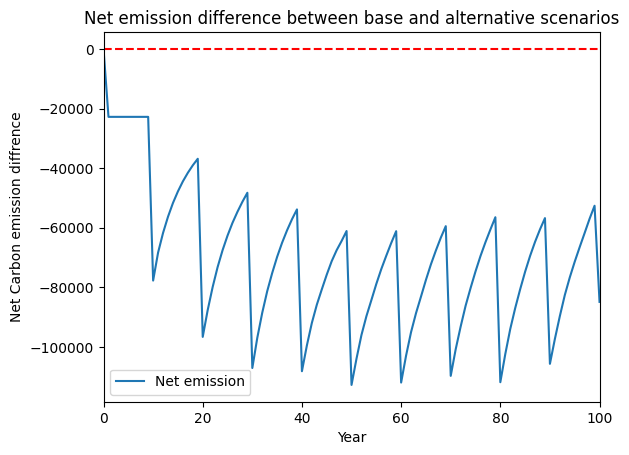

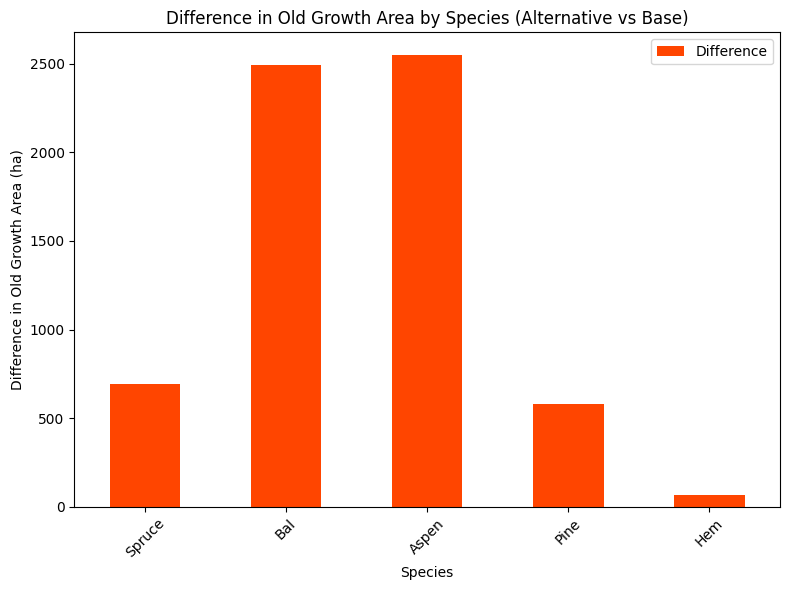

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


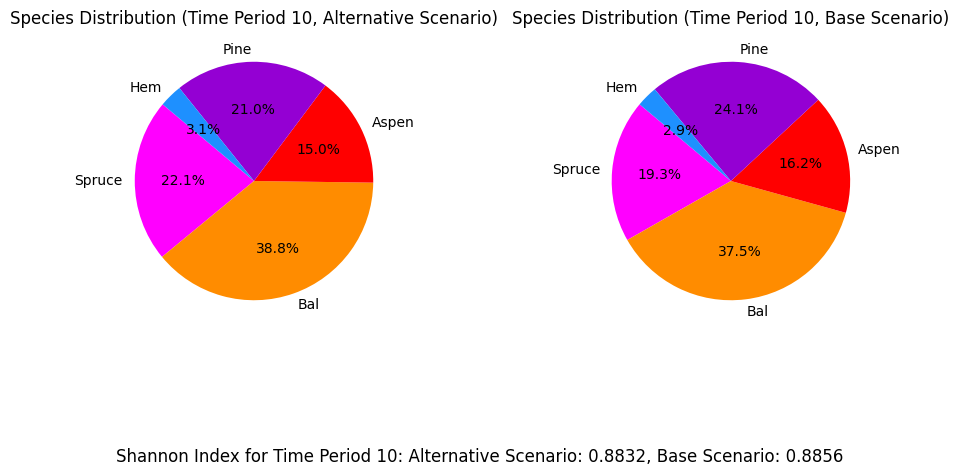

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_60%...
running the scenario for the Golden Bear mining site (60%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x705093fa
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.16s
Presolved: 1911 rows, 34100 

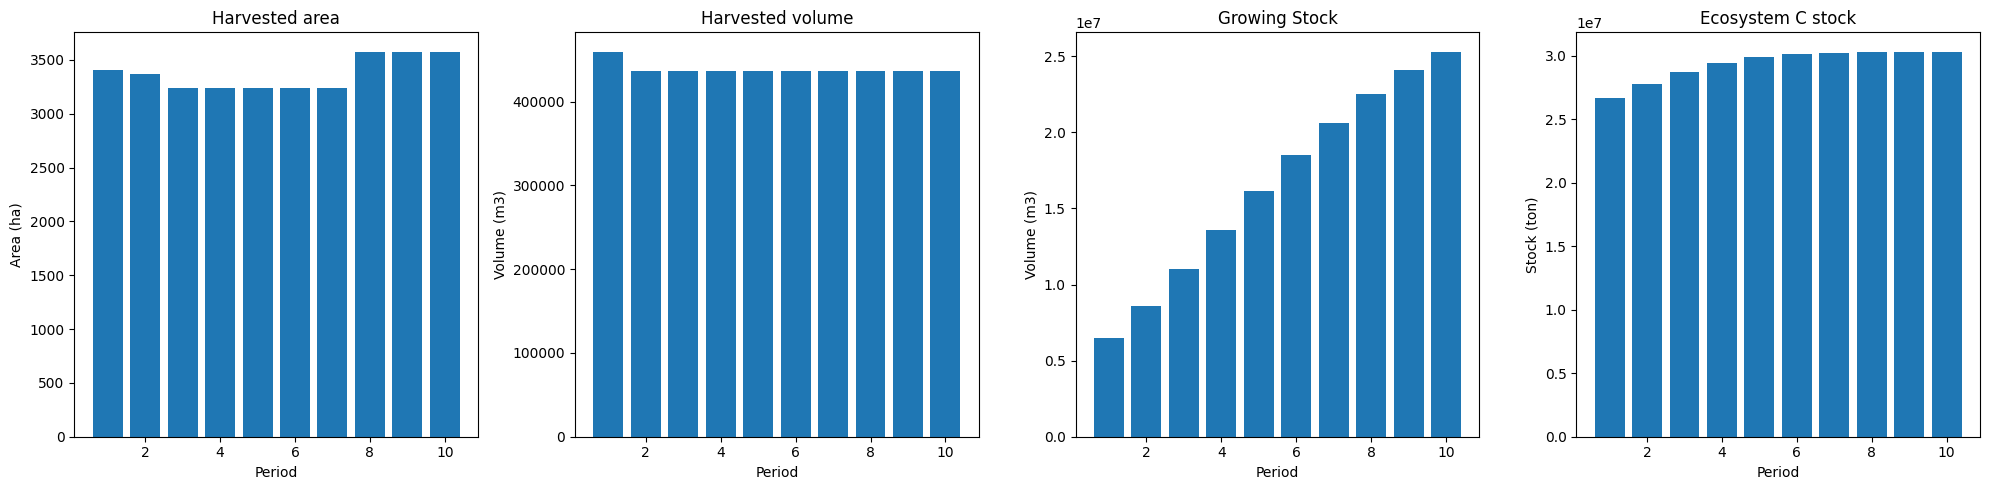

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_60%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  4640
The economic indicator (the provincial government revenues) is:  158257
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


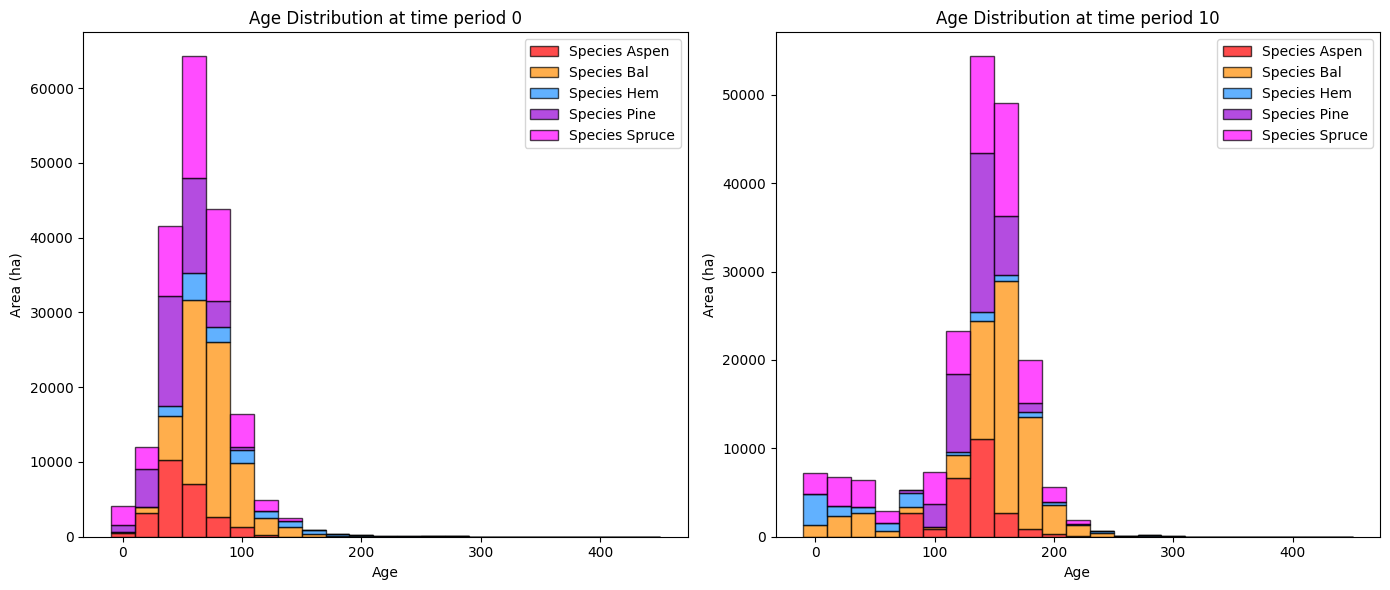

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_60%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5238.934076   5236.225543
Bal     278.565372  12109.141349  11830.575977
Aspen   273.490478  10588.456866  10314.966388
Pine      0.000000   7442.094666   7442.094666
Hem     419.699331    824.039567    404.340236

Overall diversity has **increased** by 35228.20 hectares from time period 0 to time period 10.


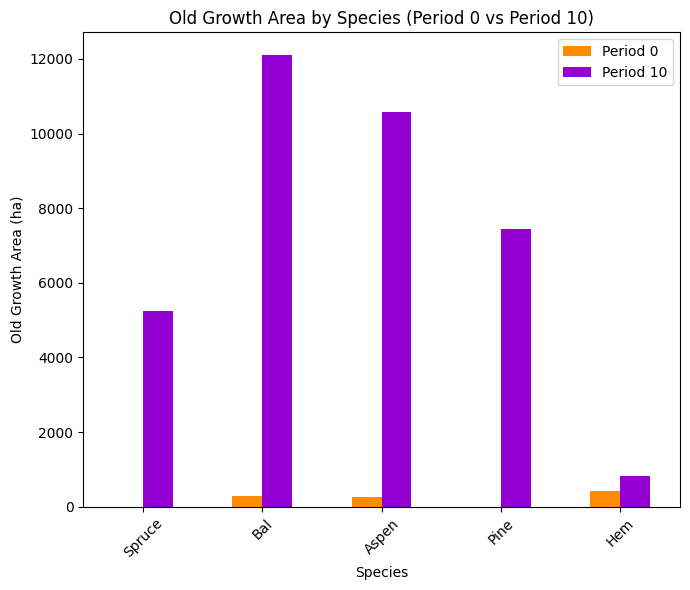

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_60%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


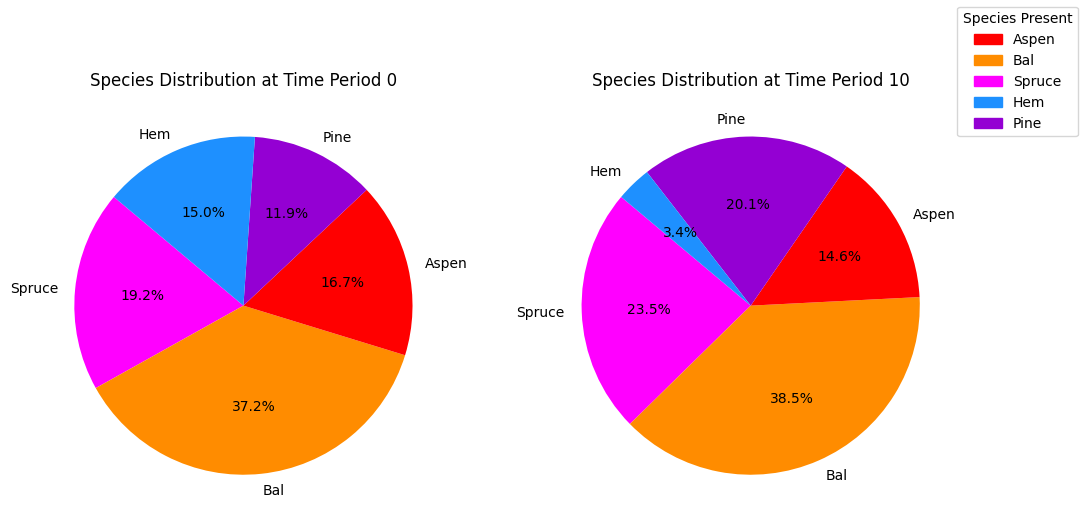

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_60%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.18s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

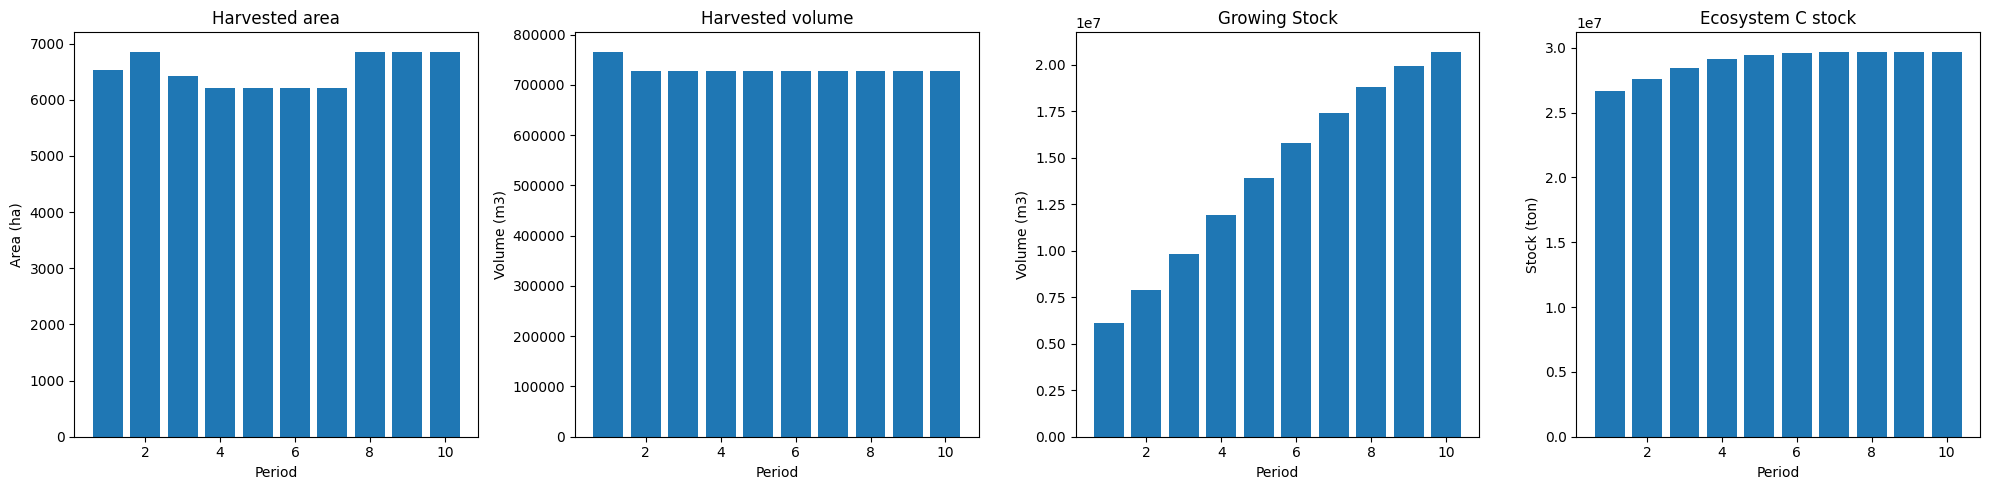

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


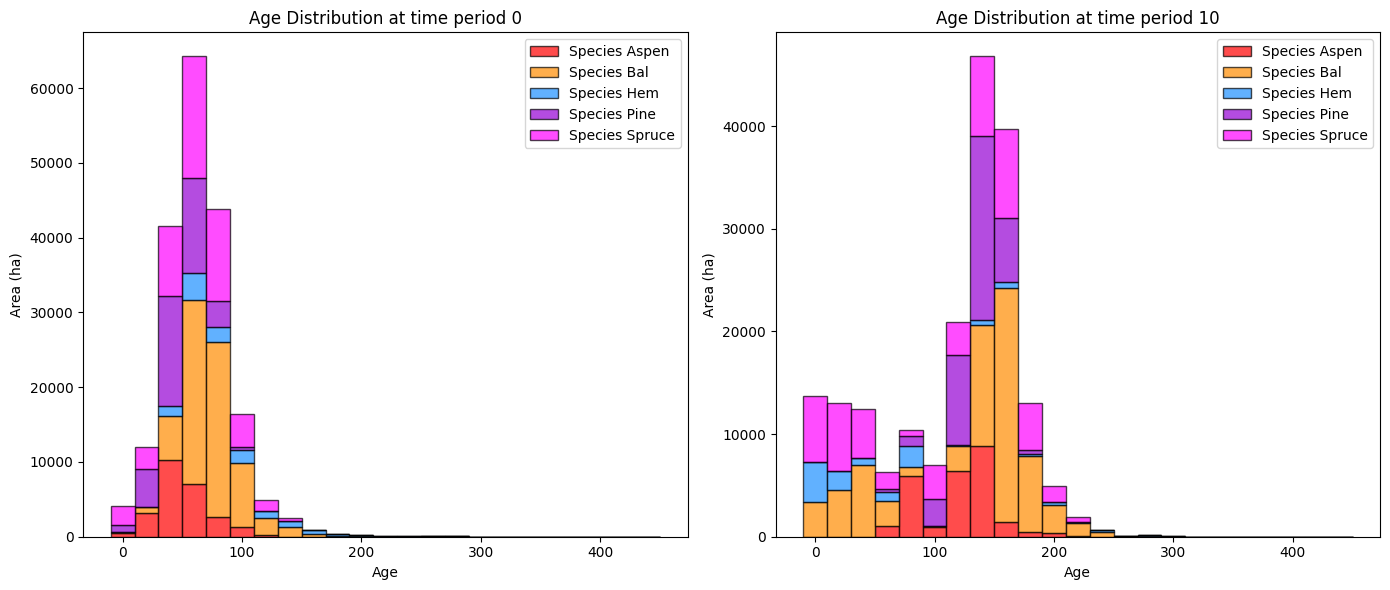

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


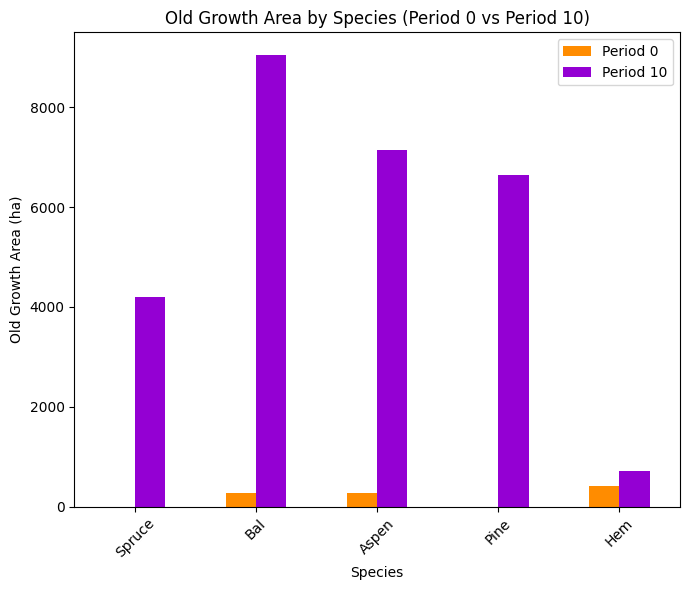

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


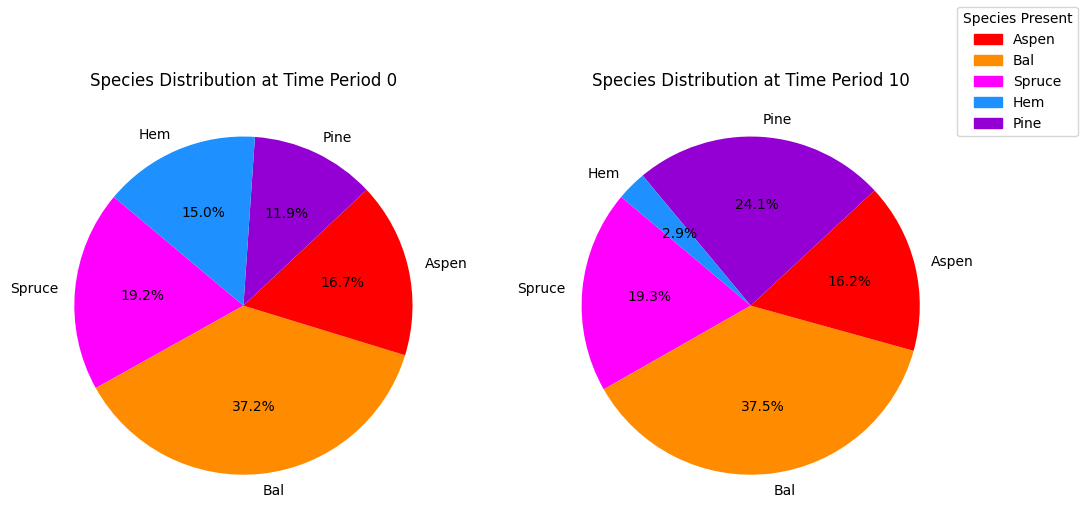

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


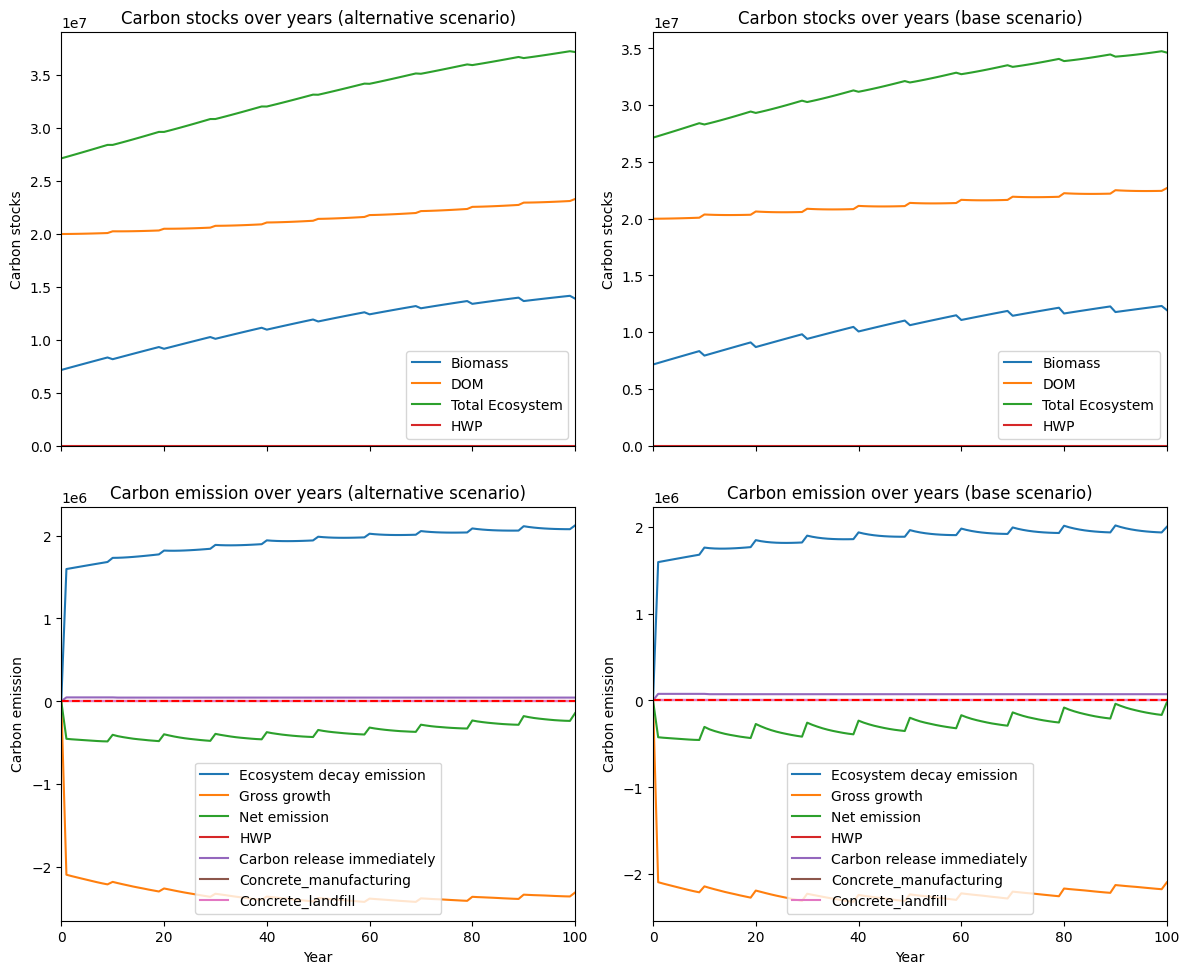

---------------------------------------------------------------------------------------
Net emission difference -1497745.634657567
Net emission base scenario -10895672.800515482
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  6.676701149114899
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1045.850256  1045.850256
Bal     0.0  3063.193379  3063.193379
Aspen   0.0  3437.346604  3437.346604
Pine    0.0   791.638728   791.638728
Hem     0.0   113.136154   113.136154

Overall, the old growth area has **increased** by 8451.17 hectares in the alternative scenario compared to the base scenario.


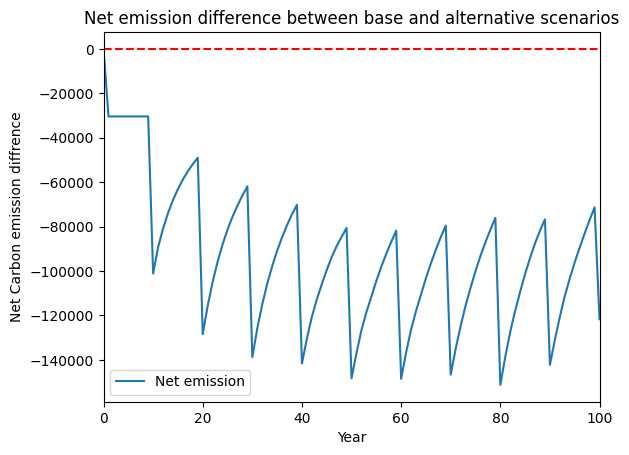

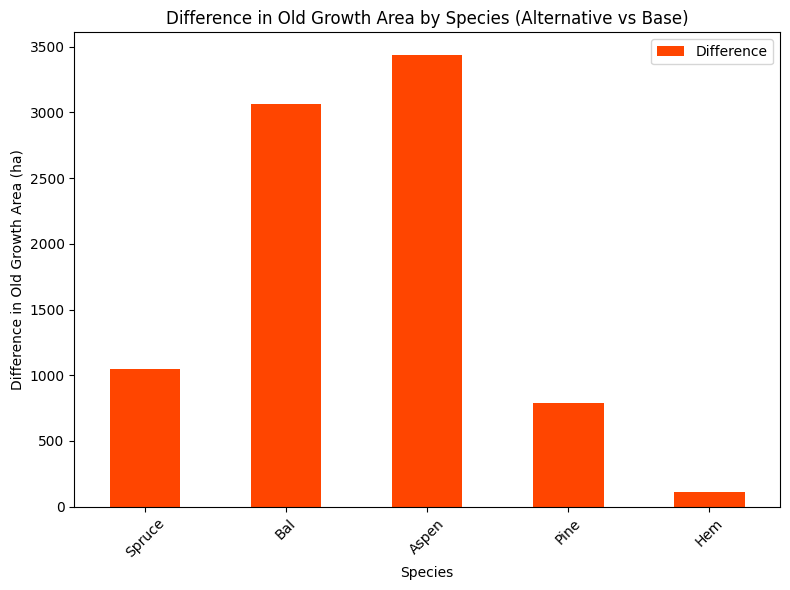

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


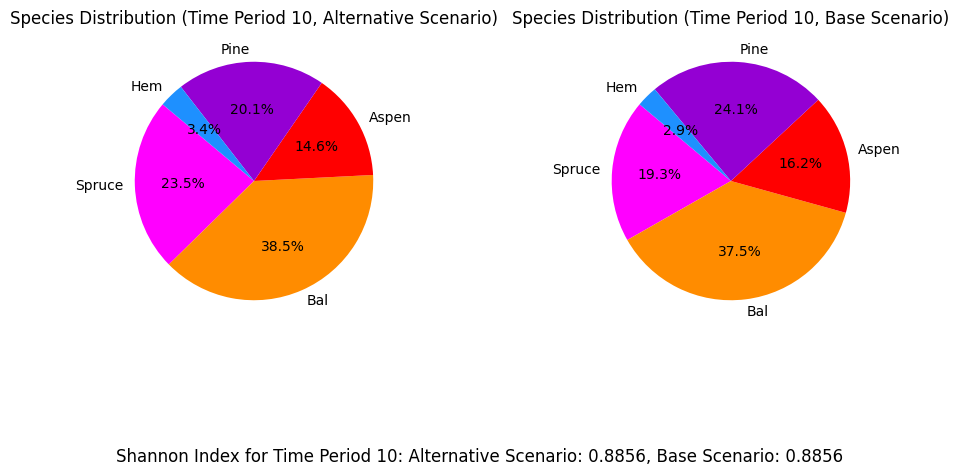

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_50%...
running the scenario for the Golden Bear mining site (50%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x59979ad4
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34100 

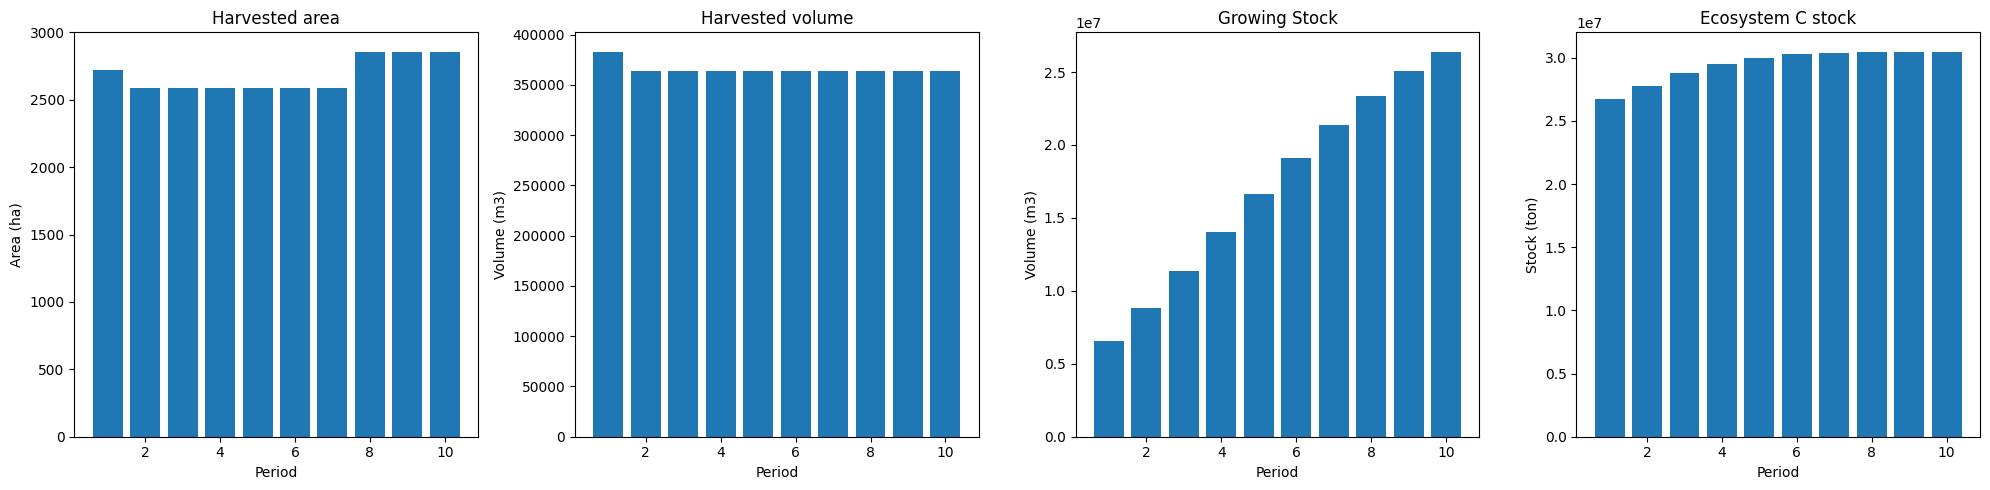

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_50%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3867
The economic indicator (the provincial government revenues) is:  131881
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


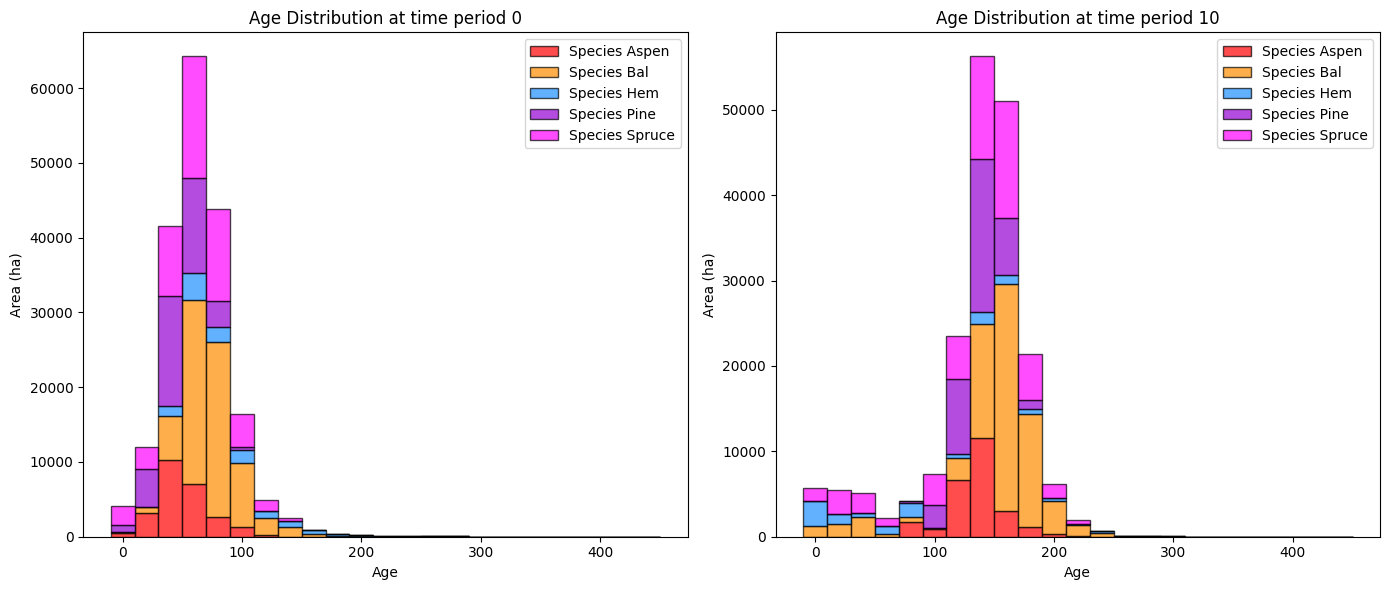

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_50%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5513.108798   5510.400265
Bal     278.565372  12843.561585  12564.996213
Aspen   273.490478  11528.582901  11255.092423
Pine      0.000000   7496.113931   7496.113931
Hem     419.699331    830.482584    410.783253

Overall diversity has **increased** by 37237.39 hectares from time period 0 to time period 10.


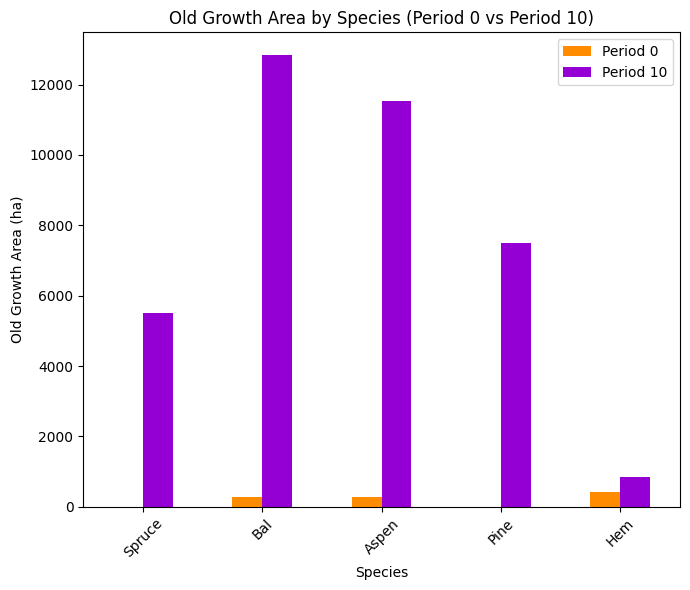

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_50%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8930

Diversity has **decreased** by 5.25% from time 0 to time 10.


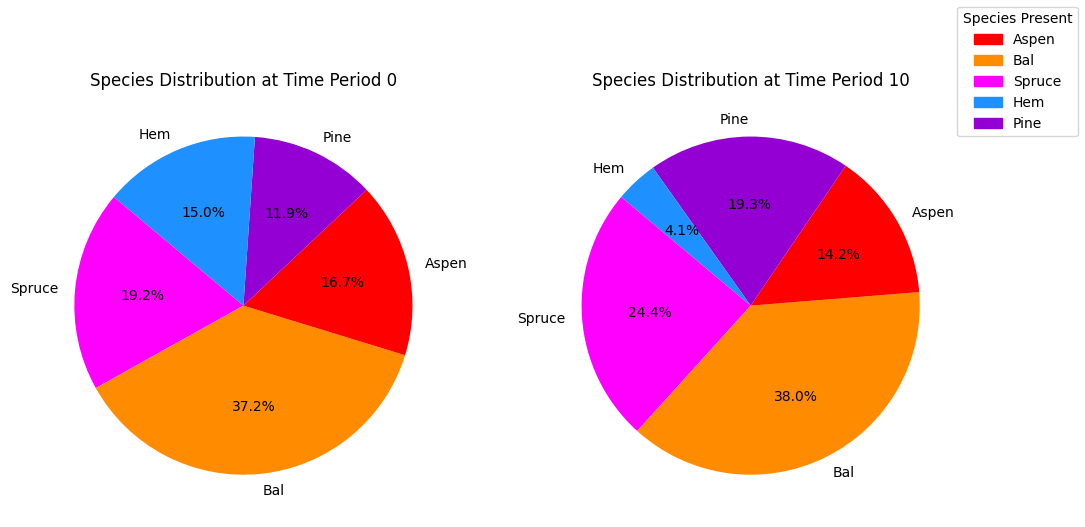

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_50%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

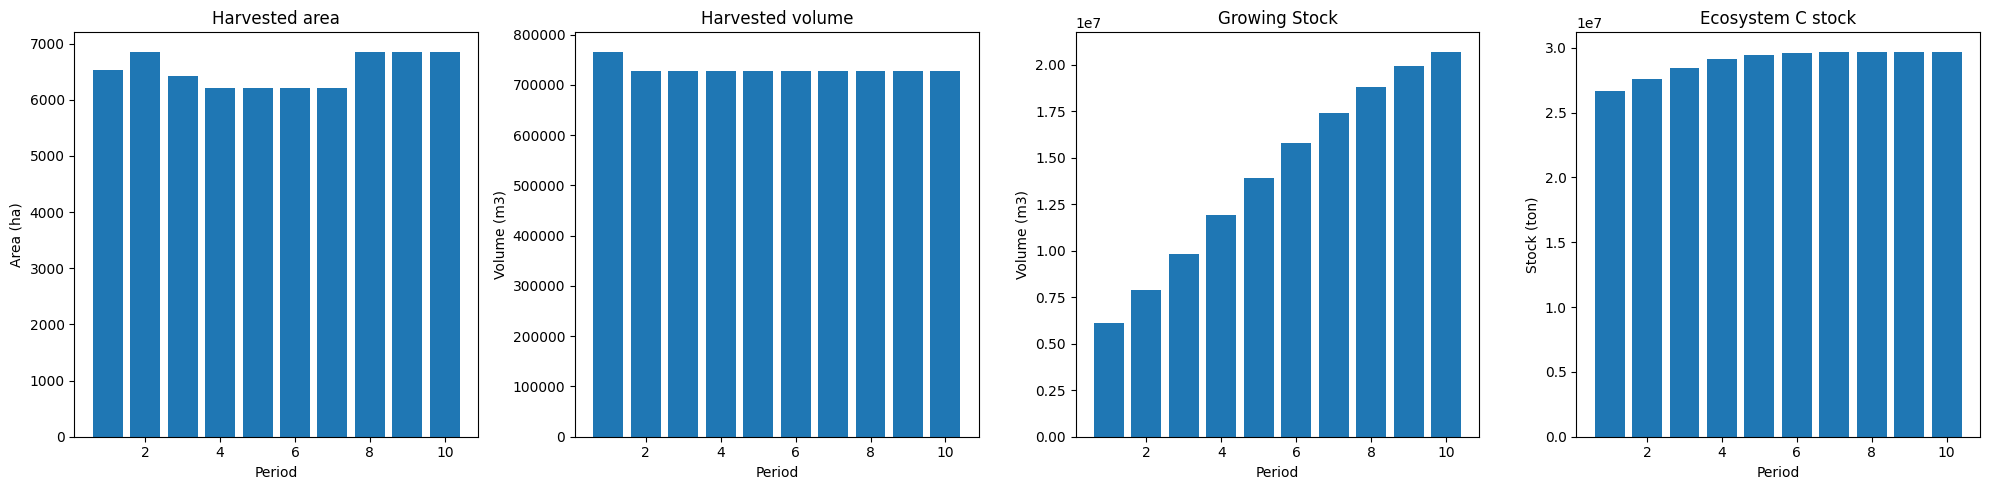

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


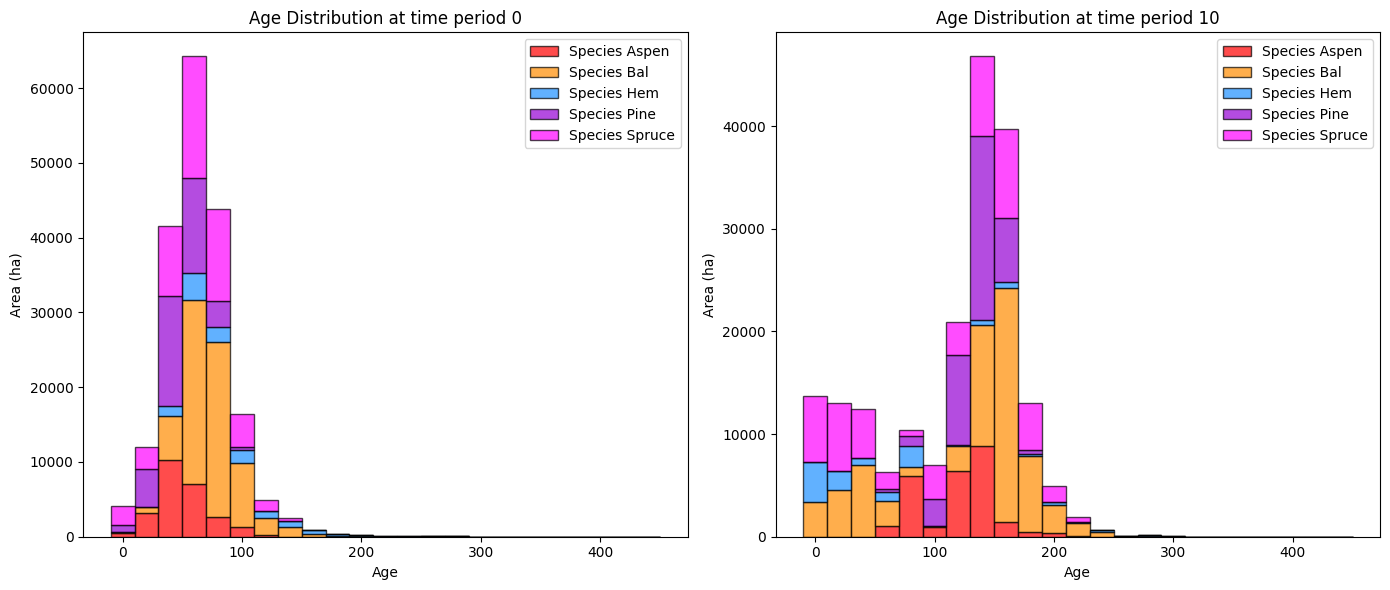

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


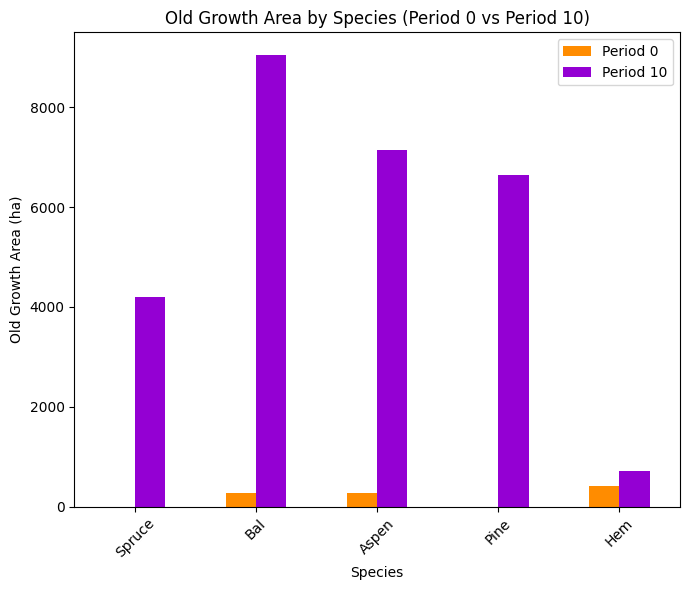

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


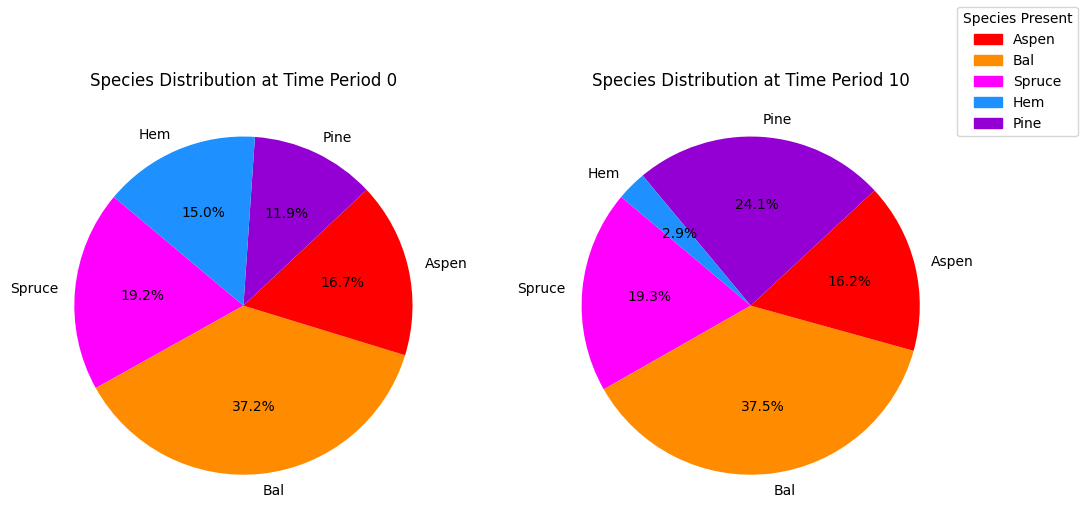

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


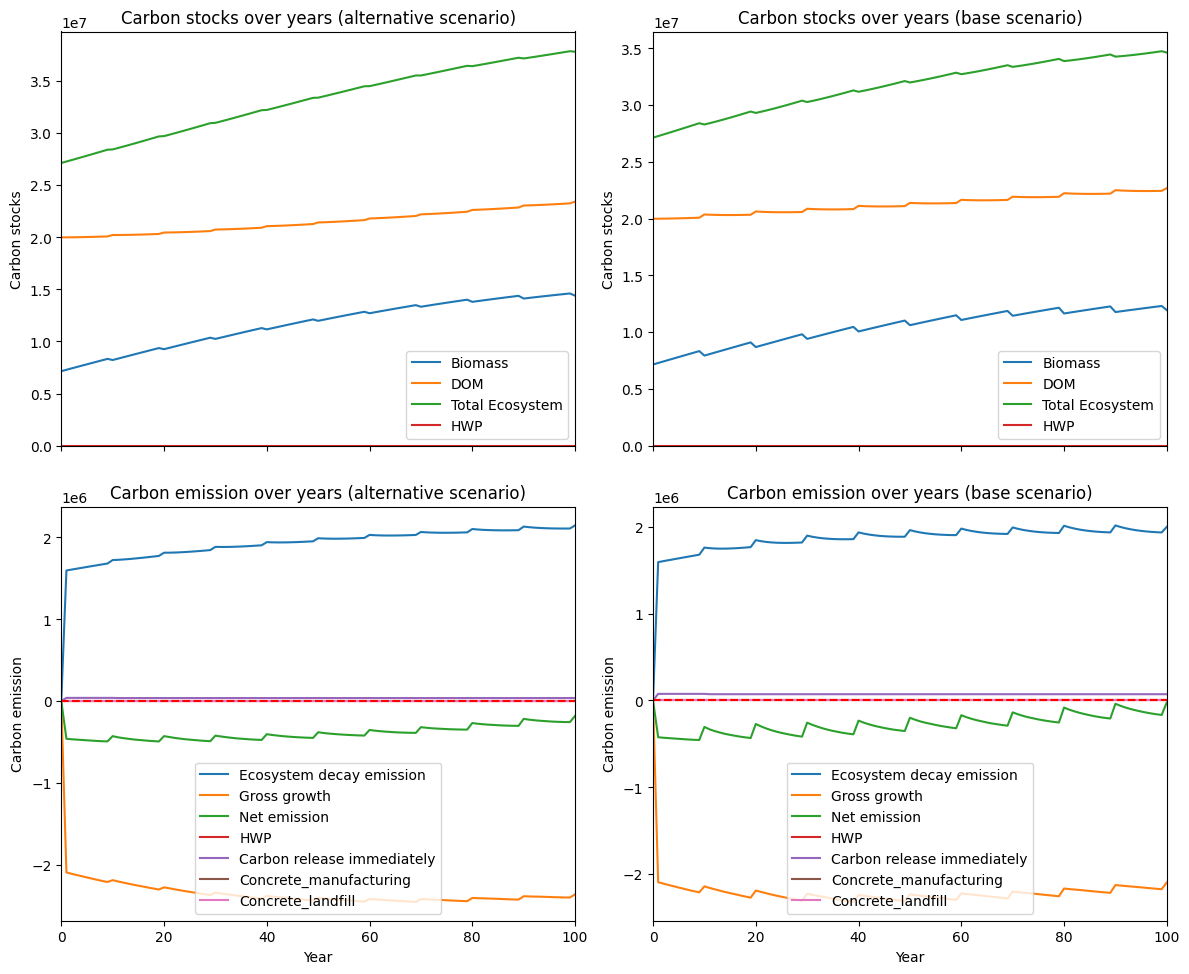

---------------------------------------------------------------------------------------
Net emission difference -1854211.7015219843
Net emission base scenario -11252138.867379902
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  5.3931274361993
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1320.024978  1320.024978
Bal     0.0  3797.613614  3797.613614
Aspen   0.0  4377.472640  4377.472640
Pine    0.0   845.657993   845.657993
Hem     0.0   119.579171   119.579171

Overall, the old growth area has **increased** by 10460.35 hectares in the alternative scenario compared to the base scenario.


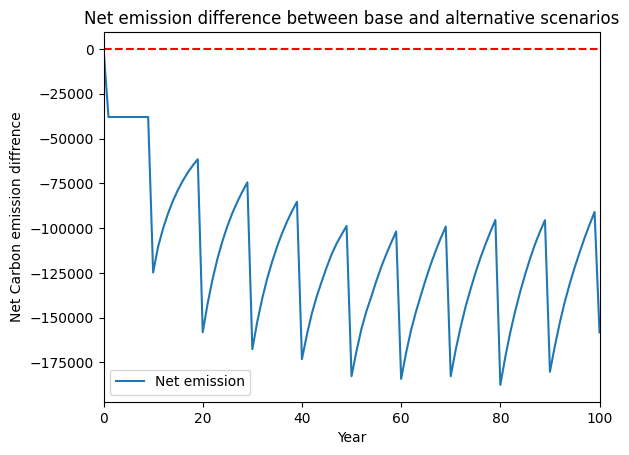

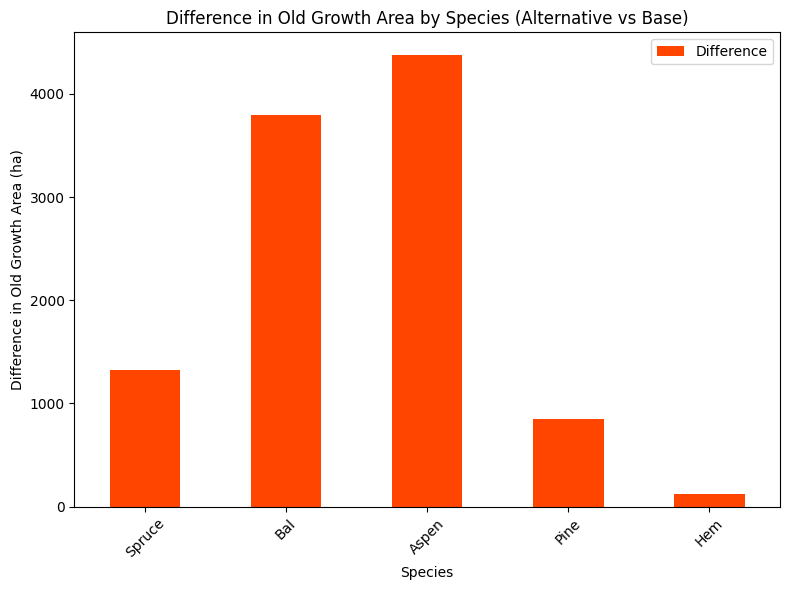

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


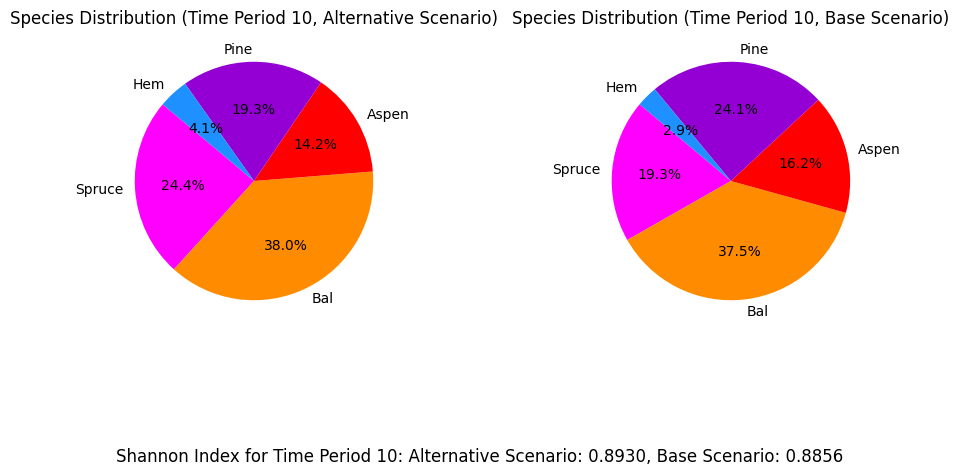

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_40%...
running the scenario for the Golden Bear mining site (40%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x950f26cf
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34100 

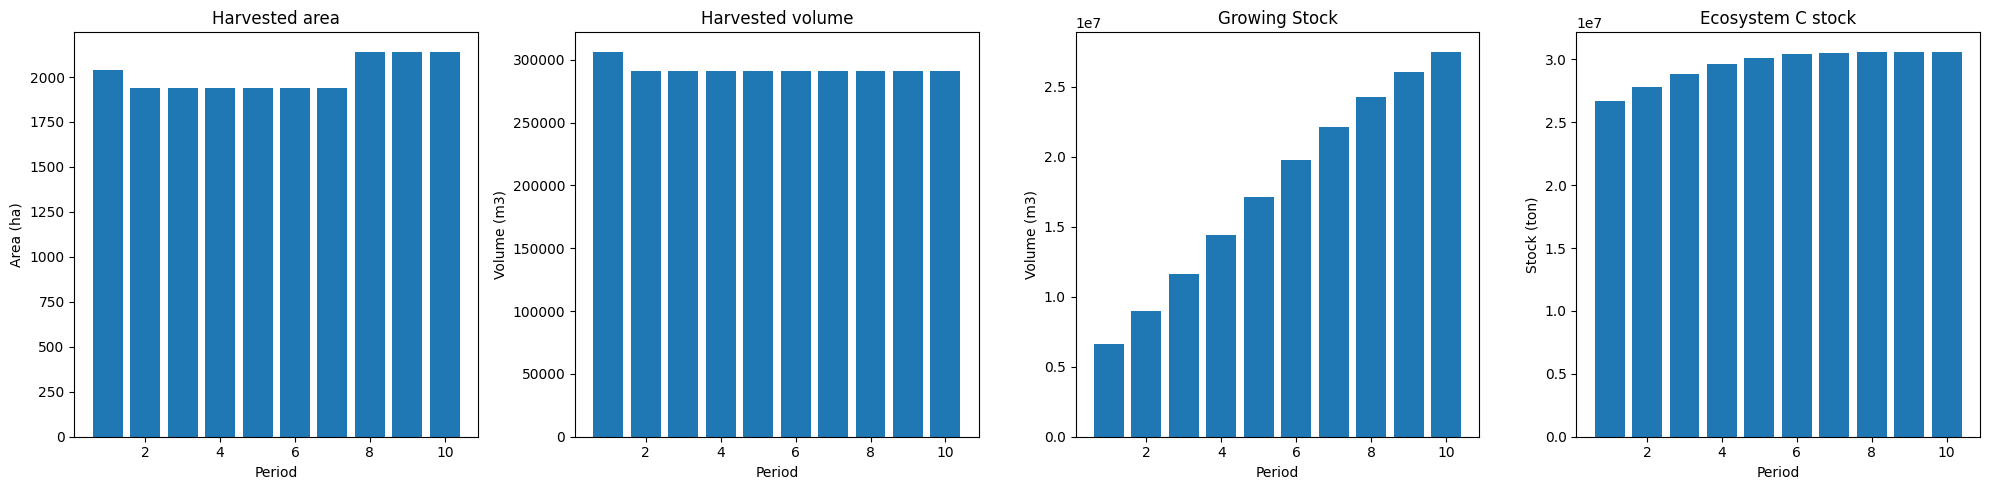

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_40%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  3093
The economic indicator (the provincial government revenues) is:  105504
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


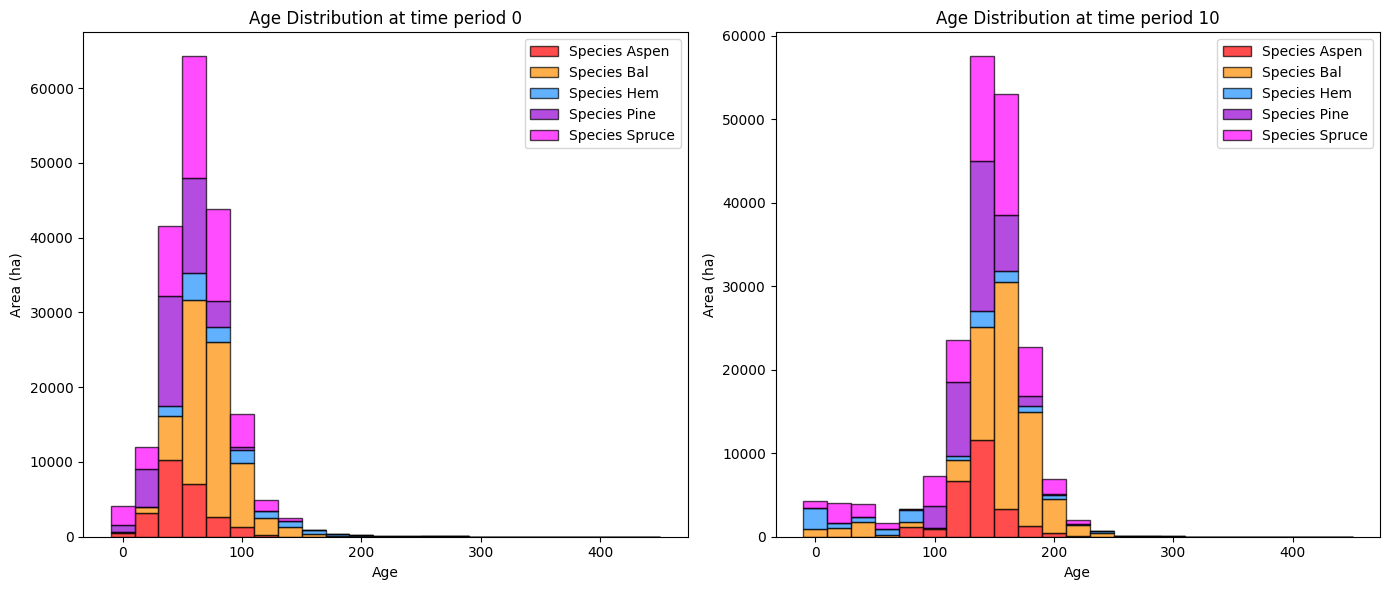

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_40%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   5986.986092   5984.277558
Bal     278.565372  13364.184621  13085.619249
Aspen   273.490478  11997.125161  11723.634683
Pine      0.000000   7600.584472   7600.584472
Hem     419.699331   1044.913937    625.214606

Overall diversity has **increased** by 39019.33 hectares from time period 0 to time period 10.


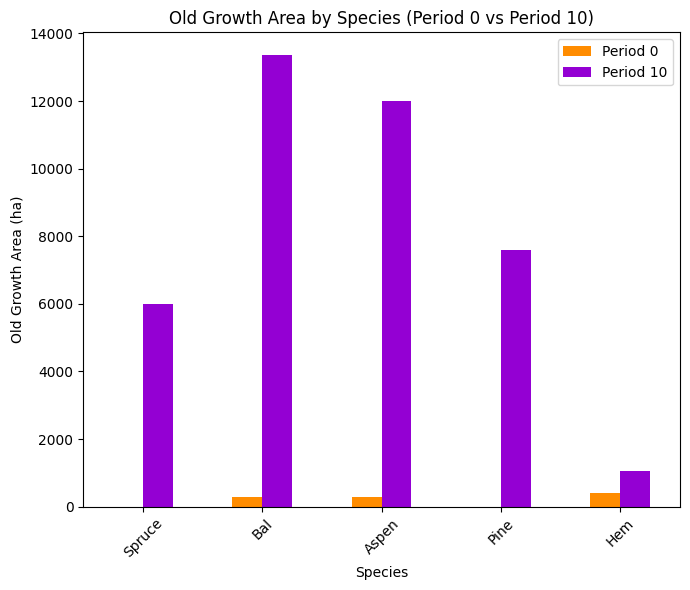

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_40%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9018

Diversity has **decreased** by 4.37% from time 0 to time 10.


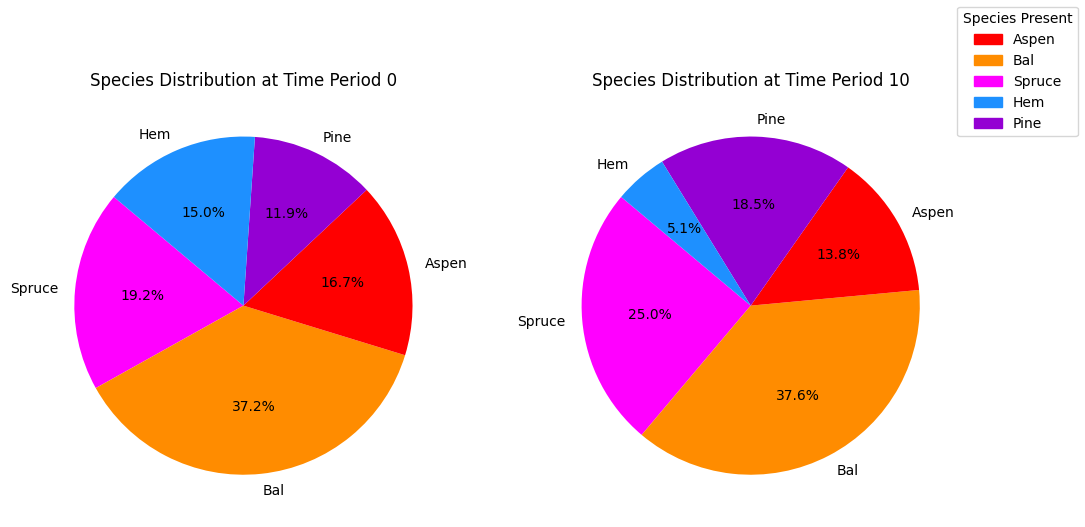

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_40%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.17s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

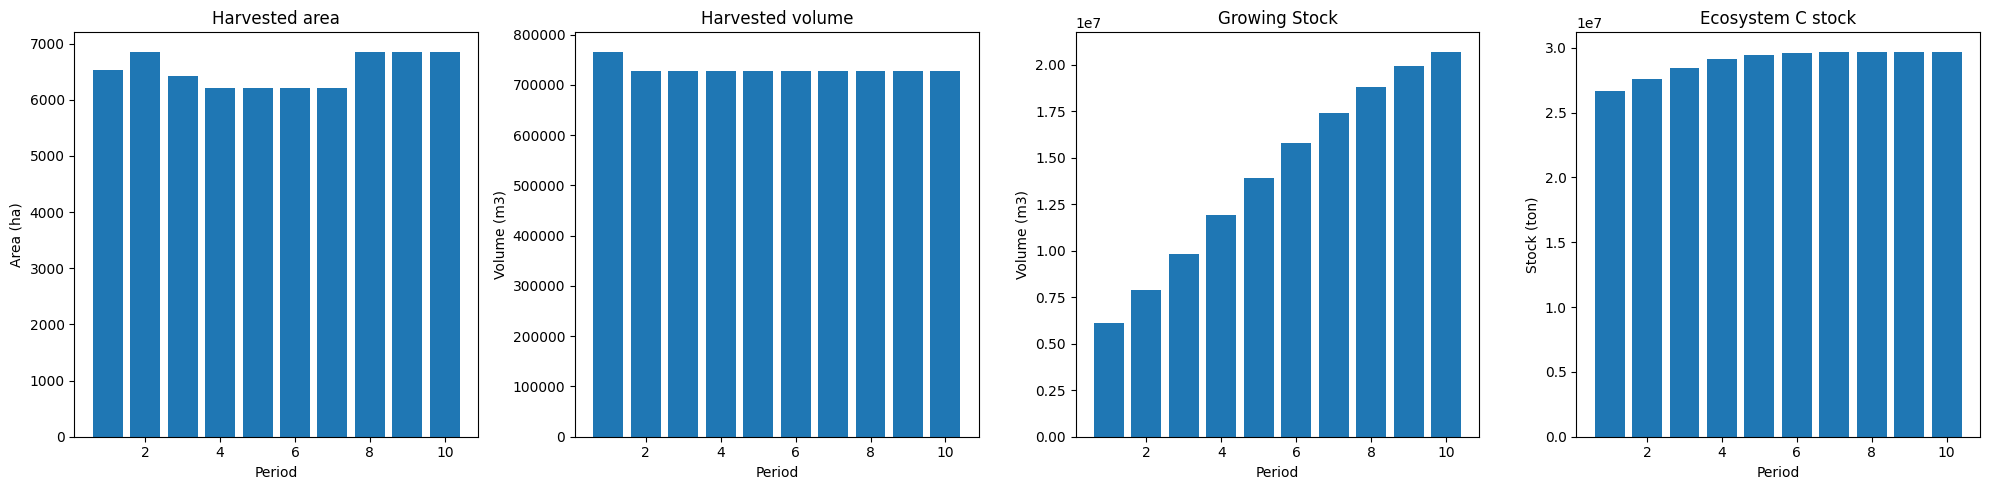

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


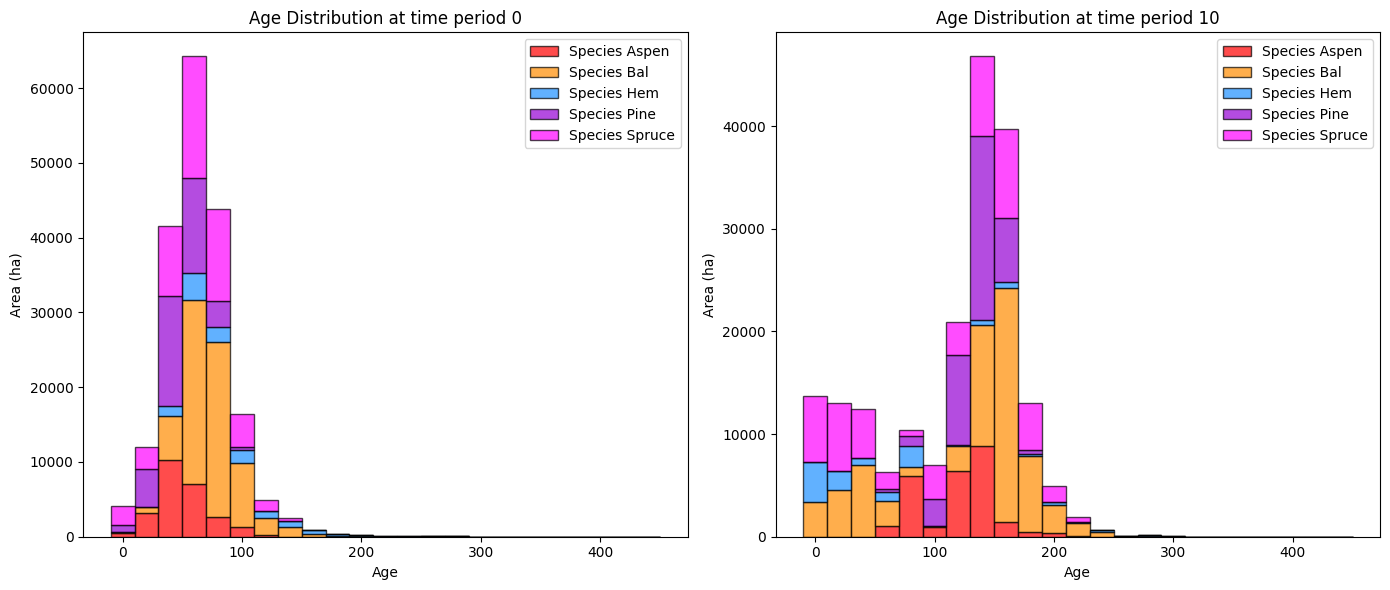

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


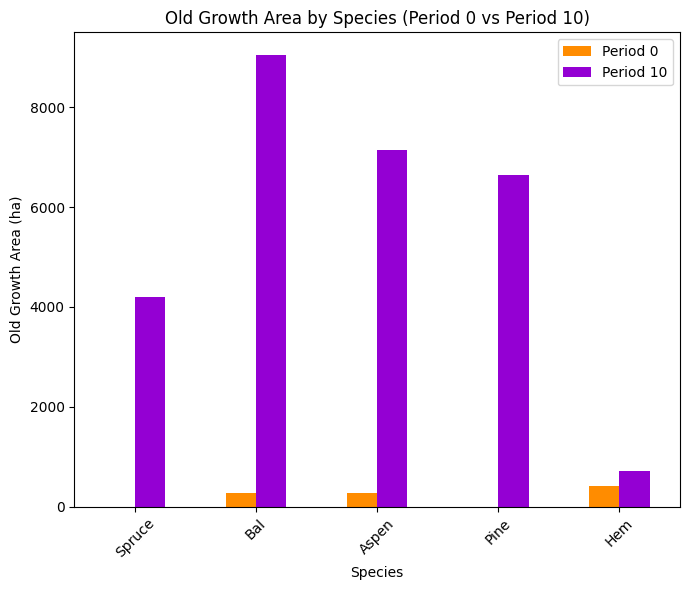

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


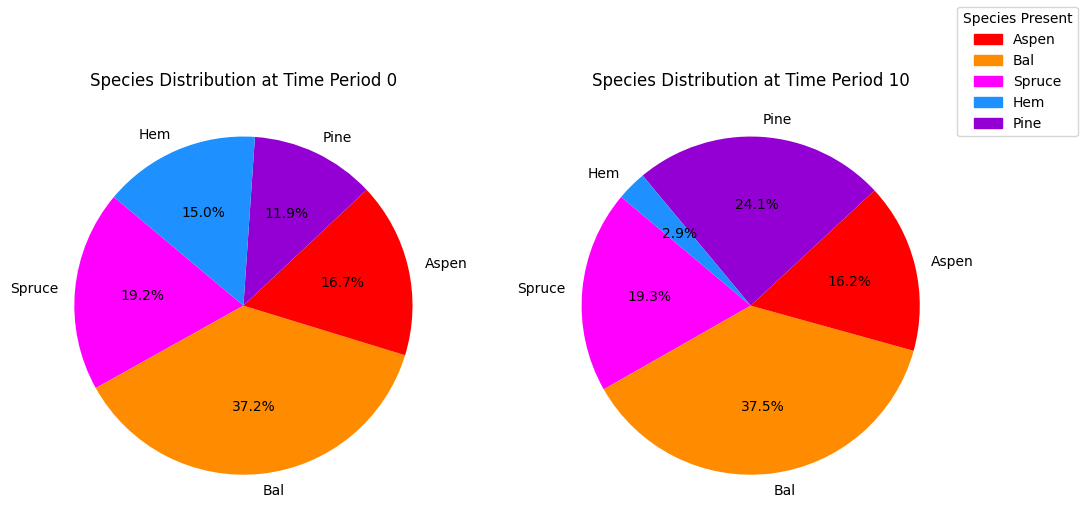

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


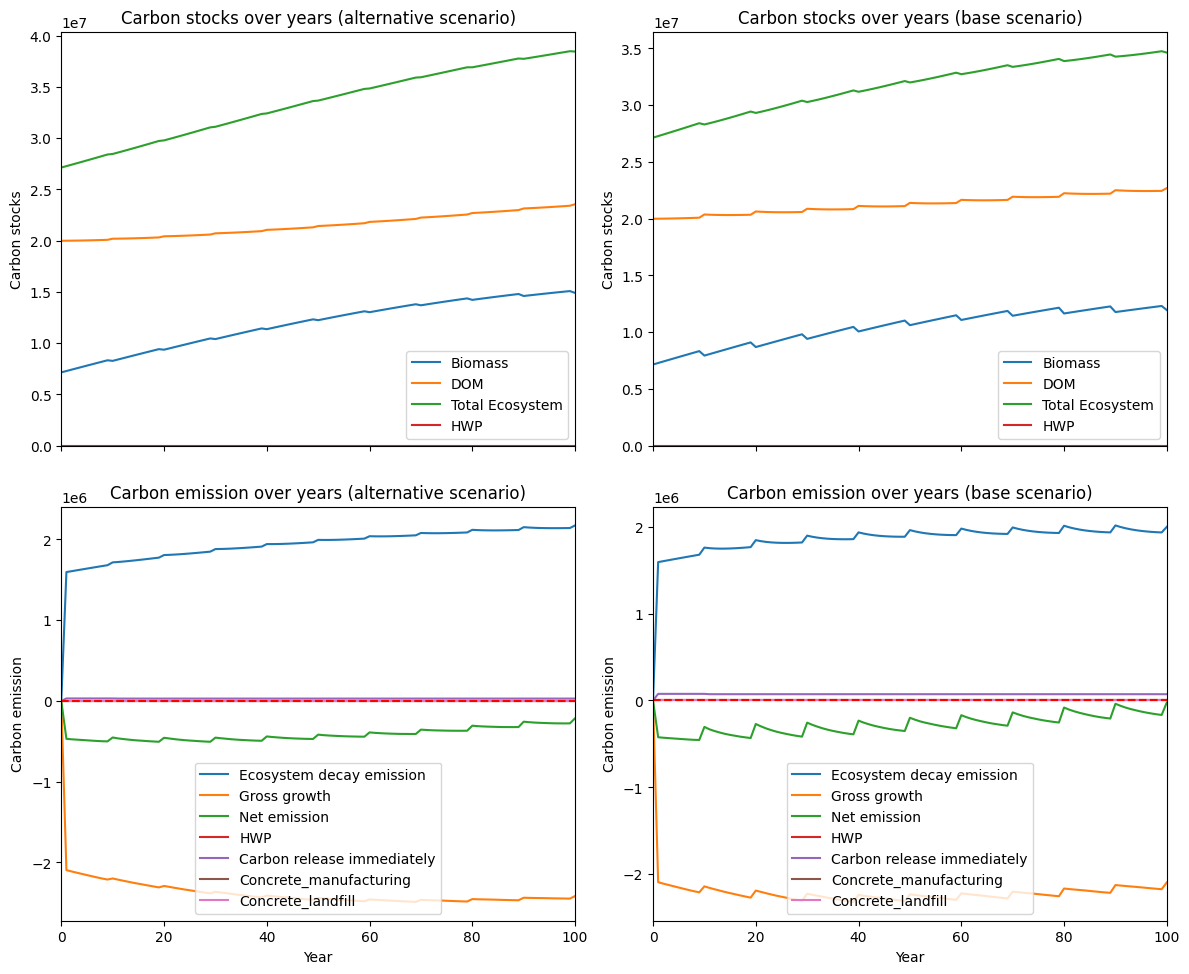

---------------------------------------------------------------------------------------
Net emission difference -2197096.432097922
Net emission base scenario -11595023.597955838
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  4.551461580797065
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  1793.902271  1793.902271
Bal     0.0  4318.236651  4318.236651
Aspen   0.0  4846.014899  4846.014899
Pine    0.0   950.128534   950.128534
Hem     0.0   334.010524   334.010524

Overall, the old growth area has **increased** by 12242.29 hectares in the alternative scenario compared to the base scenario.


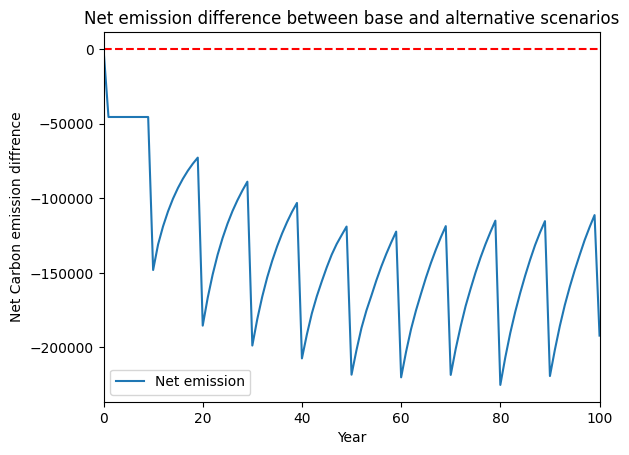

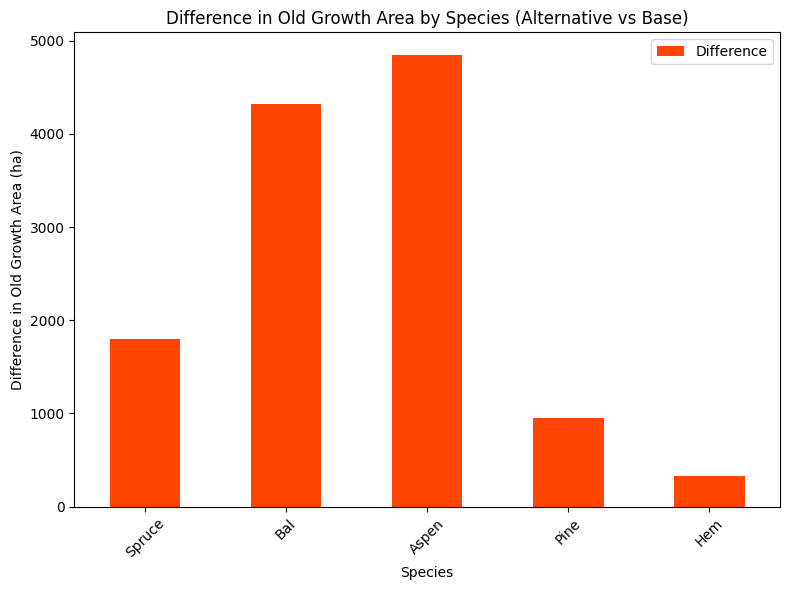

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


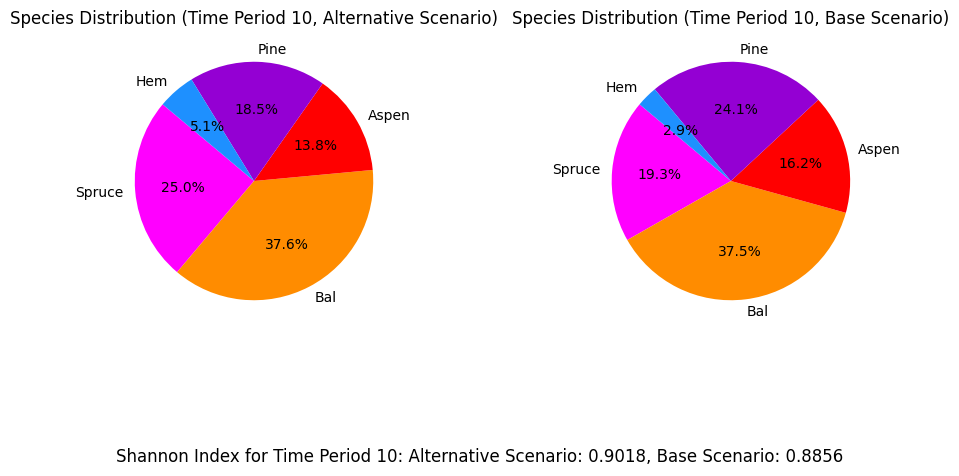

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_30%...
running the scenario for the Golden Bear mining site (30%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x1735748c
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34100 

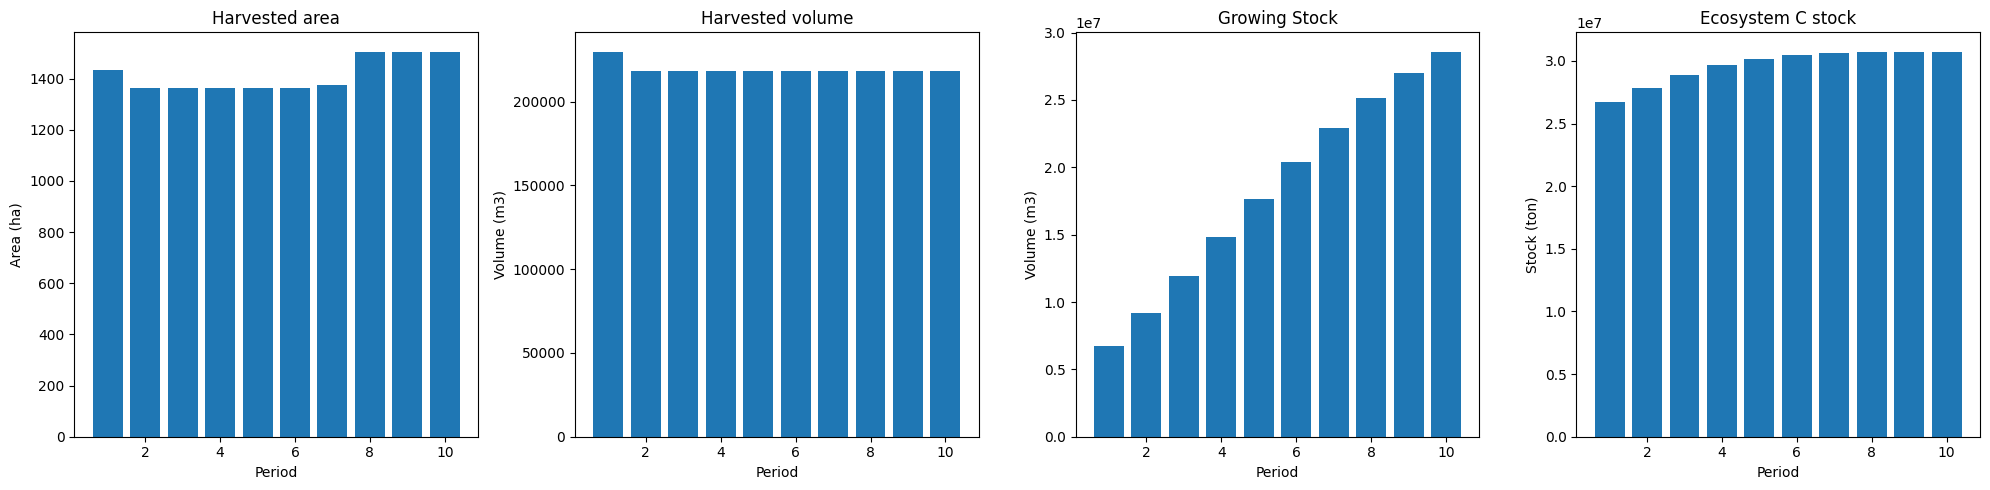

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_30%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  2320
The economic indicator (the provincial government revenues) is:  79128
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


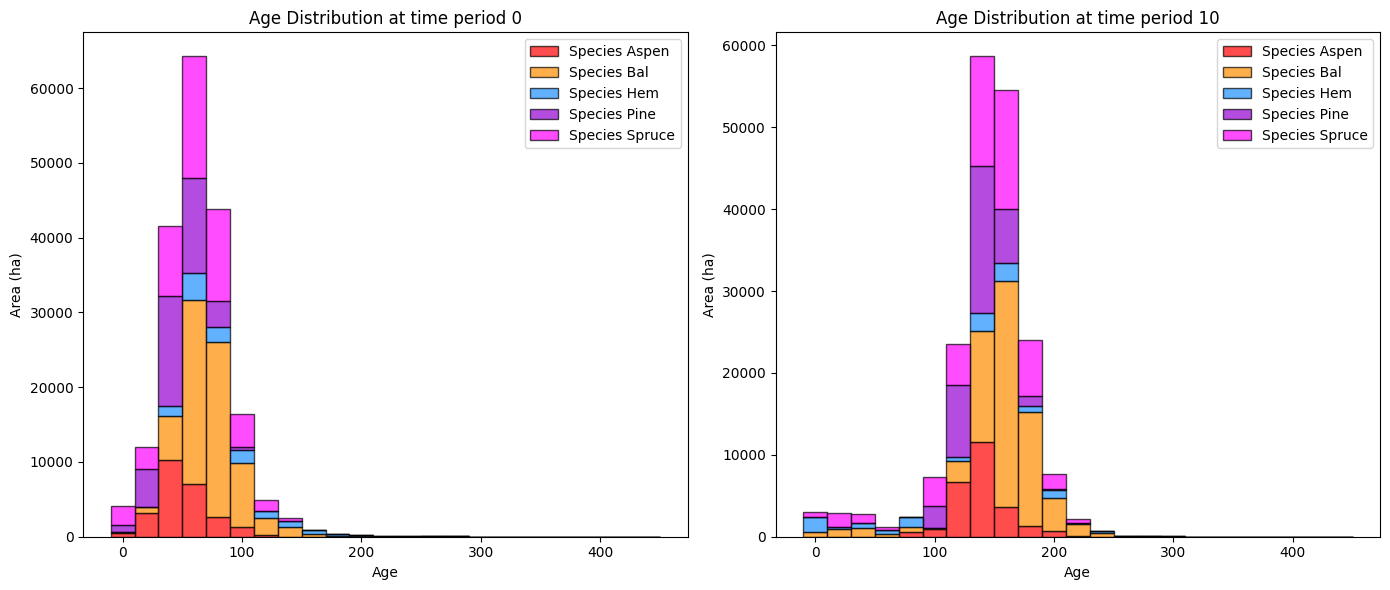

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_30%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6370.018870   6367.310336
Bal     278.565372  13852.173757  13573.608386
Aspen   273.490478  12624.475178  12350.984700
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   1290.243476    870.544145

Overall diversity has **increased** by 40794.33 hectares from time period 0 to time period 10.


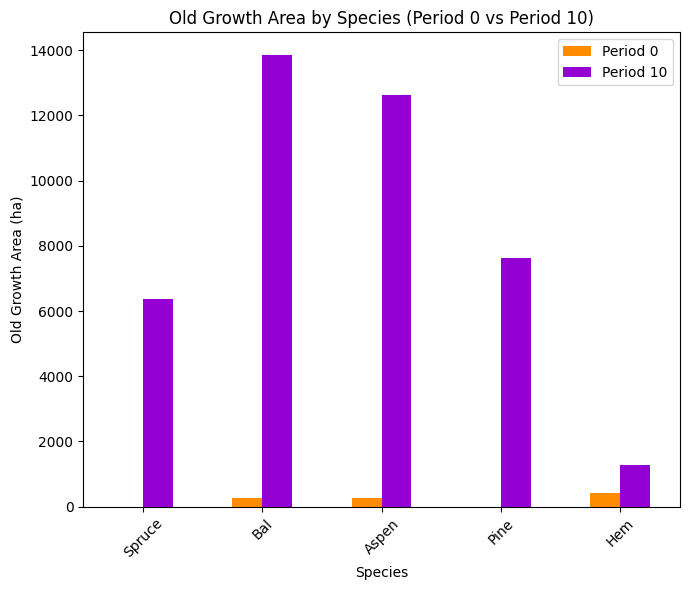

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_30%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9125

Diversity has **decreased** by 3.30% from time 0 to time 10.


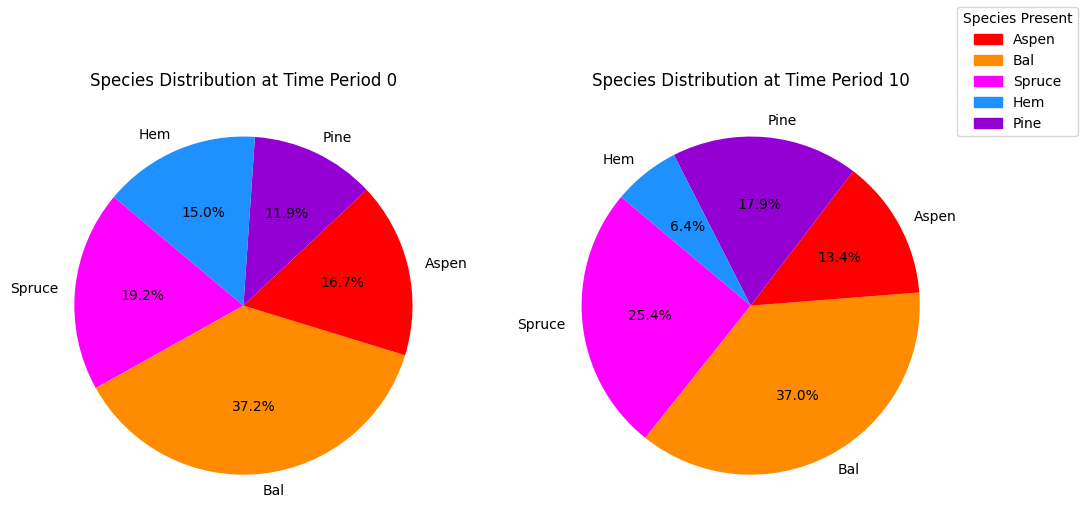

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_30%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.14s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

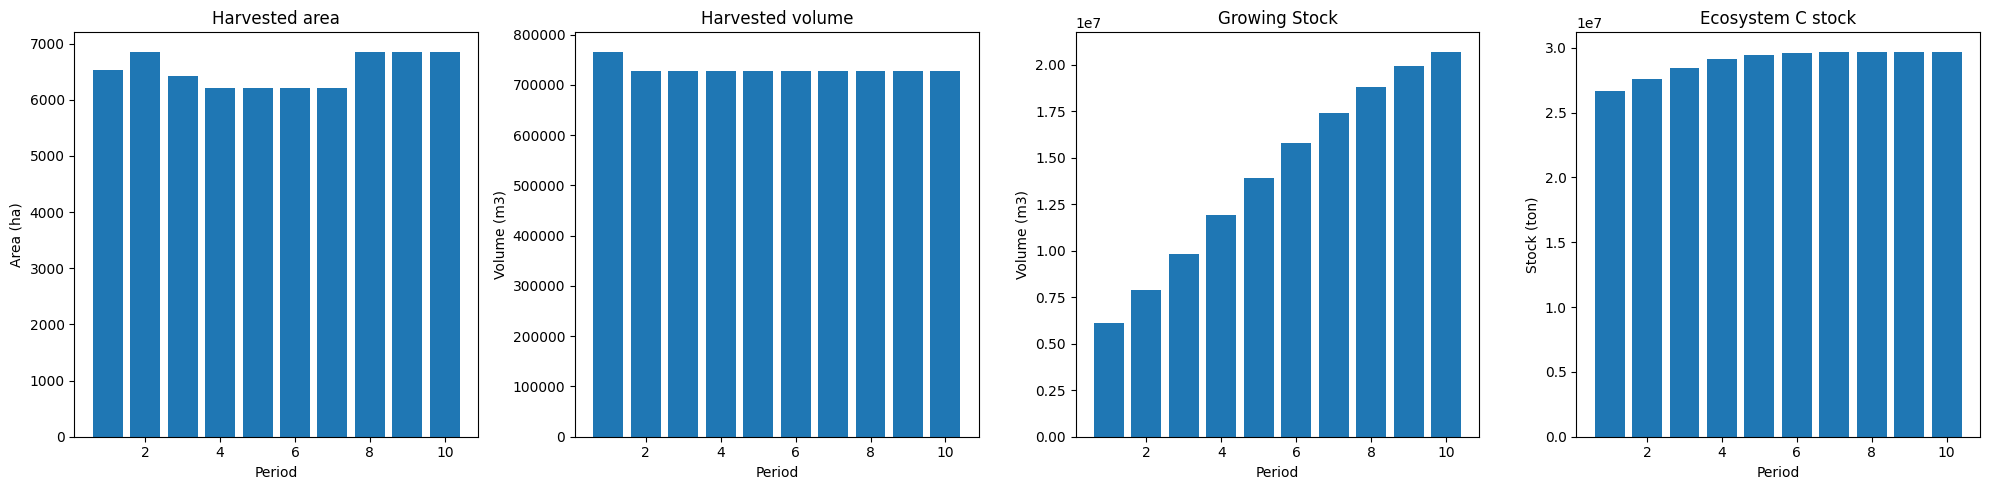

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


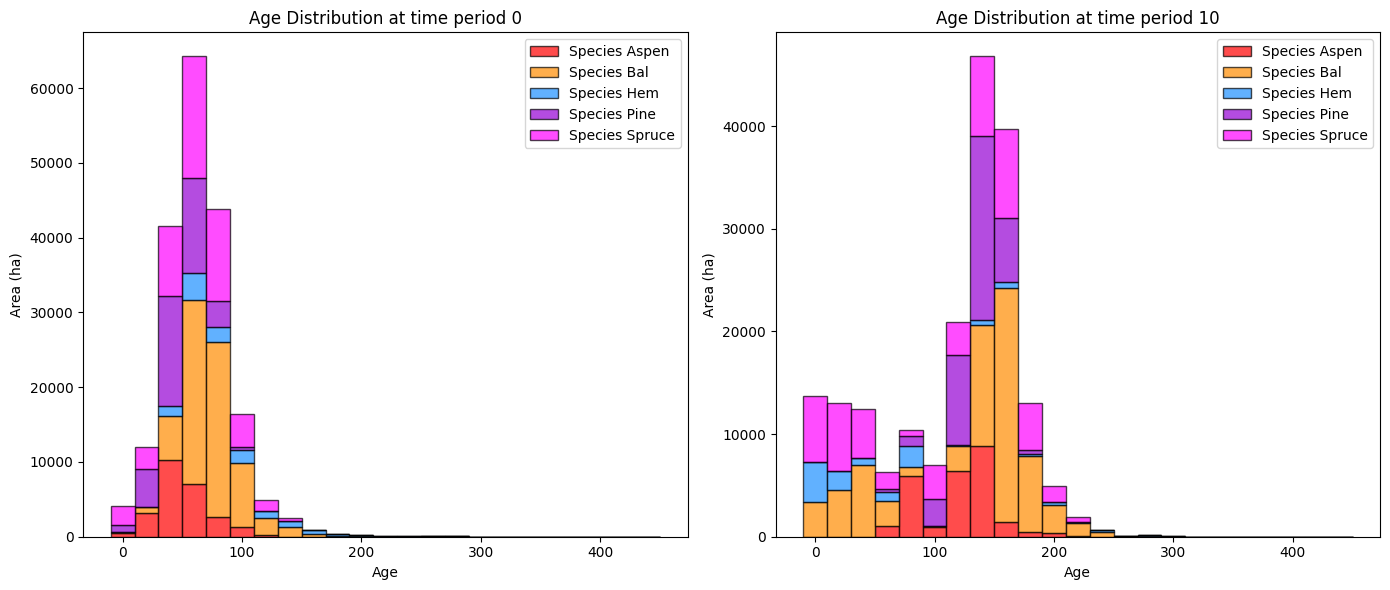

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


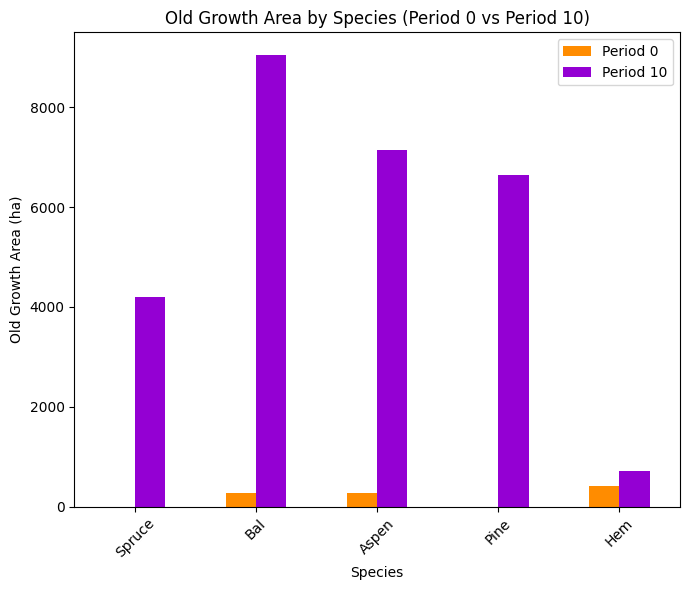

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


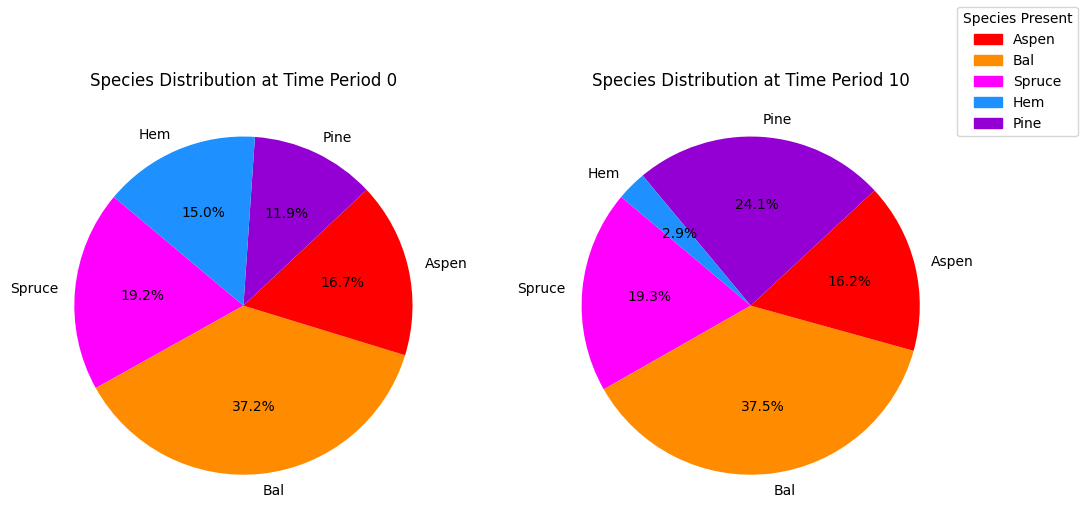

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


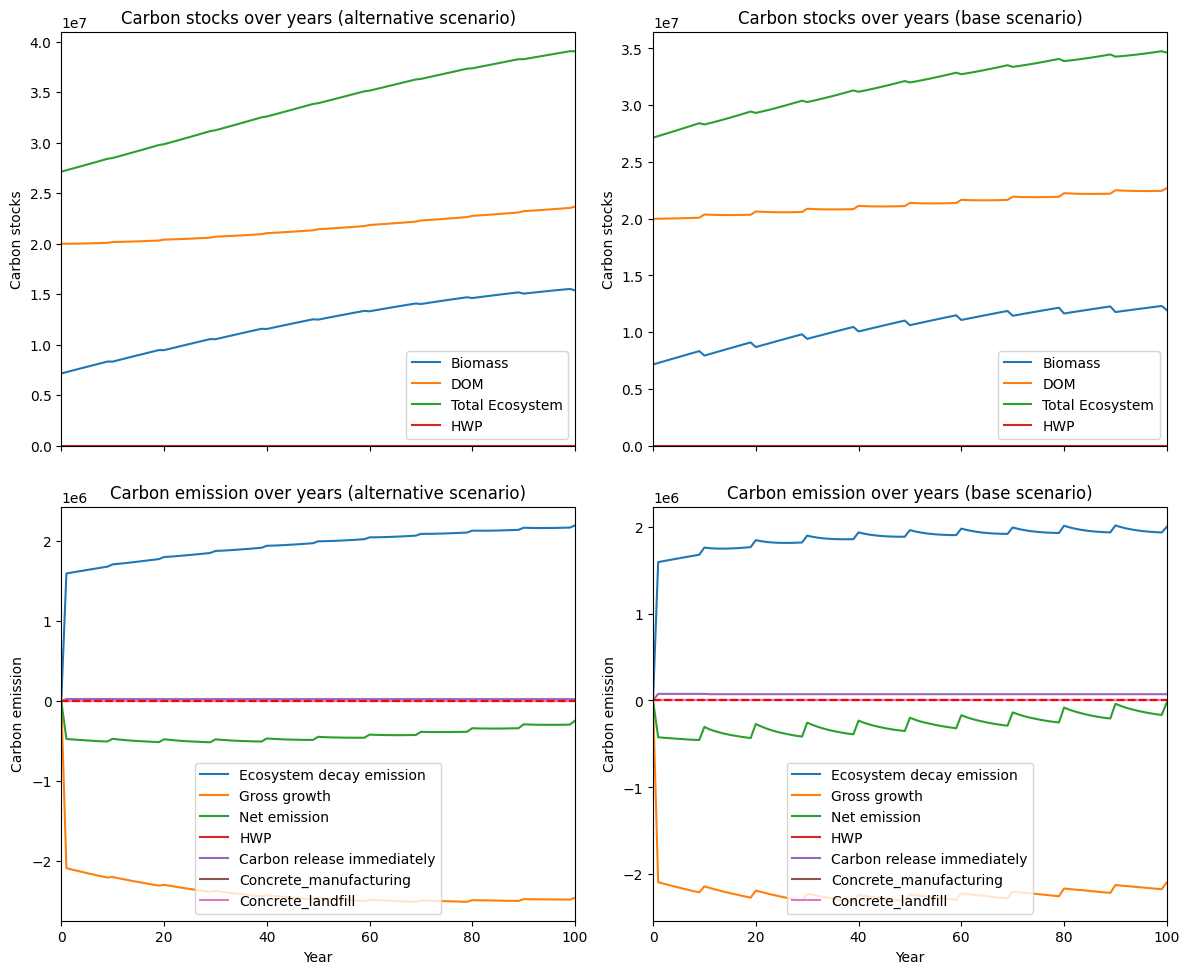

---------------------------------------------------------------------------------------
Net emission difference -2520348.6021154085
Net emission base scenario -11918275.767973324
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  3.9677050990512512
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2176.935049  2176.935049
Bal     0.0  4806.225787  4806.225787
Aspen   0.0  5473.364916  5473.364916
Pine    0.0   981.431263   981.431263
Hem     0.0   579.340063   579.340063

Overall, the old growth area has **increased** by 14017.30 hectares in the alternative scenario compared to the base scenario.


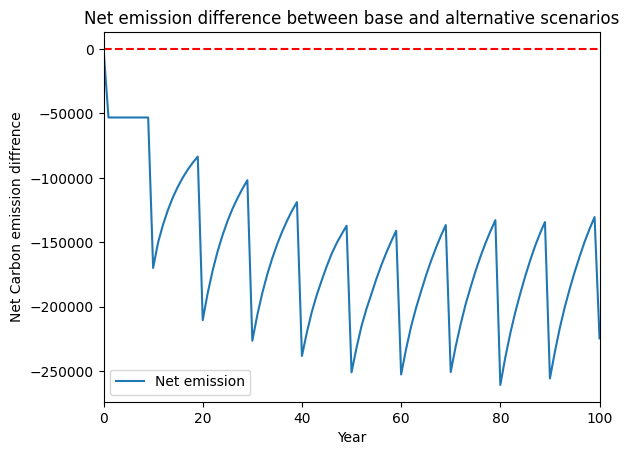

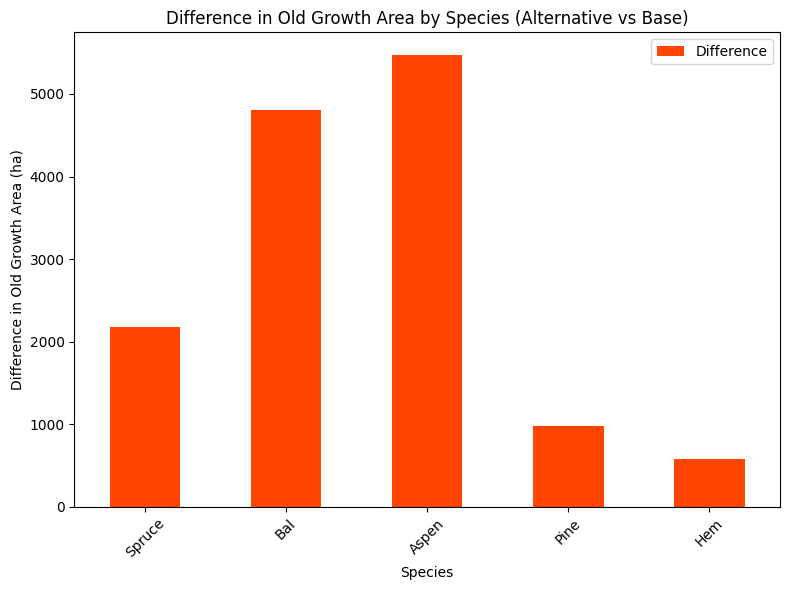

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


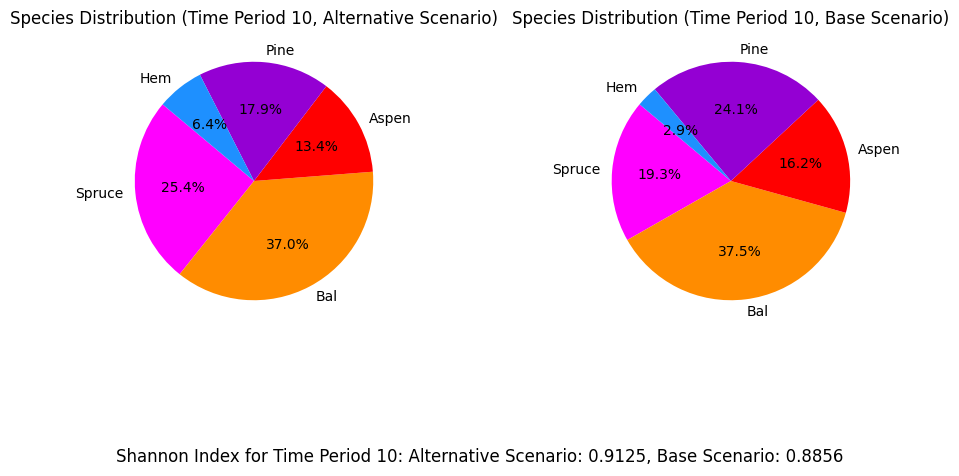

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_20%...
running the scenario for the Golden Bear mining site (20%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0xcf6ddff2
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34100 

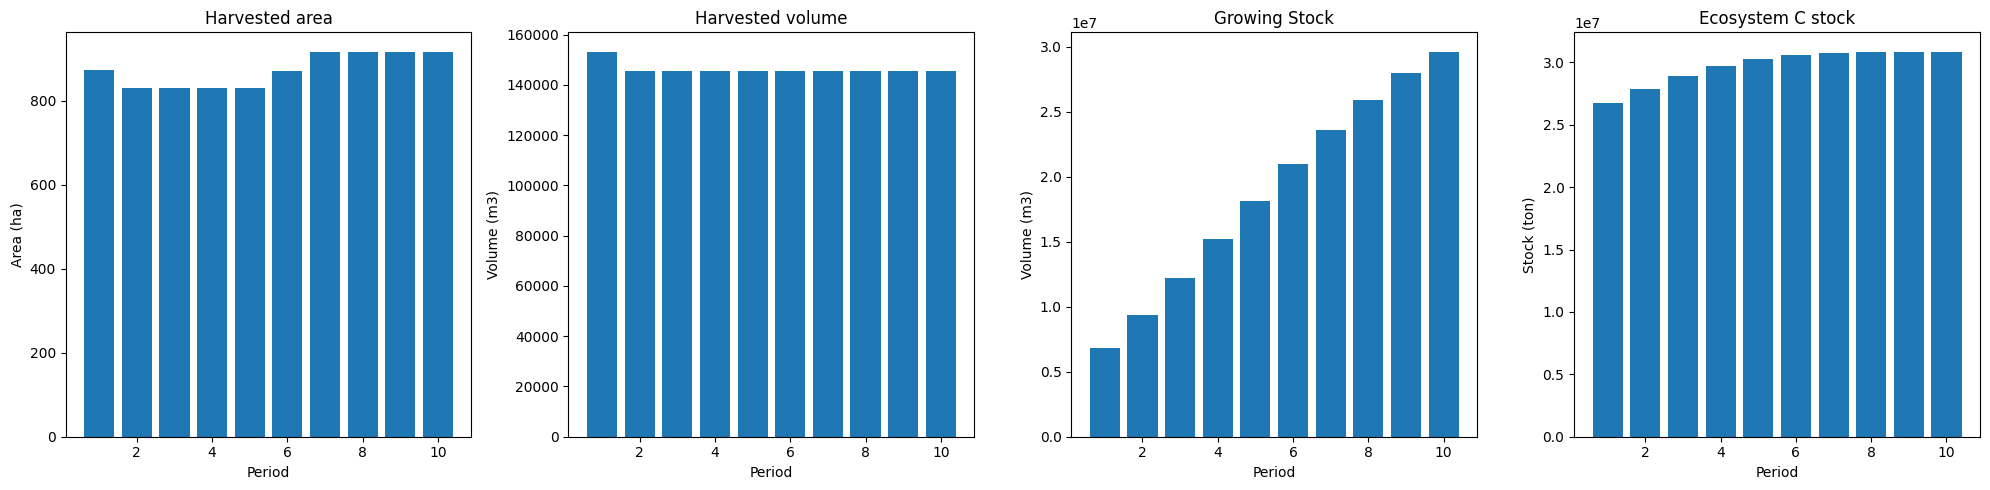

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_20%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  1546
The economic indicator (the provincial government revenues) is:  52752
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


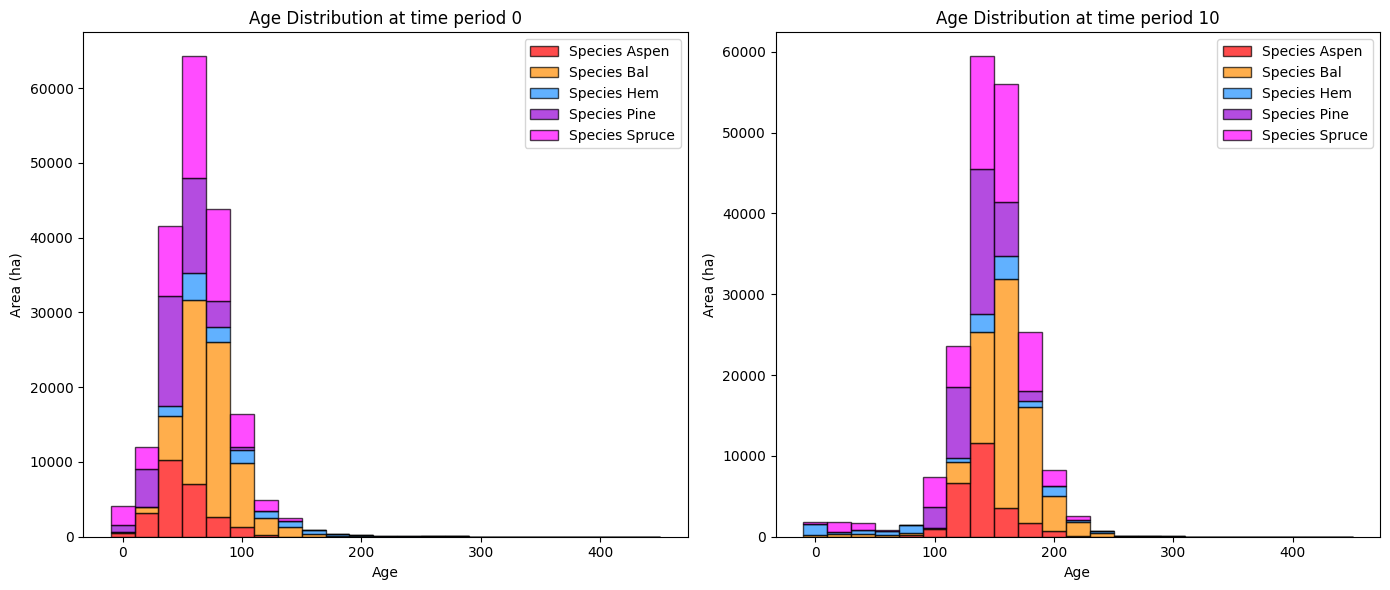

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_20%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   6772.376699   6769.668165
Bal     278.565372  14764.627374  14486.062002
Aspen   273.490478  13036.473199  12762.982721
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   1575.686854   1155.987523

Overall diversity has **increased** by 42806.59 hectares from time period 0 to time period 10.


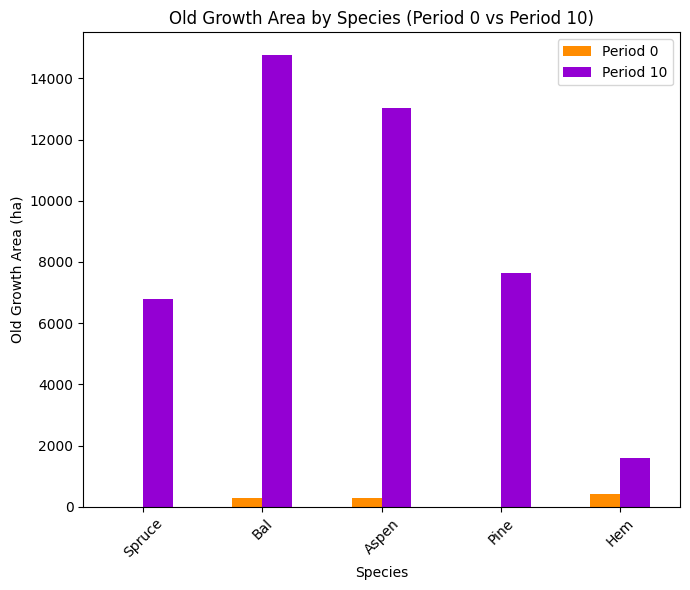

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_20%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9142

Diversity has **decreased** by 3.13% from time 0 to time 10.


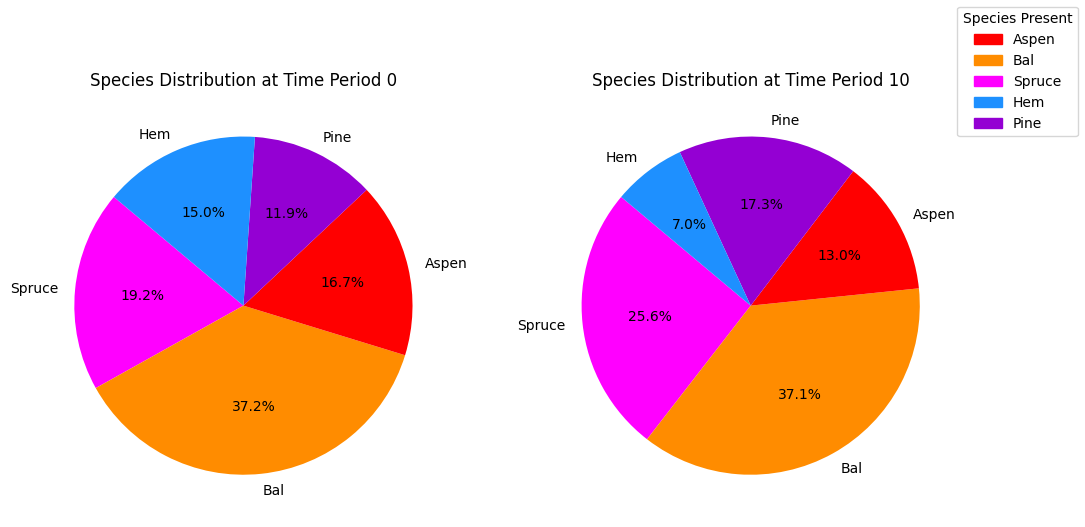

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_20%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.13s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

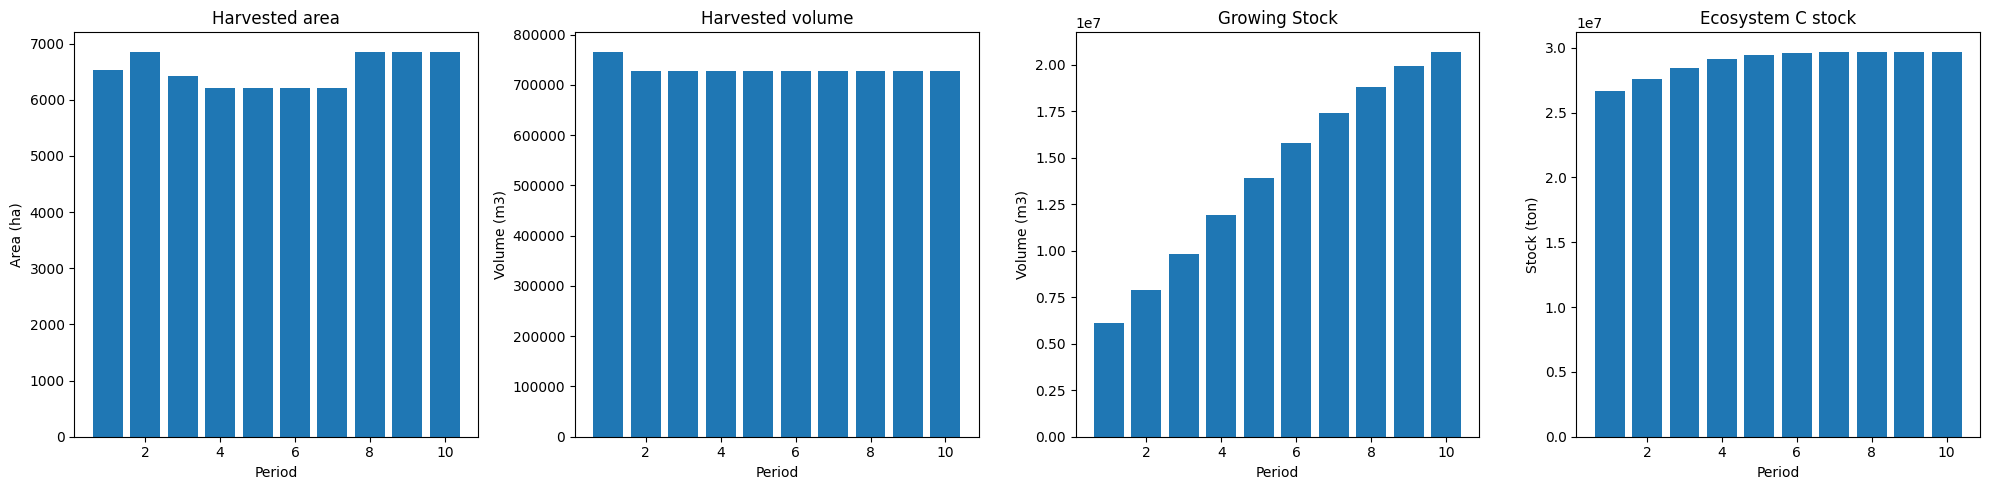

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


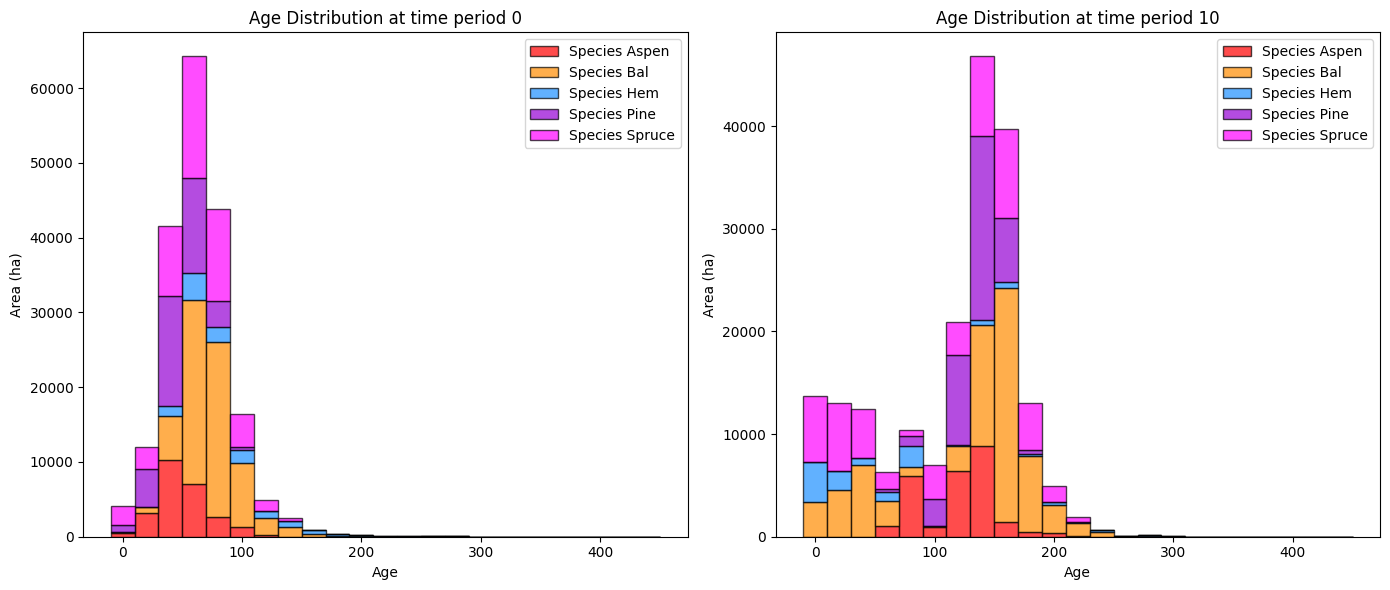

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


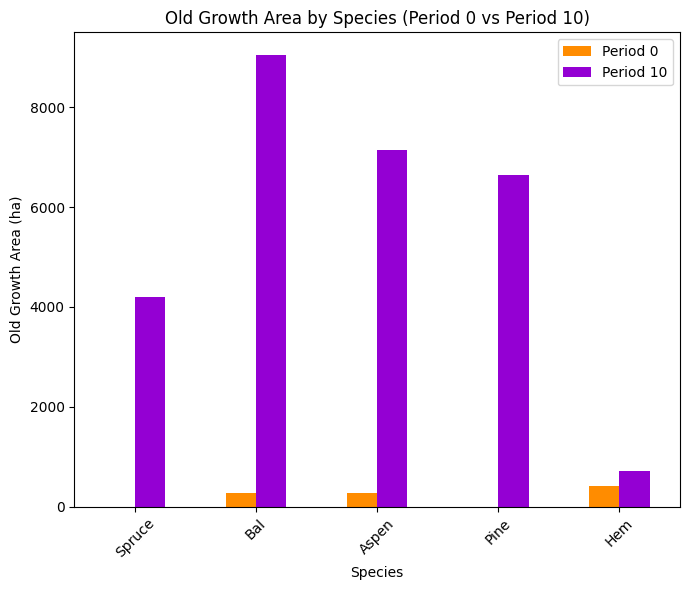

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


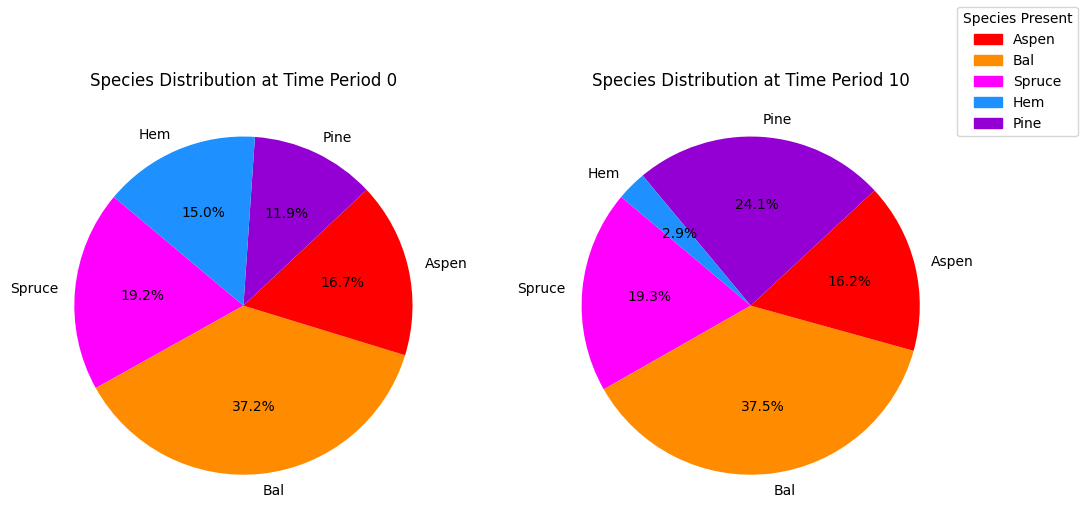

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


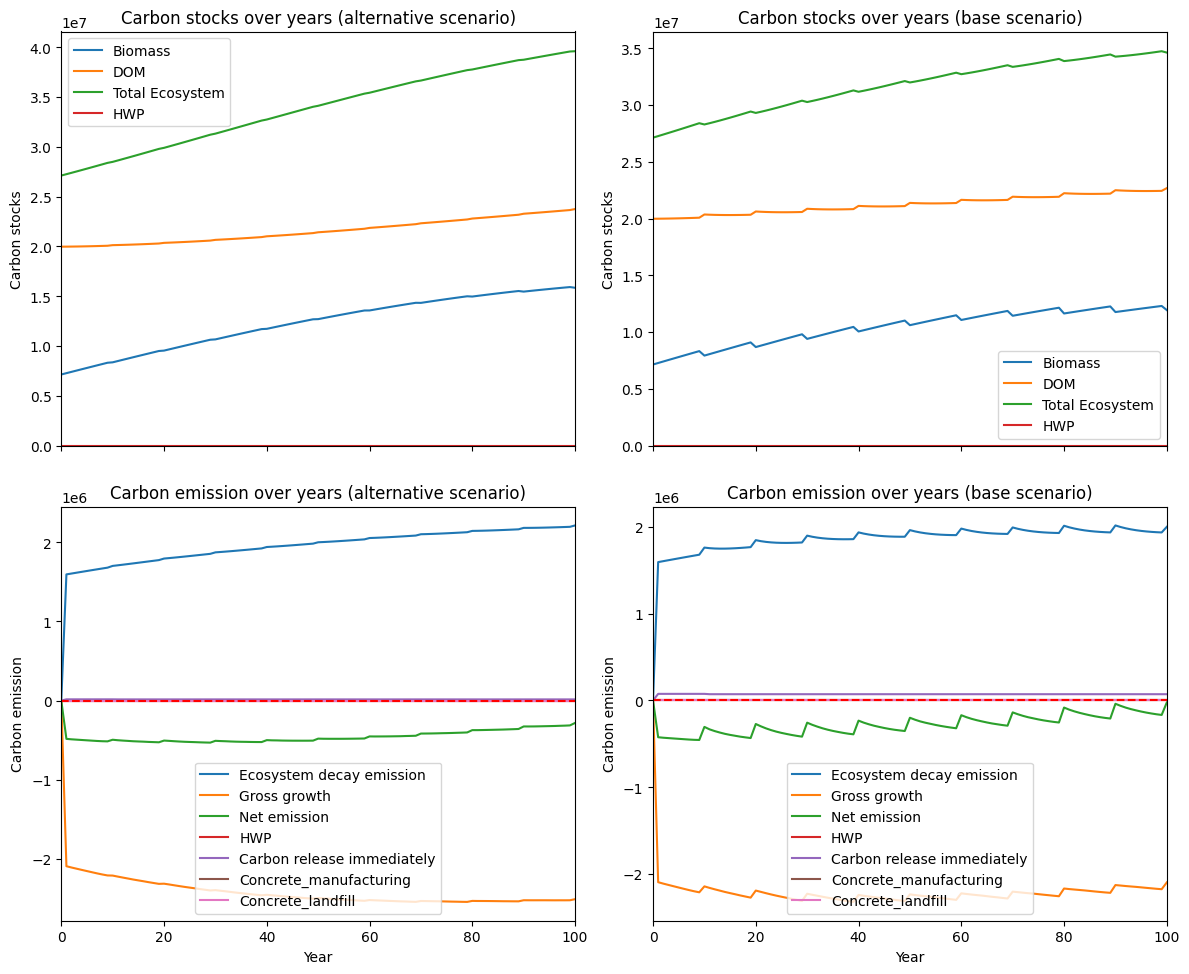

---------------------------------------------------------------------------------------
Net emission difference -2843897.631288305
Net emission base scenario -12241824.797146222
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  3.516300970182929
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  2579.292878  2579.292878
Bal     0.0  5718.679403  5718.679403
Aspen   0.0  5885.362938  5885.362938
Pine    0.0   981.431263   981.431263
Hem     0.0   864.783441   864.783441

Overall, the old growth area has **increased** by 16029.55 hectares in the alternative scenario compared to the base scenario.


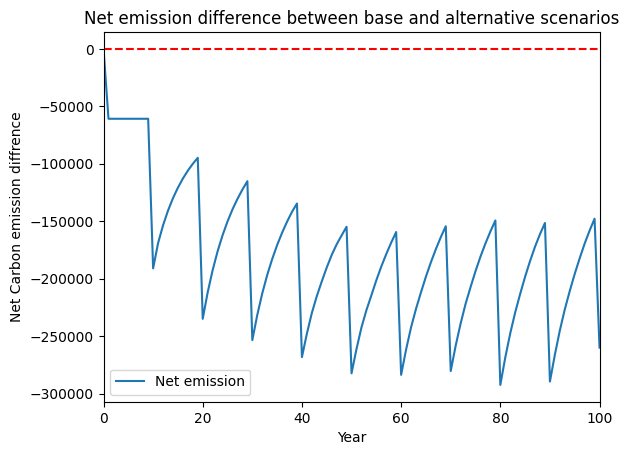

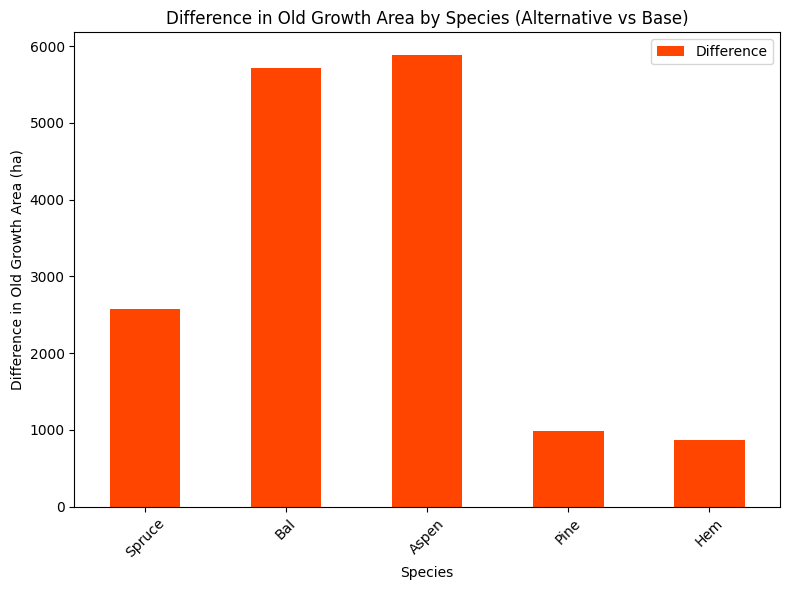

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


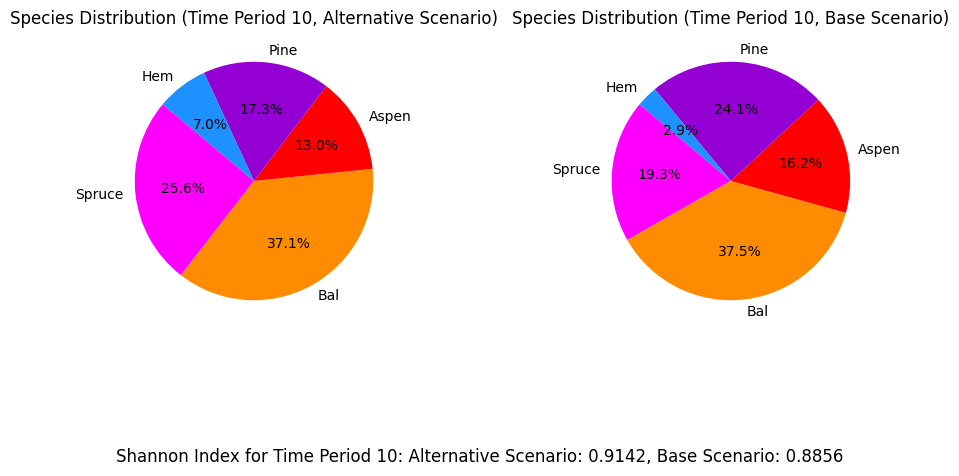

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
Running for goldenbear_max_st_gldbr_AAC_10%...
running the scenario for the Golden Bear mining site (10%_AAC),
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x5232d696
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+09]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.16s
Presolved: 1911 rows, 34100 

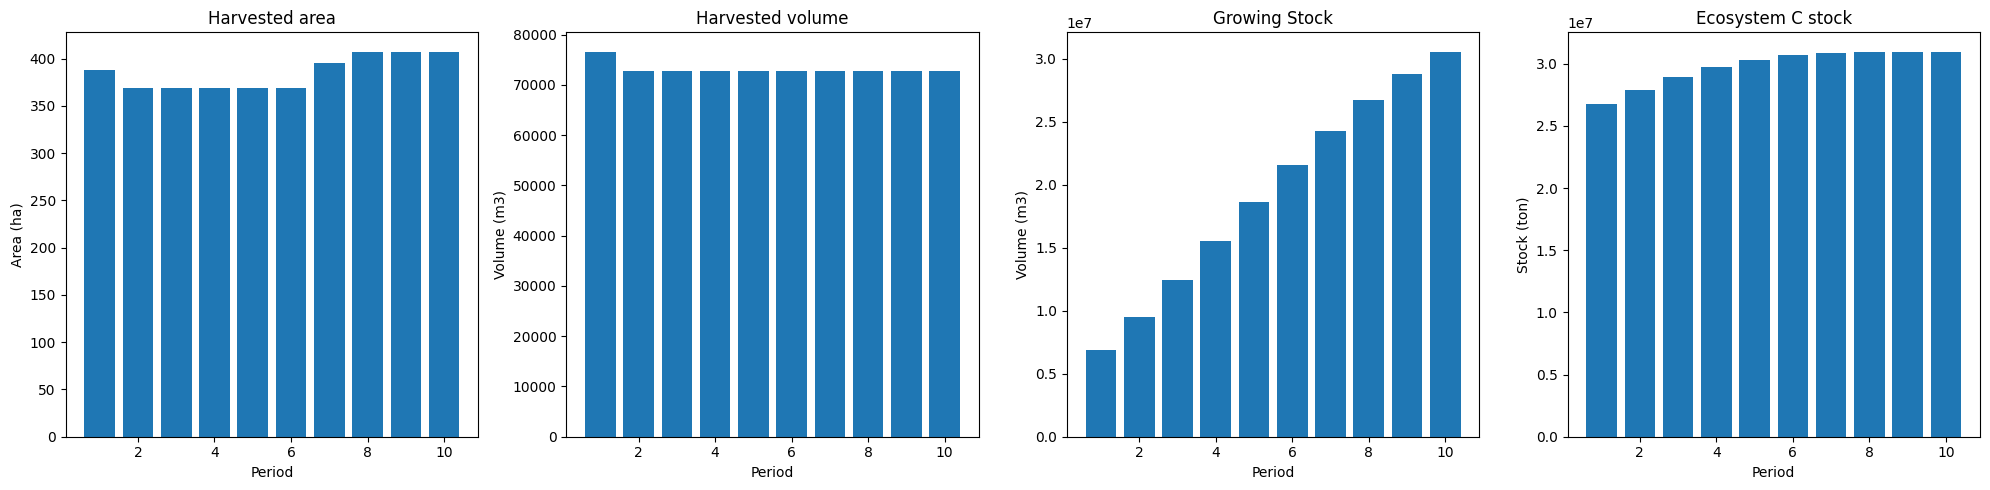

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_10%_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  773
The economic indicator (the provincial government revenues) is:  26376
------------------------------------------------
Saved cbm_output_1 and cbm_output_2 as pickle files.


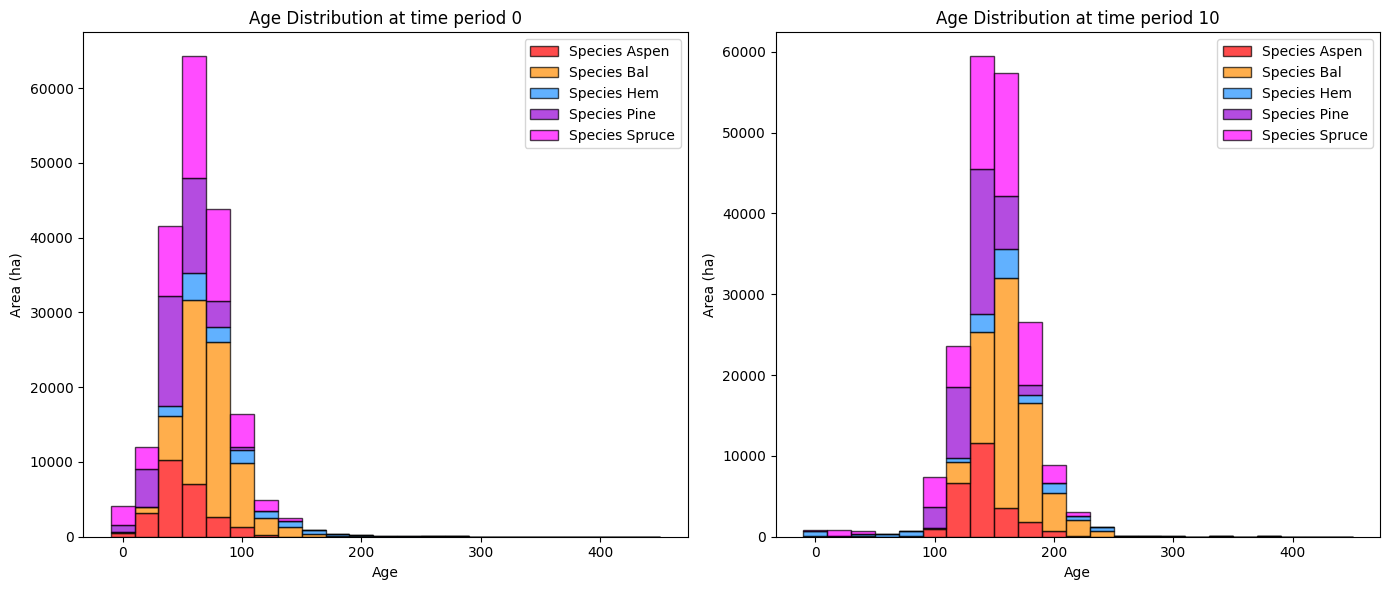

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_10%_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0            10    Difference
Spruce    2.708533   7301.654839   7298.946306
Bal     278.565372  15768.376924  15489.811553
Aspen   273.490478  13191.618272  12918.127794
Pine      0.000000   7631.887200   7631.887200
Hem     419.699331   2296.827640   1877.128310

Overall diversity has **increased** by 45215.90 hectares from time period 0 to time period 10.


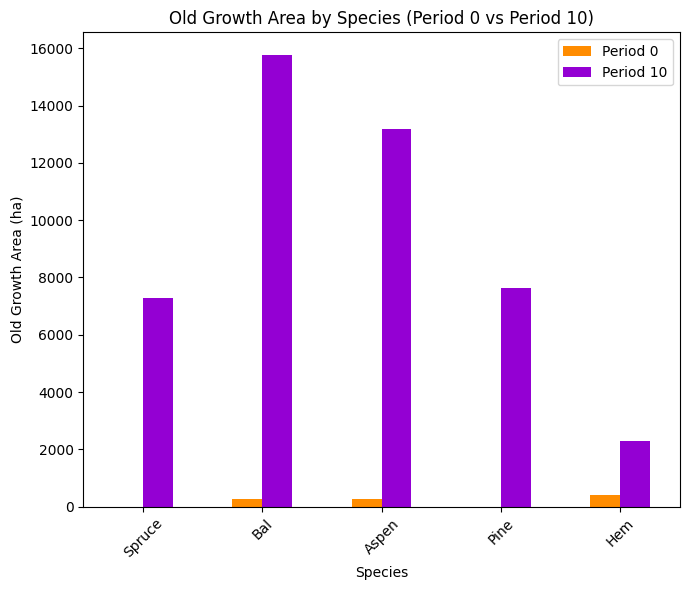

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_10%_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.9203

Diversity has **decreased** by 2.52% from time 0 to time 10.


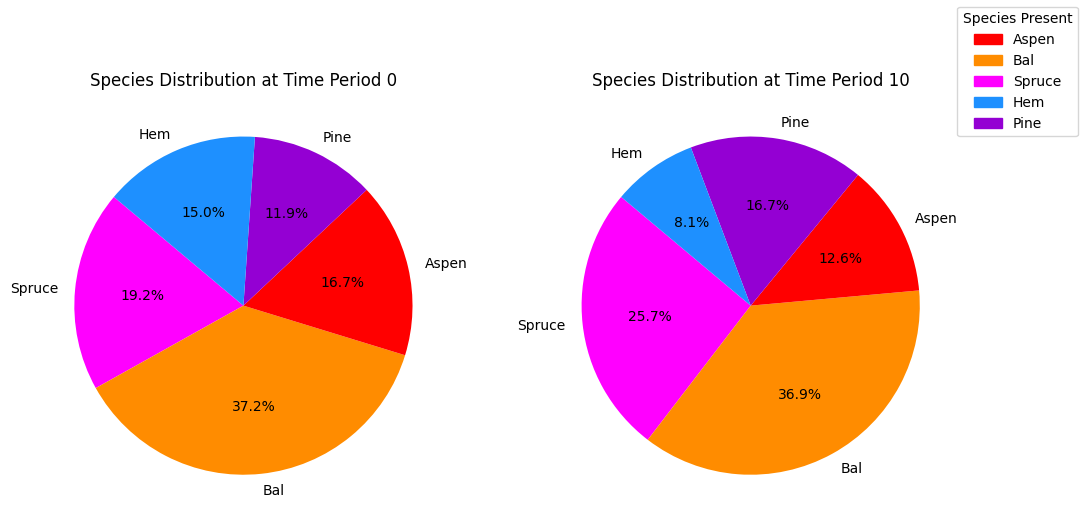

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_gldbr_AAC_10%_species_pie.pdf
running business as usual scenario for the Golden Bear mine site
Gurobi Optimizer version 10.0.3 build v10.0.3rc0 (linux64)

CPU model: Intel Core Processor (Broadwell, IBRS), instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 3949 rows, 36130 columns and 470612 nonzeros
Model fingerprint: 0x49b59960
Coefficient statistics:
  Matrix range     [1e-02, 1e+05]
  Objective range  [2e+02, 1e+06]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 2e+10]
         Consider reformulating model or setting NumericFocus parameter
         to avoid numerical issues.
Presolve removed 2038 rows and 2031 columns
Presolve time: 0.15s
Presolved: 1911 rows, 34099 columns, 409165 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time

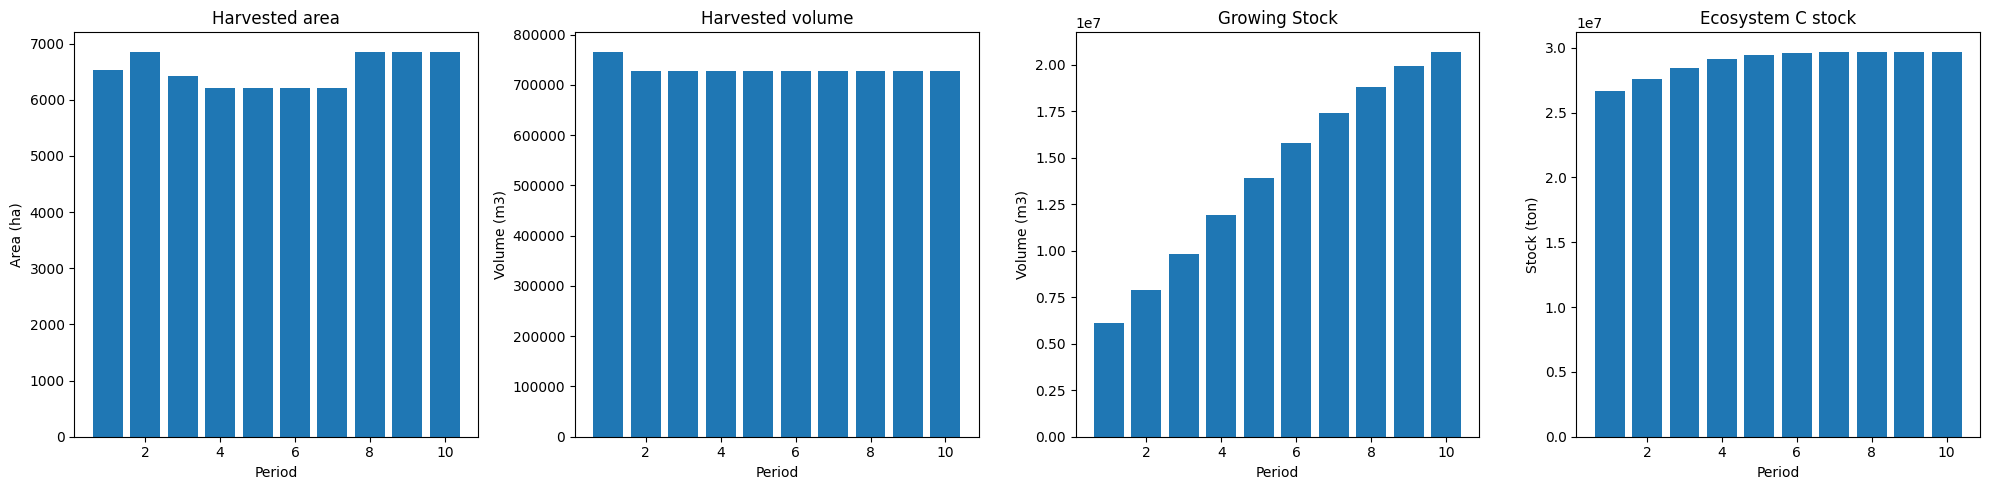

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_scheduling_maxstock.pdf
------------------------------------------------
The scocial indicator (the number of job creation) is:  7734
The economic indicator (the provincial government revenues) is:  263762
------------------------------------------------
Saved cbm_output_3 and cbm_output_4 as pickle files.


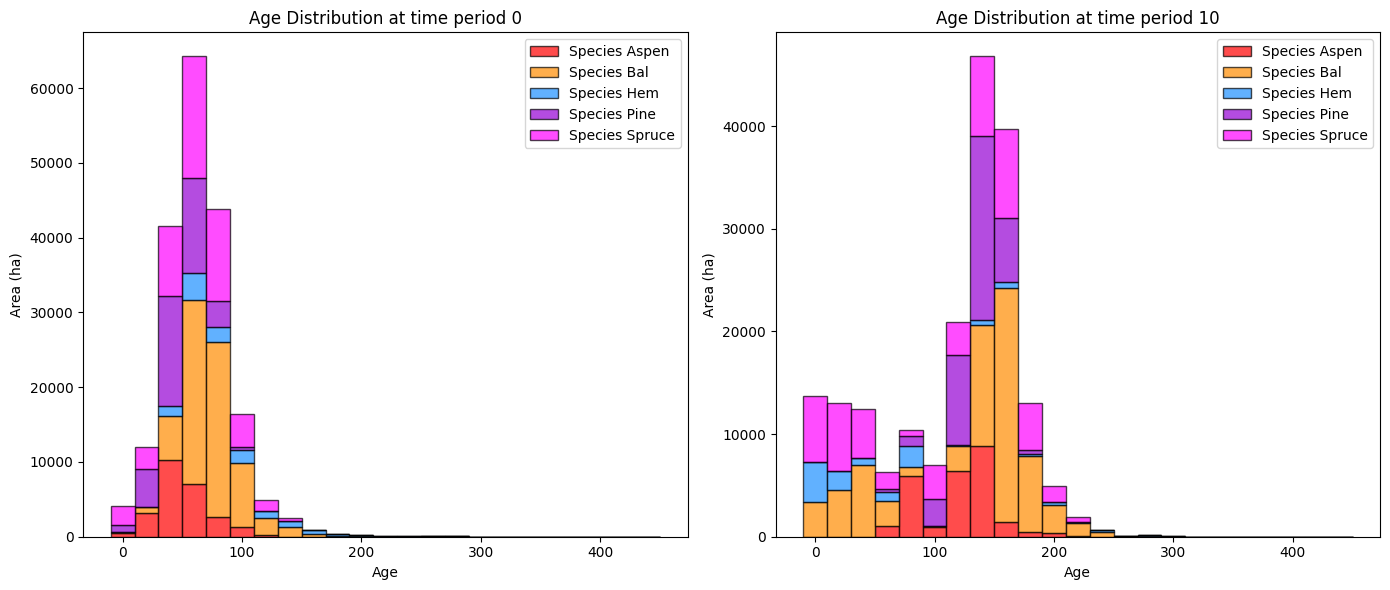

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_age_distribution.pdf

Old Growth Data (in hectares). 
Negative value indicates loss of old growth and positive value indicates gain of old growth.
                 0           10   Difference
Spruce    2.708533  4193.083821  4190.375287
Bal     278.565372  9045.947970  8767.382599
Aspen   273.490478  7151.110261  6877.619783
Pine      0.000000  6650.455938  6650.455938
Hem     419.699331   710.903413   291.204082

Overall diversity has **increased** by 26777.04 hectares from time period 0 to time period 10.


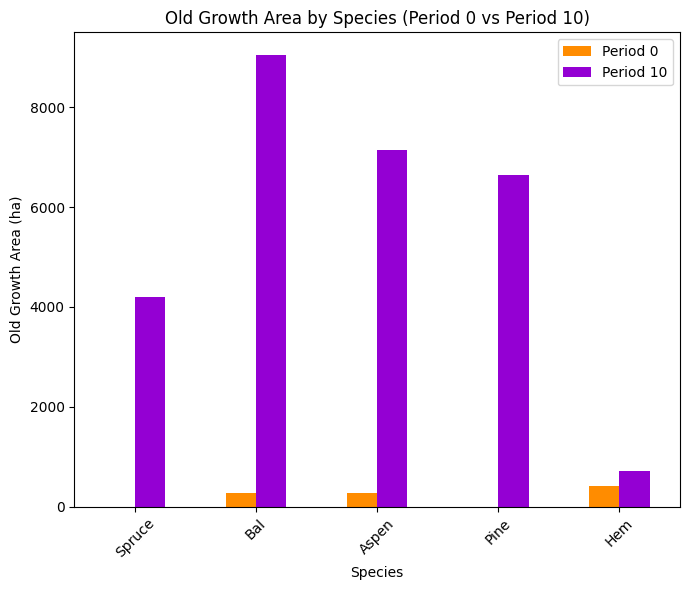

Clustered column plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_old_growth_comparison.pdf

Shannon Evenness Index for time period 0: 0.9455
Shannon Evenness Index for time period 10: 0.8856

Diversity has **decreased** by 5.99% from time 0 to time 10.


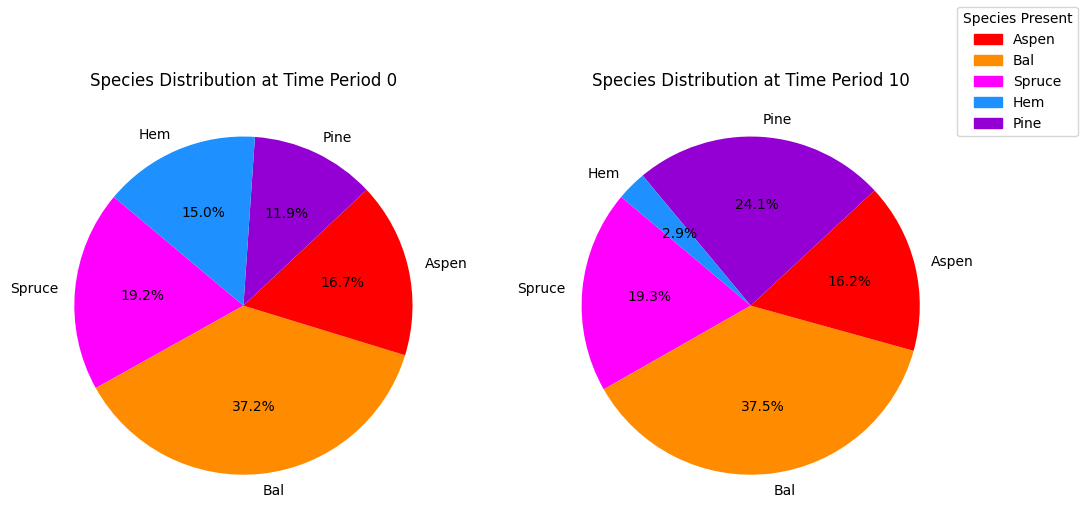

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_bau_gldbr_species_pie.pdf


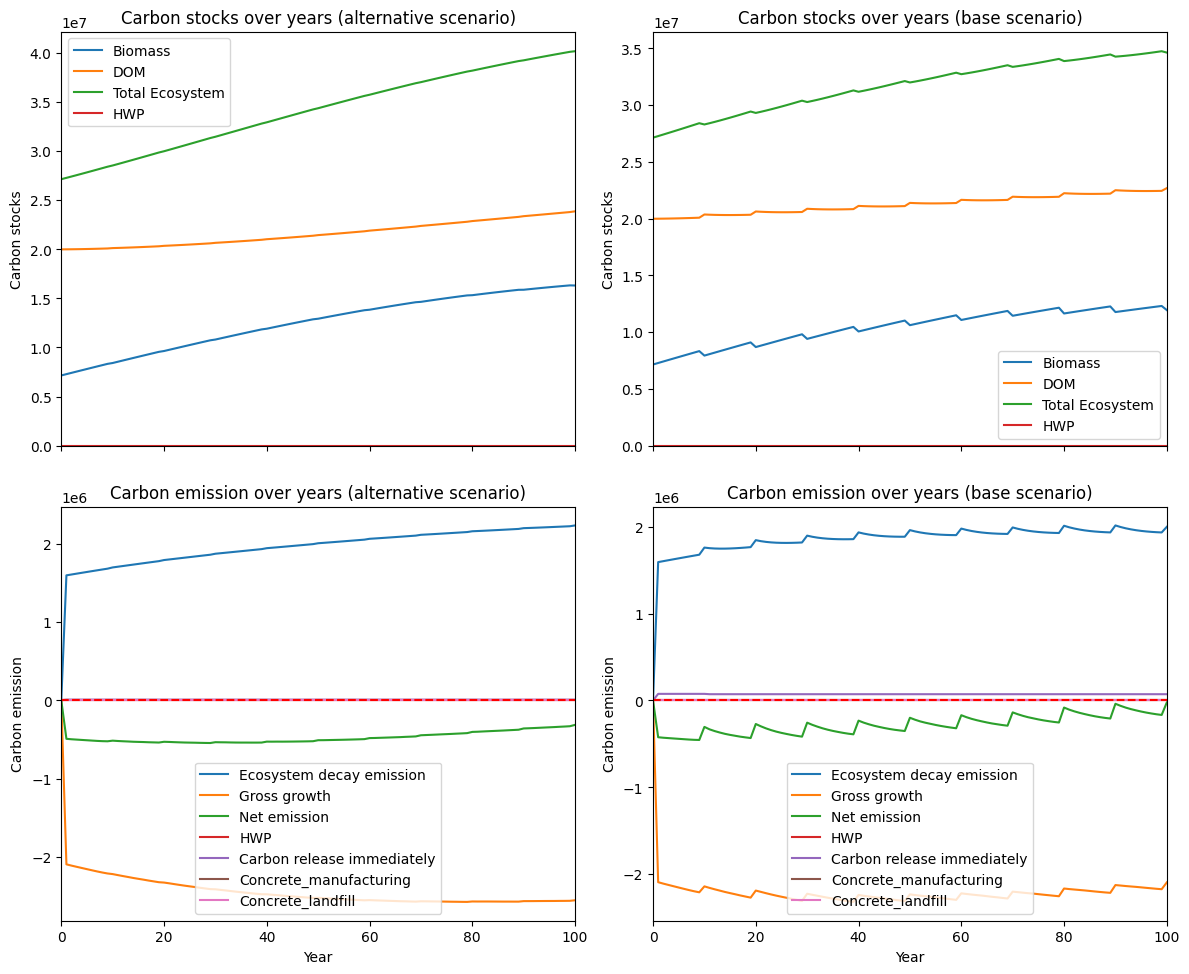

---------------------------------------------------------------------------------------
Net emission difference -3166490.5453015626
Net emission base scenario -12564417.711159479
Net emission alternative scenario -9397927.165857917
dollar_per_ton is:  3.1580703801051913
Comparison of Old Growth Areas (Alternative - Base)
          0           10   Difference
Spruce  0.0  3108.571018  3108.571018
Bal     0.0  6722.428954  6722.428954
Aspen   0.0  6040.508011  6040.508011
Pine    0.0   981.431263   981.431263
Hem     0.0  1585.924227  1585.924227

Overall, the old growth area has **increased** by 18438.86 hectares in the alternative scenario compared to the base scenario.


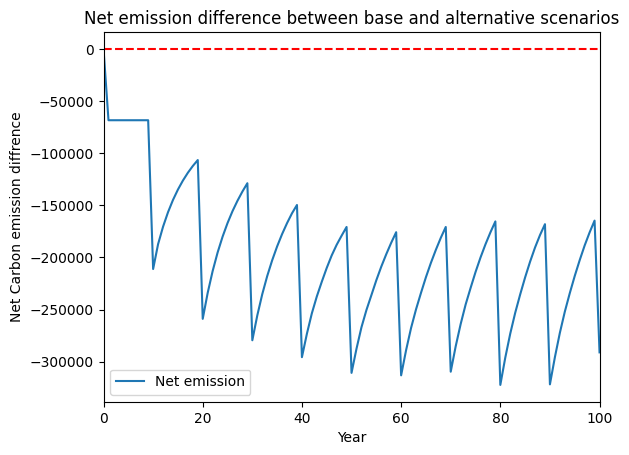

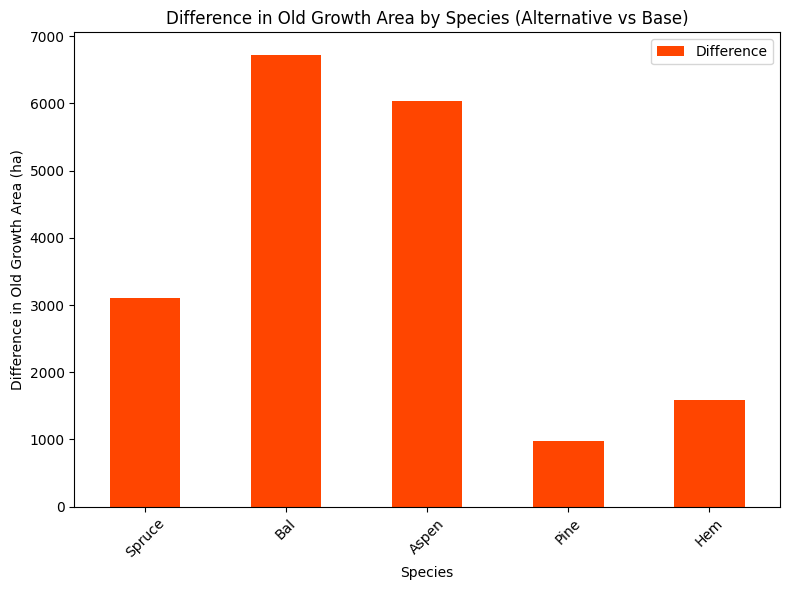

<Figure size 640x480 with 0 Axes>

Plot saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_age_difference.pdf


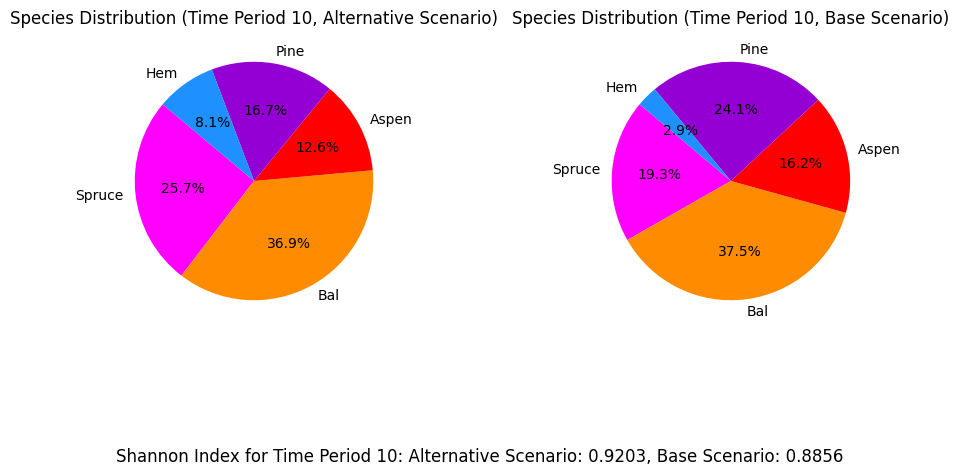

Pie Charts for Time Periods 0 and 10 saved to ./outputs/fig/goldenbear/goldenbear_max_st_kpi_species_difference_pie.pdf
---------------------------------------------------------------------------------------
It took 107.1 minutes to run all scenarios.


In [12]:
Start = time.time()
scenario_names = scenario_options.get(case_study, [])
for scenario_name in scenario_names:
    print(f"Running for {case_study}_{obj_mode}_{scenario_name}...")
    results_scenarios(fm, 
                      clt_percentage, 
                      credibility, 
                      budget_input, 
                      n_steps, 
                      max_harvest, 
                      scenario_name, 
                      displacement_effect, 
                      hwp_pool_effect_value, 
                      release_immediately_value, 
                      case_study, 
                      obj_mode,                   
                      pickle_output_base=False, 
                      pickle_output_alter=False)
print('It took', round((time.time() - Start) / 60, 1), "minutes to run all scenarios.")

In [13]:
print('It took', round((time.time() - Start) / 60, 1), "minutes to run this script.")

It took 107.1 minutes to run this script.
